<a href="https://colab.research.google.com/github/heavyrainseo/deeplearning/blob/main/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%EC%97%B0%EC%8A%B5_%EC%84%9C%EB%8C%80%EC%9A%B0%EA%B5%90%EC%88%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 차트에 한글 출력하기 위한 준비

### matplotlib, seaborn 차트 한글 사용
**방법 1. 쉬운 방법**  

쉬운 방법 - koreanize_matplotlib 사용  
아래 명령으로 필요 모듈을 설치한다.
> pip install setuptools
> pip install koreanize-matplotlib  

소스 파일 상단에 `import koreanize_matplotlib`를 추가한다.

**방법 2. 다양한 나눔 폰트 사용하기**  

>!sudo apt-get install -y fonts-nanum  
>!sudo fc-cache -fv  
>!rm ~/.cache/matplotlib -rf

코드 내에서 아래 코드를 포함시킨다.  
`import matplotlib.pyplot as plt`    
`plt.rc('font', family='NanumGothic')`    
`plt.rc('axes', unicode_minus=False)`

사용 가능한 글꼴 종류
- NanumBarunGothic
- NanumGothic
- NanumGothicCoding
- NanumMyeongjo
- NanumSquare
- NanumSquare Bold
- NanumSquareRound
- NanumSquareRound Bold
- NanumSquareRound Regular

In [ ]:
# 실행 후 런타임 - 세션 다시 시작 메뉴 실행할 것!!
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 3s (3,866 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126435 files and dire

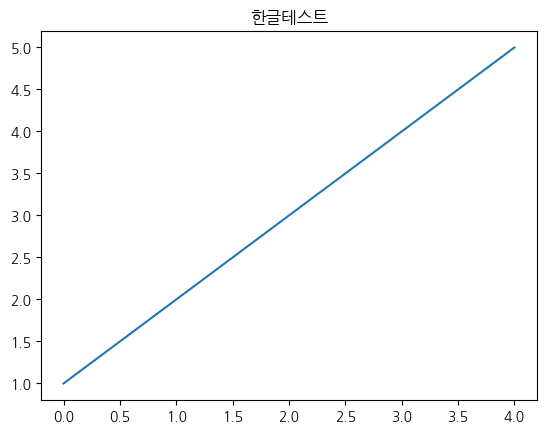

In [ ]:
#@title 차트에 한글 출력 테스트하기
import matplotlib.pyplot as plt
# 사용할 한글 글꼴을 지정한다.
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

plt.title('한글테스트')
plt.plot([1,2,3,4,5])
plt.show()

# 01 선형회귀

## 직선의 방정식 기본

$ y = ax + b $
또는 $ H(x) = Wx + b $

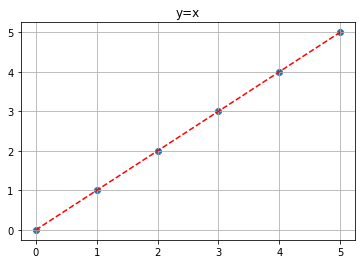

In [ ]:
import matplotlib.pyplot as plt
공부시간 = [0,1,2,3,4,5]
점수 = [0,1,2,3,4,5]
plt.title('y=x')
plt.scatter(공부시간, 점수)
plt.plot(공부시간, 점수, 'r--')
plt.grid(True)
plt.show()

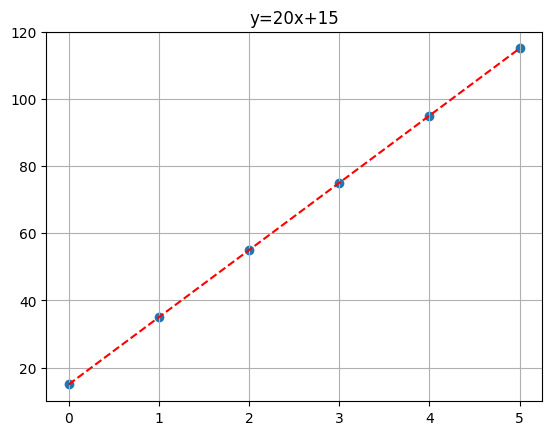

In [ ]:
# @title a와 b 변경해 보기
{"run":"auto"}
a = 20 # @param {"type":"integer"}
b = 15 # @param {"type":"integer"}
import numpy as np
import matplotlib.pyplot as plt
#a, b = 2, 10
x = np.array([0,1,2,3,4,5])
y = a*x+b #  [0,10,20,30,40,50]
plt.title(f'y={a}x+{b}')
plt.scatter(x, y)
plt.plot(x, y, 'r--')
plt.grid(True)
plt.show()

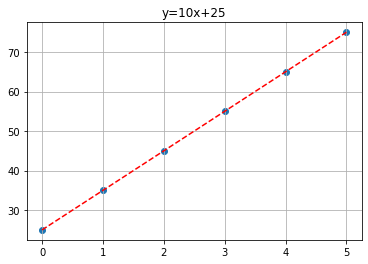

In [ ]:
import matplotlib.pyplot as plt
공부시간 = [0,1,2,3,4,5]
점수 = [i*10+25 for i in 공부시간]
plt.title('y=10x+25')
plt.scatter(공부시간, 점수)
plt.plot(공부시간, 점수, 'r--')
plt.grid(True)
plt.show()

## ※ 상관계수 correlation
- pandas : corr()
- 엑셀 : correl(), 기울기와 절편 : linest()

         공부시간       점수
공부시간  1.00000  0.87244
점수    0.87244  1.00000


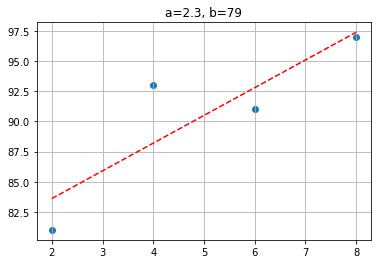

In [ ]:
import pandas as pd
공부시간 = [2,4,6,8]
점수 = [81,93,91,97]

df = pd.DataFrame({'공부시간':공부시간,'점수':점수})
print(df.corr())

import matplotlib.pyplot as plt
plt.title('a=2.3, b=79')
plt.scatter(공부시간, 점수)
plt.plot(공부시간, [i*2.3+79 for i in 공부시간], 'r--')
plt.grid(True)
plt.show()

## 파이썬 선형회귀 수식 및 코드
MSE와 편미분을 사용한다.

- MSE : $ \frac {1}{n} \sum(y_i-\hat{y_i})^2 = \frac {1}{n} \sum(y_i - (ax_i+b))^2$
- cost(a) : $ \frac{2}{n} \sum -x_i(y_i-(ax_i+b)) = \frac{2}{n} \sum -x_i(y_i-\hat{y_i})$
- cost(b) : $ \frac{2}{n} \sum -(y_i-(ax_i+b)) = \frac{2}{n} \sum -(y_i-\hat{y_i}) $
- a = a - 학습률 * cost(a), b = b - 학습률 * cost(b)

In [ ]:
#@title 왜 벡터/행렬 연산에 리스트가 아닌 numpy/pandas를 사용하는가?
# 리스트는 벡터/행렬 연산을 지원하지 않고 오류가 난다.
x = [2,4,6,8]
a, b = 2.3, 79
#y = []
#for i in x :
#  y.append(a * i + b)
#y

import numpy as np

x = np.array([2,4,6,8])
y = a * x + b
print(y)

import pandas as pd
x = pd.Series([2,4,6,8])
y = a * x + b
y

[83.6 88.2 92.8 97.4]


,0
0,83.6
1,88.2
2,92.8
3,97.4


In [ ]:
#@title 단순 선형회귀 수식대로 작성해 보기
%%time
#import warnings
#warnings.filterwarnings('ignore')

# a와 b 값에 난수로 초기화를 시키기 위해 random 사용
import random
# 벡터 계산을 편하게 하기 위해 numpy(또는 pandas) 사용
import numpy as np

x = np.array([2,4,6,8]) # 공부한 시간
y = np.array([81,93,91,97]) # 점수

# 임의의 수로 기울기 a와 절편 b를 초기화
a = b = random.random()
# 학습률(learning rate)
lr = 0.05
# 반복회수
epochs = 2000
# 평균을 내기 위한 요소의 수 (4)
n = len(x)
cost = []
for i in range(epochs) :
  y_hat = a * x + b
  error = y - y_hat
  a_der = sum(-x * error)/n # a에 대한 편미분 값
  b_der = sum(-error)/n     # b에 대한 편미분 값
  a = a - lr * a_der
  b = b - lr * b_der
  cost.append(sum((y-y_hat)**2)/n)
  # 200번 반복할 때 중간값 출력
  if i % 200 == 0 :
    print(f'i : {i}, 기울기 : {a:.3f}, 절편 : {b:.3f}')
# 최종 기울기 및 절편
print(f'기울기 : {a:.3f}, 절편 : {b:.3f}')

i : 0, 기울기 : 22.546, 절편 : 5.135
i : 200, 기울기 : 4.772, 절편 : 64.247
i : 400, 기울기 : 2.785, 절편 : 76.104
i : 600, 기울기 : 2.395, 절편 : 78.431
i : 800, 기울기 : 2.319, 절편 : 78.888
i : 1000, 기울기 : 2.304, 절편 : 78.978
i : 1200, 기울기 : 2.301, 절편 : 78.996
i : 1400, 기울기 : 2.300, 절편 : 78.999
i : 1600, 기울기 : 2.300, 절편 : 79.000
i : 1800, 기울기 : 2.300, 절편 : 79.000
기울기 : 2.300, 절편 : 79.000
CPU times: user 27.9 ms, sys: 987 µs, total: 28.9 ms
Wall time: 28.9 ms


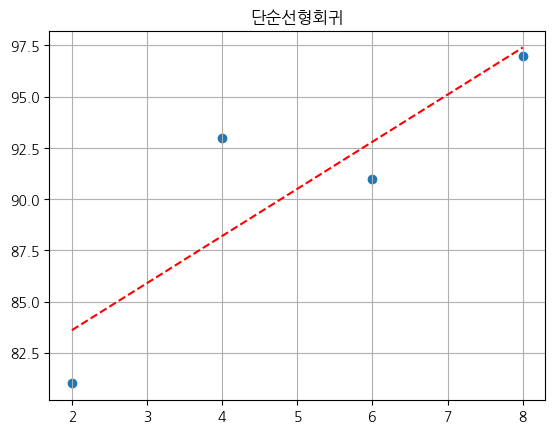

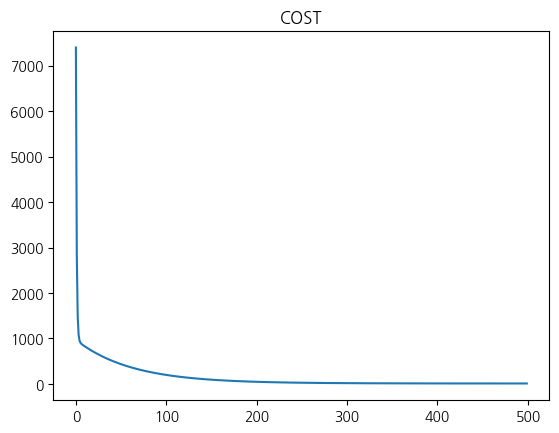

In [ ]:
#@title 단순선형회귀 결과 차트
# 예측선 긋기
pred = a * x + b

import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')

plt.title('단순선형회귀')
plt.grid(True)
plt.scatter(x, y)
plt.plot(x, pred, 'r--')
plt.show()

plt.title('COST')
plt.plot(cost[:500])
plt.show()

In [ ]:
#@title 1, 3, 5, 7시간 공부하면 몇 점?
import numpy as np

hours = np.array([1,3,5,7])
result = a * hours + b
print(result)

for i in enumerate(result) :
  print(f'{hours[i[0]]}시간 공부하면 {i[1]:.2f}점')

[81.29999464 85.8999968  90.49999896 95.10000111]
1시간 공부하면 81.30점
3시간 공부하면 85.90점
5시간 공부하면 90.50점
7시간 공부하면 95.10점


i : 0, 기울기 : 22.691, 10.517, 절편 : 4.739
i : 200, 기울기 : 3.717, 3.051, 절편 : 62.634
i : 400, 기울기 : 1.951, 2.441, 절편 : 74.761
i : 600, 기울기 : 1.592, 2.317, 절편 : 77.227
i : 800, 기울기 : 1.519, 2.292, 절편 : 77.729
i : 1000, 기울기 : 1.504, 2.287, 절편 : 77.831
i : 1200, 기울기 : 1.501, 2.286, 절편 : 77.852
i : 1400, 기울기 : 1.500, 2.286, 절편 : 77.856
i : 1600, 기울기 : 1.500, 2.286, 절편 : 77.857
i : 1800, 기울기 : 1.500, 2.286, 절편 : 77.857
기울기 : 1.500, 2.286, 절편 : 77.857


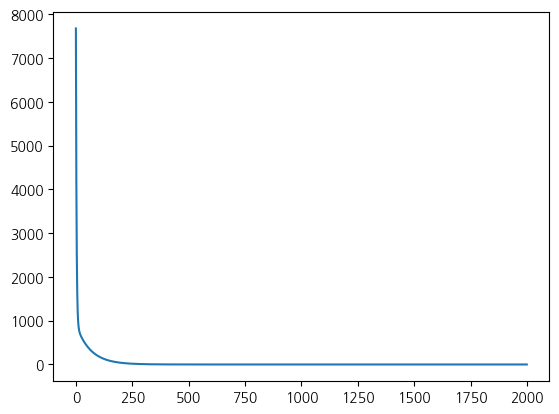

CPU times: user 137 ms, sys: 1.85 ms, total: 139 ms
Wall time: 138 ms


In [ ]:
#@title 다중 선형회귀 수식대로 작성해 보기
%%time
#import warnings
#warnings.filterwarnings('ignore')

# a와 b 값에 난수로 초기화를 시키기 위해 random 사용
import random
# 벡터 계산을 편하게 하기 위해 numpy(또는 pandas) 사용
import numpy as np

x1 = np.array([2,4,6,8]) # 공부한 시간
x2 = np.array([0,4,2,3]) # 과외 횟수
y = np.array([81,93,91,97]) # 점수

# 임의의 수로 기울기 a와 절편 b를 초기화
a1 = a2 = b = random.random()
# 학습률(learning rate)
lr = 0.05
# 반복회수
epochs = 2000
# 평균을 내기 위한 요소의 수 (4)
n = len(x)
cost = []

for i in range(epochs) :
  y_hat = a1 * x1 + a2 * x2 + b
  error = y - y_hat
  a1_der = sum(-x1 * error)/n # a1에 대한 편미분 값
  a2_der = sum(-x2 * error)/n # a2에 대한 편미분 값
  b_der = sum(-error)/n     # b에 대한 편미분 값
  a1 = a1 - lr * a1_der
  a2 = a2 - lr * a2_der
  b = b - lr * b_der
  cost.append(sum((y-y_hat)**2)/n)
  # 200번 반복할 때 중간값 출력
  if i % 200 == 0 :
    print(f'i : {i}, 기울기 : {a1:.3f}, {a2:.3f}, 절편 : {b:.3f}')

# 최종 기울기 및 절편
print(f'기울기 : {a1:.3f}, {a2:.3f}, 절편 : {b:.3f}')

# 예측선 긋기
#pred = a1 * x1 + a2 * x2 + b

import matplotlib.pyplot as plt

plt.plot(cost)
plt.show()

## 연습 - 공식대로 python으로 작성해 보기

a:0.14, b:0.16, mse:8068.02
a:4.81, b:64.01, mse:45.74
a:2.79, b:76.06, mse:9.74
a:2.40, b:78.42, mse:8.36
a:2.32, b:78.89, mse:8.30


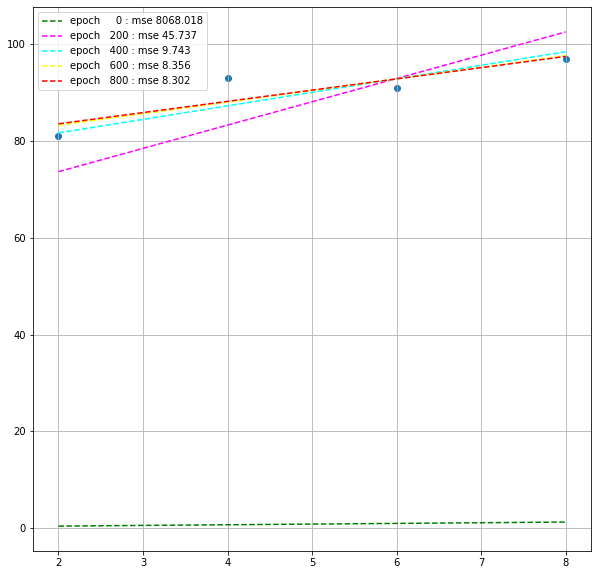

a:2.30, b:78.98, mse:8.30


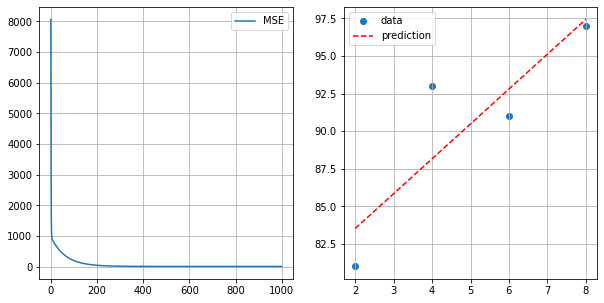

In [ ]:
#@title 선형회귀 기초
import random
import matplotlib.pyplot as plt
import pandas as pd

# 입력과 출력 값
data = pd.DataFrame({'x':[2,4,6,8], 'y':[81,93,91,97]})

learningrate = 0.05  # 학습률
# 기울기와 절편을 난수로 초기화
a = random.random()
b = random.random()
# 학습 반복 횟수
epochs = 1000
# 평균을 구하기 위한 입력 값의 수
n = len(data.x)
# MSE를 저장하기 위한 리스트
mse_list = []
# 그래프 출력 시 단계별로 색상을 변경하기 위한 색상 리스트
# 맨 뒤의 색부터 사용한다.
colors=['red','yellow','cyan','magenta','green']
# 먼저 입출력 값에 대한 산점도를 그려 준다.
plt.figure(figsize=(10,10))
plt.grid(True)
plt.scatter(data.x, data.y)
# 반복 학습
for i in range(epochs) :
  # 위 식에 의해 작성한다. 여기에서 분자의 2는 학습률을 수정하면 되므로 생략
  cost_a = sum(-data.x*(data.y-(a*data.x+b)))/n
  cost_b = sum(-(data.y-(a*data.x+b)))/n
  # 매 반복 마다 MSE를 구하여 리스트에 저장한다.
  mse = sum((data.y - (data.x * a + b))**2)/n
  mse_list.append(mse)
  # 중간 출력, 5회로 제한하였다.
  if i % (epochs / 5) == 0 :
    print(f'a:{a:.2f}, b:{b:.2f}, mse:{mse_list[len(mse_list)-1]:.2f}')
    # 학습 중간 결과 직선을 그리기 위해 출력값 저장 및 그래프 그리기
    data['res'] = a * data.x + b
    # 출력 라벨 텍스트 형식(자리수) 지정
    lbl = 'epoch {i:>5} : mse {mse:.3f}'.format(i=i, mse=mse)
    plt.plot(data.x, data.res, linestyle='dashed', color=colors.pop(), label=lbl)
  # 경사하강법(Gradient Descent Algorithm)
  a = a - learningrate * cost_a
  b = b - learningrate * cost_b
plt.legend()
plt.show()

# 결과 출력
print(f'a:{a:.2f}, b:{b:.2f}, mse:{mse_list[len(mse_list)-1]:.2f}')
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.grid(True)
plt.plot(mse_list, label='MSE')
plt.legend()
plt.subplot(122)
plt.grid(True)
plt.scatter(data.x, data.y, label='data')
plt.plot(data.x, data.res, 'r--', label='prediction')
plt.legend()
plt.show()

## tensorflow 사용하기 - 단순선형회귀

In [ ]:
#@title 모델생성, 컴파일, 학습
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

# 입출력값 설정
x = np.array([2,4,6,8]) # 공부한 시간
y = np.array([81,93,91,97]) # 점수

# 모델 생성
model = Sequential()
model.add(Dense(1, input_dim=1, activation='linear'))
# 모델 컴파일
model.compile(loss='mse', optimizer='sgd')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 학습 실행
hist = model.fit(x, y, epochs=2000, verbose=1)

Epoch 1/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step - loss: 8752.0137
Epoch 2/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 2115.7896
Epoch 3/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 1135.7639
Epoch 4/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 986.5262
Epoch 5/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 959.3453
Epoch 6/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 950.1254
Epoch 7/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 943.5774
Epoch 8/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 937.4554
Epoch 9/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 931.4293
Epoch 10/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 925.4506
Epoch 11/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 919.5120
Epoch 12/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 913.6118
Epoch 13/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 907.7499
Epoch 14/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 901.9259
Epoch 15/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
#@title 결과 점검
print(model.evaluate(x,y))
print(model.get_weights())
print(model.predict(x))

# 예측하기
import numpy as np
import pandas as pd
data = np.arange(1,9)
print('예측 결과 (Pandas Series)')
res = pd.DataFrame(model.predict(data).flatten(), index=range(1,9), columns=['점수'])
res.index.name = '공부시간'
res

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 8.3022
8.302228927612305
[array([[2.319385]], dtype=float32), array([78.884315], dtype=float32)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
[[83.52309]
 [88.16186]
 [92.80063]
 [97.43939]]
예측 결과 (Pandas Series)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


,점수
공부시간,
1,81.203697
2,83.523087
3,85.842468
4,88.161858
5,90.481239
6,92.800629
7,95.120010
8,97.439392


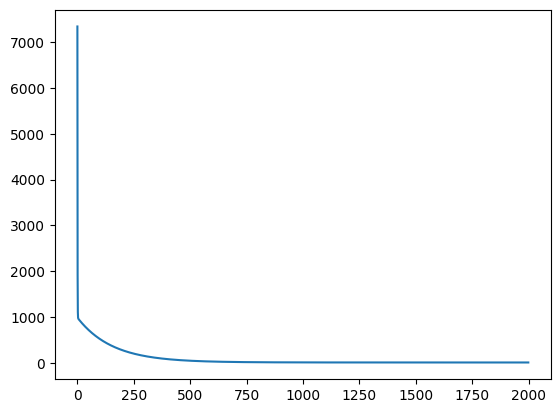

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


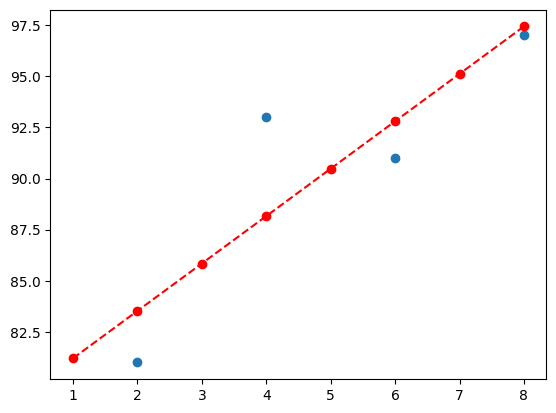

In [ ]:
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'])
plt.show()

plt.scatter(x, y)
plt.plot(data, model.predict(data), 'ro--')
plt.show()

## tensorflow 사용하기 - 다중선형회귀

In [ ]:
#@title 모델생성, 컴파일, 학습
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

# 입출력값 설정
x = np.array([[2,0],[4,4],[6,2],[8,3]]) # 공부한 시간
y = np.array([81,93,91,97]) # 점수

# 모델 생성
model = Sequential()
model.add(Dense(1, input_dim=2, activation='linear'))
# 모델 컴파일
model.compile(loss='mse', optimizer='sgd')
# 학습 실행
hist = model.fit(x, y, epochs=2000, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#@title 결과 점검
print(model.evaluate(x,y))
print(model.get_weights())
print(model.predict(x))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 0.0742
0.07424556463956833
[array([[1.5191807],
       [2.292337 ]], dtype=float32), array([77.72545], dtype=float32)]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
[[80.76381 ]
 [92.97152 ]
 [91.42521 ]
 [96.755905]]


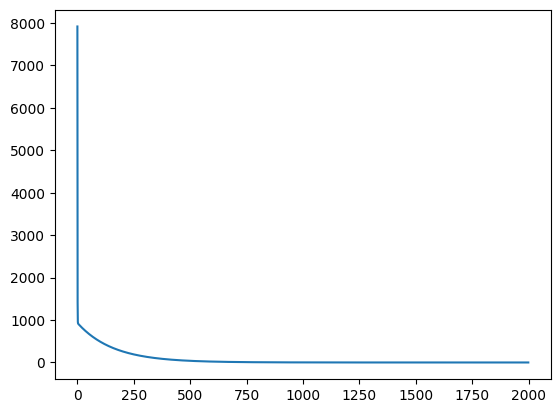

In [ ]:
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'])
plt.show()

# 실전 연습 : seaborn tips 데이터를 사용한 선형회귀
- seaborn 패키지에 내장된 tips 데이터를 사용해 선형회귀값을 구해 본다.
- 데이터를 표준화(standardization)해야 동작한다.

In [ ]:
#@title Tips data loading
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
import seaborn as sns

# 결제금액, 팁, 성별, 흡연여부, 요일, 시간, 동반손님수
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


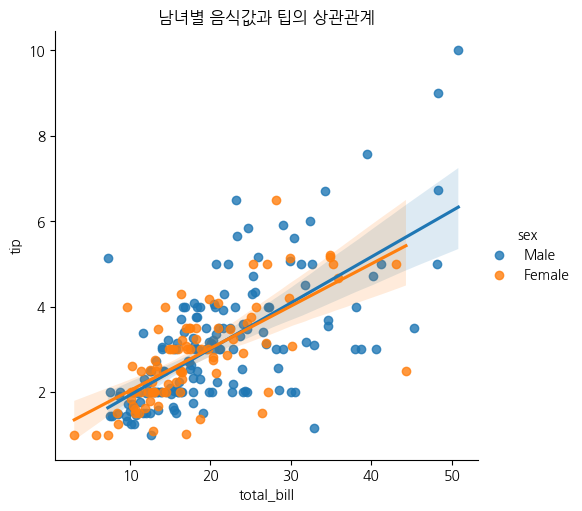

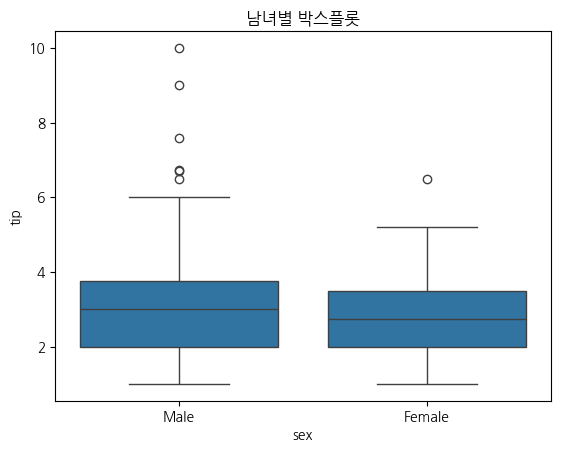

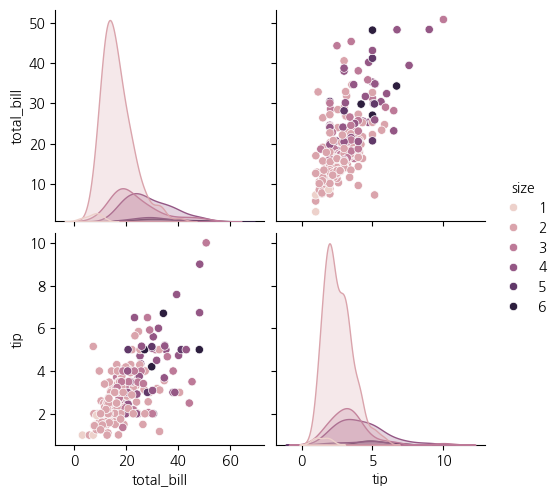

In [ ]:
#@title Tips data chart
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')

# 남녀별 결제금액과 팁의 관계를 산포도로 그려보기
sns.lmplot(data=tips, x='total_bill', y='tip', hue='sex').set(title='남녀별 음식값과 팁의 상관관계')
plt.show()
# 남녀별 팁의 상자수염그림 그리기
sns.boxplot(data=tips, x='sex', y='tip').set(title='남녀별 박스플롯')
plt.show()

sns.pairplot(data=tips, hue='size')
plt.show()

## 단순선형회귀

### Tips : Python으로만 작성하기

     0회 - mse:10.8963, a:0.0676, b:0.0030
   100회 - mse:1.1716, a:0.1428, b:0.0214
   200회 - mse:1.1672, a:0.1422, b:0.0363
   300회 - mse:1.1628, a:0.1416, b:0.0510
   400회 - mse:1.1587, a:0.1410, b:0.0654
   500회 - mse:1.1546, a:0.1404, b:0.0796
   600회 - mse:1.1507, a:0.1398, b:0.0936
   700회 - mse:1.1469, a:0.1392, b:0.1073
   800회 - mse:1.1433, a:0.1387, b:0.1208
   900회 - mse:1.1398, a:0.1381, b:0.1341
최종 mse:1.1364, a:0.1376, b:0.1470


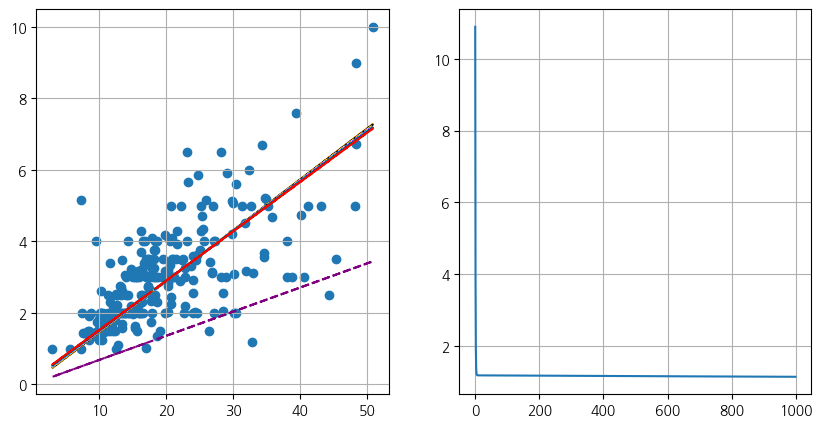

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = tips.total_bill
y = tips.tip

n = len(x)
a = 0
b = 0
mses = []
lr = 0.001
epochs=1000
colors = ['red','green','blue','cyan','magenta','yellow','gray','black','orange','purple']
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.grid(True)
plt.scatter(x,y)

for i in range(epochs) :
    mse = sum((y-(a*x+b))**2) / n
    mses.append(mse)
    delta_a = sum(-x*(y-(a*x+b))) / n
    delta_b = sum(-(y-(a*x+b))) / n
    a = a - lr * delta_a
    b = b - lr * delta_b
    if i % (epochs // 10) == 0 :
        print(f'{i:>6,d}회 - mse:{mse:.4f}, a:{a:.4f}, b:{b:.4f}')
        plt.plot(x, a*x+b, color=colors.pop(), linestyle='dashed')

print(f'최종 mse:{mse:.4f}, a:{a:.4f}, b:{b:.4f}')
plt.subplot(122)
plt.grid(True)
plt.plot(mses)
plt.show()

### tensorflow 사용

In [ ]:
import pandas as pd

pd.crosstab(tips.time, tips.sex, margins=True, normalize='all')

sex,Male,Female,All
time,,,
Lunch,0.135246,0.143443,0.278689
Dinner,0.508197,0.213115,0.721311
All,0.643443,0.356557,1.000000


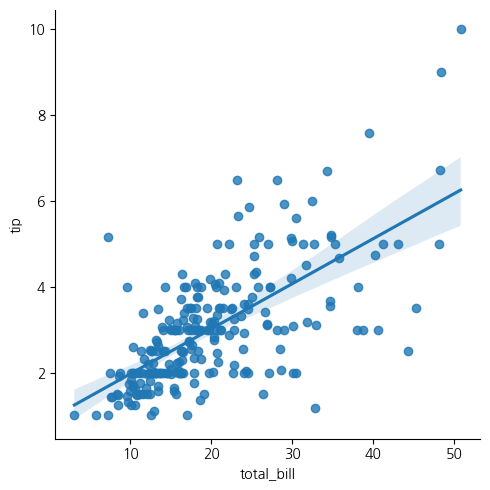

In [ ]:
#@title 상관 차트 그리기
sns.lmplot(data=tips, x='total_bill', y='tip')

In [ ]:
#@title 상관계수 구해보기
tips.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

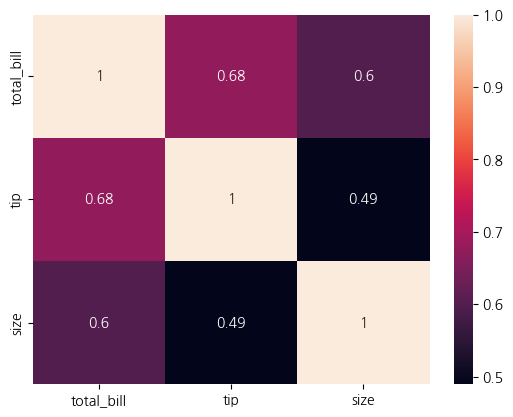

In [ ]:
#@title heatmap 그려보기
sns.heatmap(tips.corr(numeric_only=True), annot=True)

#### 데이터 표준화와 정규화
참조 사이트 : https://k-jirung.tistory.com/52

- 표준화 : 평균값을 뺀 후 표준편차로 나누기
 1.  데이터의 평균을 0, 표준편차를 1로 변환하는 기법
 1. 서로 다른 단위를 가진 데이터를 동일한 척도로 변환하는 데 사용

$ X_{standardized} = \frac {X-\mu}{\sigma} $


- 정규화 : 최소값을 뺀 후 최대값에서 최소값을 뺀 값으로 나누기
 1. 데이터를 특정 범위(일반적으로 0과 1)로 변환하는 기법


$ X_{normalized} = \frac {X - X_{min}} {X_{max} - X_{min}}$

In [ ]:
#@title tips 데이터 표준화
# tips.total_bill, tip 데이터 표준화, 표준화하지 않으면 학습이 안된다.
# pandas mean() : 평균, pandas std() : 표준편차
tips['x'] = (tips.total_bill - tips.total_bill.mean())/tips.total_bill.std()
tips['y'] = (tips.tip - tips.tip.mean())/tips.tip.std()
tips[['x','y']].head()

,x,y
0,-0.314066,-1.436993
1,-1.061054,-0.967217
2,0.137497,0.362610
3,0.437416,0.225291
4,0.539635,0.442111


#### 모델 생성, 컴파일, 학습

In [ ]:
#@title 모델 만들기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(1, input_dim=1, activation='linear'))
model.compile(optimizer='sgd', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#@title 모델 학습
#hist = model.fit(tips.x, tips.y, epochs=500, verbose=0)
hist = model.fit(tips.total_bill, tips.tip, epochs=500, verbose=0)

<Axes: >

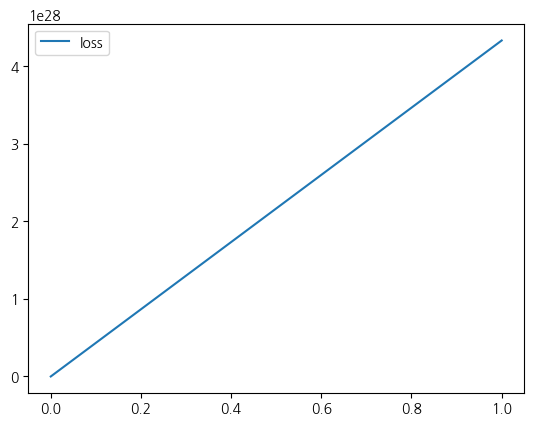

In [ ]:
#@title loss 곡선 출력
import pandas as pd
pd.DataFrame(hist.history).plot()

In [ ]:
# 결과 평가
model.evaluate(tips.x, tips.y)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: nan 


nan

In [ ]:
# 가중치 가져오기
model.get_weights()

[array([[nan]], dtype=float32), array([nan], dtype=float32)]

In [ ]:
# 예측값 구해 보기
pred = pd.DataFrame(model.predict(tips.x))
pred.head()

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,0
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [ ]:
#@title pred를 표준화 이전 원래 값으로 환원
tips['pred'] = (pred * tips.tip.std()) + tips.tip.mean()
tips[['total_bill', 'tip', 'pred']].head()

,total_bill,tip,pred
0,16.99,1.01,2.703113
1,10.34,1.66,2.004802
2,21.01,3.50,3.125251
3,23.68,3.31,3.405625
4,24.59,3.61,3.501184


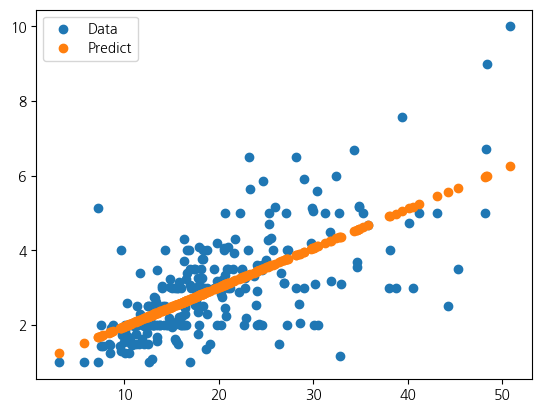

In [ ]:
# 차트로 그려보기
import matplotlib.pyplot as plt
plt.scatter(tips.total_bill, tips.tip, label='Data')
plt.scatter(tips.total_bill, tips.pred, label='Predict')
plt.legend()

## 다중 선형회귀 : Tips 데이터

- total_bill, size와 tip
- size : 식사한 인원수

In [ ]:
tipsm = tips
tipsm['gender'] = pd.get_dummies(tips.sex).iloc[:,0]
tipsm.head()

,total_bill,tip,sex,smoker,day,time,size,gender
0,16.99,1.01,Female,No,Sun,Dinner,2,False
1,10.34,1.66,Male,No,Sun,Dinner,3,True
2,21.01,3.50,Male,No,Sun,Dinner,3,True
3,23.68,3.31,Male,No,Sun,Dinner,2,True
4,24.59,3.61,Female,No,Sun,Dinner,4,False


In [ ]:
tipsm.corr(numeric_only=True)

,total_bill,tip,size,gender
total_bill,1.000000,0.675734,0.598315,0.144877
tip,0.675734,1.000000,0.489299,0.088862
size,0.598315,0.489299,1.000000,0.086195
gender,0.144877,0.088862,0.086195,1.000000


In [ ]:
pd.crosstab(tipsm.smoker, tipsm.sex, margins=True) # normalize='all'

sex,Male,Female,All
smoker,,,
Yes,60,33,93
No,97,54,151
All,157,87,244


<Axes: xlabel='size', ylabel='total_bill'>

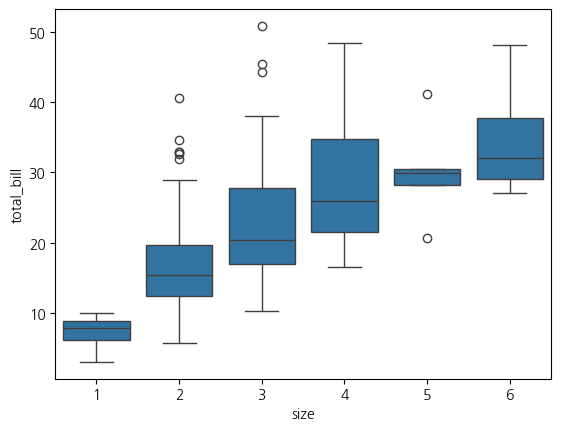

In [ ]:
sns.boxplot(data=tips, x='size', y='total_bill')

AttributeError: 'DataFrame' object has no attribute 'pred'

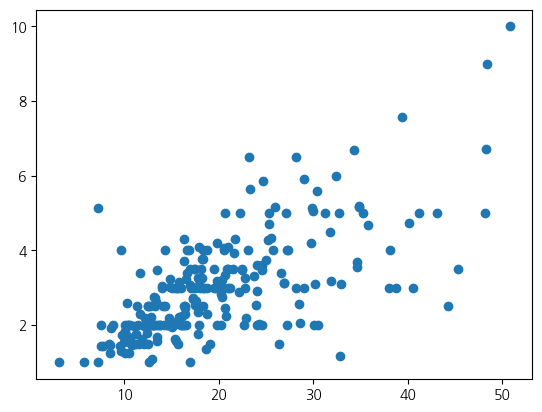

In [ ]:
# 차트로 그려보기
import matplotlib.pyplot as plt
plt.scatter(tipsm.total_bill, tipsm.tip, label='Data')
plt.scatter(tipsm.total_bill, tipsm.pred, label='Predict')
plt.legend()

In [ ]:
model.evaluate(x, tips.y)

8/8 [==============================] - 0s 2ms/step - loss: 0.5317


0.531661868095398

In [ ]:
pred = model.predict(x)
pred = (pred * tipsm.tip.std())+tipsm.tip.mean()
tipsm['pred'] = pred
tipsm.head()

8/8 [==============================] - 0s 2ms/step


,total_bill,tip,sex,smoker,day,time,size,gender,x,y,pred
0,16.99,1.01,Female,No,Sun,Dinner,2,0,-0.314066,-1.436993,2.671920
1,10.34,1.66,Male,No,Sun,Dinner,3,1,-1.061054,-0.967217,2.265972
2,21.01,3.50,Male,No,Sun,Dinner,3,1,0.137497,0.362610,3.257056
3,23.68,3.31,Male,No,Sun,Dinner,2,1,0.437416,0.225291,3.293322
4,24.59,3.61,Female,No,Sun,Dinner,4,0,0.539635,0.442111,3.801322


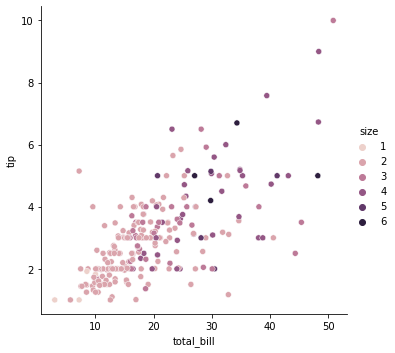

In [ ]:
sns.relplot(data=tipsm, x='total_bill', y='tip', hue='size')

In [ ]:
# tips.total_bill, tip 데이터 표준화, 표준화하지 않으면 학습이 안된다.
tipsm['x'] = (tipsm.total_bill - tipsm.total_bill.mean())/tipsm.total_bill.std()
tipsm['y'] = (tipsm.tip - tipsm.tip.mean())/tipsm.tip.std()
tipsm[['x','size', 'y']].head()

,x,size,y
0,-0.314066,2,-1.436993
1,-1.061054,3,-0.967217
2,0.137497,3,0.362610
3,0.437416,2,0.225291
4,0.539635,4,0.442111


In [ ]:
# 모델 만들기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(1, input_dim=2, activation='linear'))
model.compile(optimizer='sgd', loss='mse')

In [ ]:
# 모델 학습
import numpy as np
x = np.array(tipsm[['x','size']])
hist = model.fit(x, tips.y, epochs=500, verbose=0)

<AxesSubplot:>

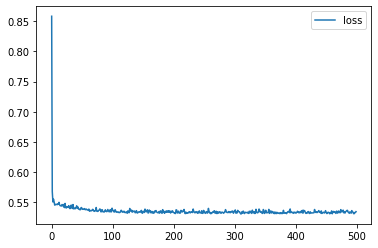

In [ ]:
# loss 곡선 출력
import pandas as pd
pd.DataFrame(hist.history).plot()

<Axes: >

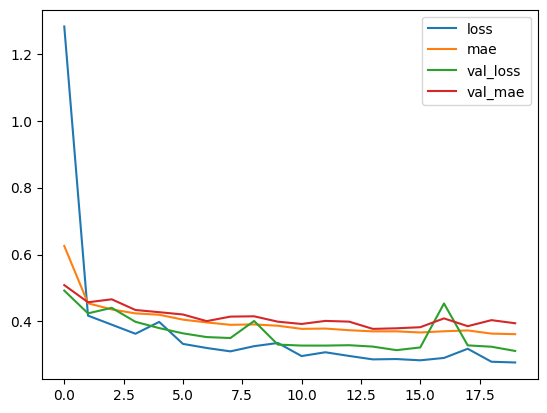

In [ ]:
import pandas as pd
pd.DataFrame(history.history).plot()

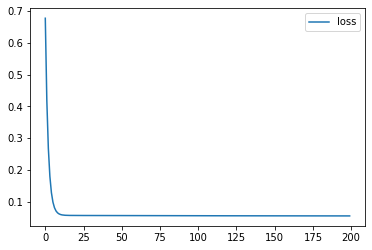

1/1 [==============================] - 0s 55ms/step


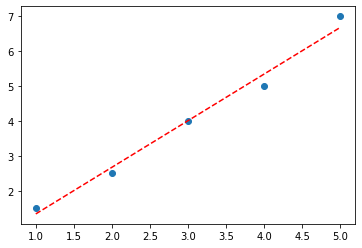

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(hist.history).plot()
plt.show()

plt.scatter(x, y)
plt.plot(x, model.predict(x), 'r--')
plt.show()

## 다중선형회귀 : California housing example

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
housing = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(housing.data, housing.target, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the model
model = tf.keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=[X_train.shape[1]]),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, epochs=20, validation_split=0.2)

# Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
print(f"Mean Absolute Error on test set: {mae}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2.4245 - mae: 0.8370 - val_loss: 0.4923 - val_mae: 0.5087
Epoch 2/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4418 - mae: 0.4695 - val_loss: 0.4243 - val_mae: 0.4575
Epoch 3/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4139 - mae: 0.4429 - val_loss: 0.4408 - val_mae: 0.4663
Epoch 4/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3631 - mae: 0.4269 - val_loss: 0.3990 - val_mae: 0.4343
Epoch 5/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3675 - mae: 0.4168 - val_loss: 0.3802 - val_mae: 0.4278
Epoch 6/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3258 - mae: 0.4011 - val_loss: 0.3646 - val_mae: 0.4209
Epoch 7/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.3331 - mae: 0.4062 - val_loss: 0.3534 - val_mae: 0.4011
Epoch 8/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.3070 - mae: 0.3891 - val_loss: 0.3505 - val_mae: 0.4146
Epoch 9/20
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - lo

# 일정 epoch마다 출력하는 콜백 함수
- on_epoch_end() 함수 사용

https://www.tensorflow.org/guide/keras/custom_callback?hl=ko

In [ ]:
#@title 일정한 epoch마다 출력하는 콜백 추가
import tensorflow.keras as keras
class CustomCallback(keras.callbacks.Callback):
    def __init__(self, epoch=100) :
      self.epoch = epoch

    def on_train_begin(self, logs=None):
        keys = list(logs.keys())
#        print("Starting training; got log keys: {}".format(keys))

    def on_train_end(self, logs=None):
        keys = list(logs.keys())
        a, b = self.model.get_weights()
        l = logs.get('loss')
        print('\nFinal Weight : %.3f, Bias : %.3f, Loss : %.3f'%(a,b,l)) #print("End epoch {} of training; got log keys: {}".format(epoch, keys))
        print('\nTraining Finished.\n')
#        print("Stop training; got log keys: {}".format(keys))

    def on_epoch_begin(self, epoch, logs=None):
        keys = list(logs.keys())
#        print("Start epoch {} of training; got log keys: {}".format(epoch, keys))

    def on_epoch_end(self, epoch, logs=None):
        keys = list(logs.keys())
        if epoch % self.epoch == 0 :
            a, b = self.model.get_weights()
            l = logs.get('loss')
            print('\nEpoch : %d, Weight : %.3f, Bias : %.3f, Loss : %.3f'%(epoch,a,b,l)) #print("End epoch {} of training; got log keys: {}".format(epoch, keys))
        else:
          if epoch % 10 == 0 :
            print('o', end='')
          else :
            print('.', end='')

    def on_test_begin(self, logs=None):
        keys = list(logs.keys())
#        print("Start testing; got log keys: {}".format(keys))

    def on_test_end(self, logs=None):
        keys = list(logs.keys())
#        print("Stop testing; got log keys: {}".format(keys))

    def on_predict_begin(self, logs=None):
        keys = list(logs.keys())
#        print("Start predicting; got log keys: {}".format(keys))

    def on_predict_end(self, logs=None):
        keys = list(logs.keys())
#        print("Stop predicting; got log keys: {}".format(keys))

    def on_train_batch_begin(self, batch, logs=None):
        keys = list(logs.keys())
#        print("...Training: start of batch {}; got log keys: {}".format(batch, keys))

    def on_train_batch_end(self, batch, logs=None):
        keys = list(logs.keys())
#        print("...Training: end of batch {}; got log keys: {}".format(batch, keys))

    def on_test_batch_begin(self, batch, logs=None):
        keys = list(logs.keys())
#        print("...Evaluating: start of batch {}; got log keys: {}".format(batch, keys))

    def on_test_batch_end(self, batch, logs=None):
        keys = list(logs.keys())
#        print("...Evaluating: end of batch {}; got log keys: {}".format(batch, keys))

    def on_predict_batch_begin(self, batch, logs=None):
        keys = list(logs.keys())
#        print("...Predicting: start of batch {}; got log keys: {}".format(batch, keys))

    def on_predict_batch_end(self, batch, logs=None):
        keys = list(logs.keys())
#        print("...Predicting: end of batch {}; got log keys: {}".format(batch, keys))

In [ ]:
#@title callback 함수 사용 예
%%time
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd

x = pd.Series([1, 2, 3, 4, 5])
y = pd.Series([1.5,2.5,4,5,7])

model = Sequential()
model.add(Dense(1, input_dim=1, activation='linear'))
model.compile(loss='mse', optimizer='sgd')
hist = model.fit(x, y, epochs=500, batch_size=5, verbose=0, callbacks=[CustomCallback(100)])


Epoch : 0, Weight : 1.143, Bias : 0.015, Loss : 0.732
.........o.........o.........o.........o.........o.........o.........o.........o.........o.........
Epoch : 100, Weight : 1.328, Bias : 0.031, Loss : 0.056
.........o.........o.........o.........o.........o.........o.........o.........o.........o.........
Epoch : 200, Weight : 1.334, Bias : 0.008, Loss : 0.056
.........o.........o.........o.........o.........o.........o.........o.........o.........o.........
Epoch : 300, Weight : 1.339, Bias : -0.009, Loss : 0.055
.........o.........o.........o.........o.........o.........o.........o.........o.........o.........
Epoch : 400, Weight : 1.342, Bias : -0.021, Loss : 0.055
.........o.........o.........o.........o.........o.........o.........o.........o.........o.........
Final Weight : 1.344, Bias : -0.029, Loss : 0.055

Training Finished.

CPU times: user 15.5 s, sys: 935 ms, total: 16.4 s
Wall time: 19.4 s


# 02 로지스틱 회귀 (이항분류)
- 시그모이드 함수(교재 101쪽) : $ \frac{1}{1+e^{-(ax+b)}}$
- 크로스엔트로피 함수(cost) : $ cost(h(x), y) = \frac{1}{n}\sum-(ylogh+(1-y)log(1-h))$
- 학습 공식 : $ \theta_j = \theta_j-\alpha \frac{1}{m}\sum(h_\theta(x^i)-y^i)x^i_j (모든 \theta_j 동시에 업데이트) $
-- 출처 : https://brunch.co.kr/@linecard/477


[파이썬 구현 튜터리얼](https://medium.com/geekculture/machine-learning-logistic-regression-in-python-from-scratch-3d9e2875f27a)
[파이썬 구현](https://yamalab.tistory.com/79)

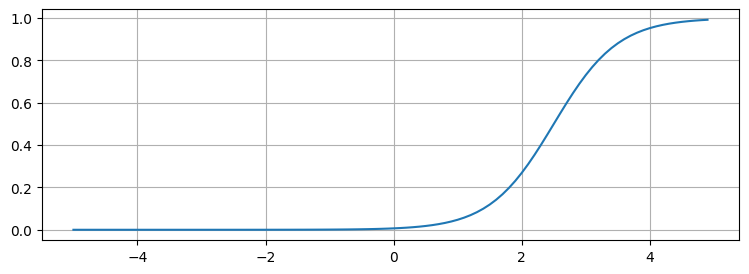

In [ ]:
# @title 시그모이드함수 {"run":"auto","form-width":"250px"}
a = 2 # @param {"type":"slider","min":0,"max":10,"step":0.5}
b = -5 # @param {"type":"slider","min":-5,"max":5,"step":0.5}
# 시그모이드 함수 그래프
import numpy as np
import math
# a는 경사 결정, b는 좌우 결정
x = np.array([i/10 for i in range(-50,50)])
#y = [1/(1+math.exp(-(x[i]*a+b))) for i in range(len(x))]
y = 1/(1+np.exp(-(x*a+b)))
import matplotlib.pyplot as plt
plt.figure(figsize=(9,3))
plt.grid(True)
plt.plot(x,y)
plt.show()

## 교차엔트로피함수 (crossentropy)

$ -{ylogh+(1-y)log(1-h)} $

where y is 0 or 1

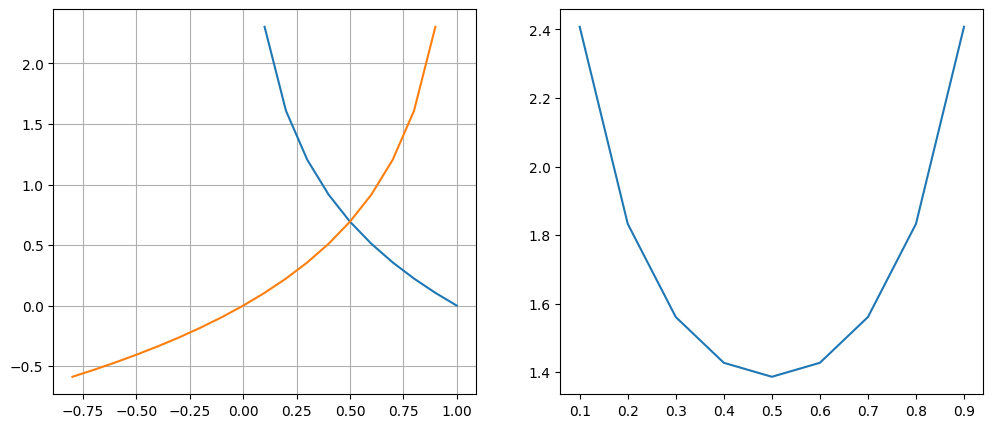

In [ ]:
#@title 105쪽 교차엔트로피 함수 차트 그리기
# 교차엔트로피(cross entropy)함수:오차(cost) 계산에 사용
import warnings
warnings.filterwarnings('ignore')
import numpy as np

# x : -.8, -.7 ... 0 ... .9, 1
x = np.array([i/10 for i in range(-8,11)])
y1 = -(np.log(x)) # when y = 1
y2 = -np.log(1-x) # when y = 0

# 두 함수를 하나로 합치기
y = -(np.log(x) + np.log(1-x))

# 차트로 그려보기
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

# 1행 1열 차트
plt.subplot(121)
plt.grid(True)
plt.plot(x,y1)
plt.plot(x,y2)
# 1행 2열 차트
plt.subplot(122)
plt.plot(x,y)
plt.show()

### 수작업으로 찾아 보기

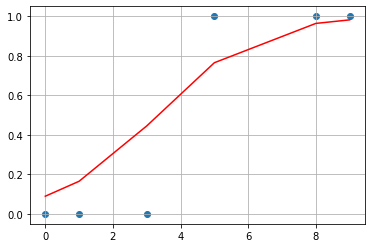

In [ ]:
#@title 수작업으로 찾아 보기
import matplotlib.pyplot as plt
import numpy as np

def H(z) :
  return 1/(1+np.exp(-z))

x = [0,1,3,5,8,9]
y = [0,0,0,1,1,1]
a = 0.7
b = -2.32

plt.grid(True)
plt.scatter(x, y)
plt.plot(x, H(np.array(x)*a+b), 'r')
plt.show()

### 파이썬 코드

#### ※ 표준화와 정규화
[출처](https://heeya-stupidbutstudying.tistory.com/entry/%ED%86%B5%EA%B3%84-%EC%A0%95%EA%B7%9C%ED%99%94%EC%99%80-%ED%91%9C%EC%A4%80%ED%99%94)

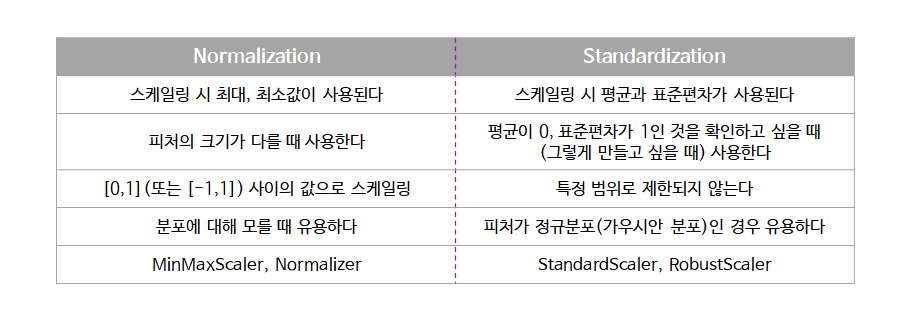

#### 수식
- 표준화(Standardization) : $ \frac{x-\mu}{\sigma}$
- - 평균이 0, 분산이 1인 데이터
- 정규화(Normalization) : $ \frac{x-x_{min}}{x_{max}-x_{min}}$
- - 0과 1 사이의 데이터
- 표준화된 데이터를 이용하여 훈련하면, 새로운 입력 값으로 예측할 때 ***훈련 데이터의 평균과 표준편차를 이용하여 표준화***를 한 후 예측 입력값으로 사용해야 한다.

In [ ]:
# 표준화된 데이터의 사용 예
import numpy as np
from tensorflow import keras

# 훈련 데이터에서 평균과 표준편차 추출
mean = np.mean(train_data, axis=0)
std = np.std(train_data, axis=0)

# 새로운 데이터 표준화
new_data = (new_data - mean) / std

# 모델 로드
model = keras.models.load_model('my_model.h5')

# 새로운 데이터 예측
prediction = model.predict(new_data)


#### 데이터 저장

In [ ]:
%%writefile data.csv
x,y
1,0
2,0
3,0
5,1
6,1
8,1

Writing data.csv


### 1변수 로지스틱 회귀
- numpy를 사용하지 않아 속도가 느리다.

#### 간단 버전

weight : 0.101, delta : -0.424, loss : 0.649
weight : 4.148, delta : -0.031, loss : 0.068
weight : 5.287, delta : -0.018, loss : 0.042
weight : 6.025, delta : -0.013, loss : 0.031
weight : 6.580, delta : -0.010, loss : 0.025
weight : 7.028


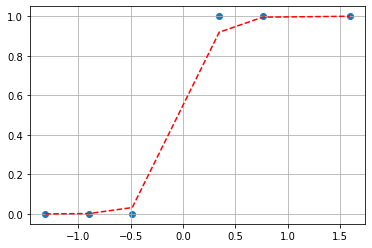

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data.csv')
x = df.x
y = df.y
m = len(x)
x = (x - np.mean(x)) / np.std(x)
#x,y
w = np.random.rand()
epochs = 5000
lr = 0.05

def sigmoid(z) :
  return 1/(1+np.exp(-z))

def cost(h, y) :
  return np.sum(-(y*np.log(h)+(1-y)*np.log(1-h)))/m

for i in range(epochs) :
  delta = sum((sigmoid(x*w) - y)*x) / m
  loss = cost(sigmoid(x*w), y)
  if i % (epochs / 5) == 0 :
    print(f'weight : {w:.3f}, delta : {delta:.3f}, loss : {loss:.3f}')
  w = w - delta * lr

print(f'weight : {w:.3f}')

plt.grid(True)
plt.scatter(x,y)
plt.plot(x, sigmoid(x*w), 'r--')
plt.show()

#### 나은 버전

CPU times: user 4 µs, sys: 1 µs, total: 5 µs
Wall time: 7.87 µs
epoch 0 손실 함수 값: 0.649
epoch 2,000 손실 함수 값: 0.344
epoch 4,000 손실 함수 값: 0.250
epoch 6,000 손실 함수 값: 0.199
epoch 8,000 손실 함수 값: 0.166
가중치:  0    2.501512
1    2.778639
2    2.701433
3    2.347714
4    2.835511
5    2.316189
dtype: float64
0.39176518564788165


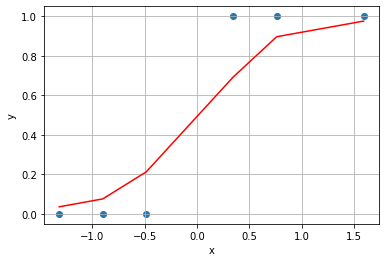

In [ ]:
%time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 로드
data = pd.read_csv("data.csv")
# 독립 변수 x와 종속 변수 y 분리
x = data.x
y = data.y
# 데이터 표준화
x = (x - np.mean(x)) / np.std(x)
# 반복횟수와 학습률, weight 초기화
epochs = 10000
lr = 0.01
w = np.random.rand()

# 시그모이드 함수 정의
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 손실 함수 정의
def loss(h, y):
    return (-y * np.log(h) - (1 - y) * np.log(1 - h)).mean()

# 반복 학습
for i in range(epochs):
    # 선형 모델 생성
    z = x * w
    # 시그모이드 함수 적용
    h = sigmoid(z)
    # 경사 하강법
    gradient = x * (h-y) / y.size
    w -= lr * gradient
    # 손실 함수 출력
    if i % (epochs / 5) == 0:
        h = sigmoid(x * w)
        print(f"{i:,} epochs 손실 함수 값: {loss(h, y):.3f}")

print("가중치: ", w)
print(sigmoid(np.dot(x, w)))

# 시각화
plt.grid(True)
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.plot(x, sigmoid(x * w), color='red')
plt.show()

### 2변수 Numpy 기능 사용 : x 변수 피처 갯수와 관계 없음

#### 데이터 저장

In [ ]:
%%writefile data.csv
x1,x2,y
1,1,0
2,1,0
3,2,0
5,2,1
6,3,1
8,4,1

Overwriting data.csv


#### 파이썬 코드

In [ ]:
%time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 로드
data = pd.read_csv("data.csv")

# 독립 변수 x와 종속 변수 y 분리
x = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# 데이터 표준화
x = (x - np.mean(x)) / np.std(x)

# 시그모이드 함수 정의
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 손실 함수 정의
def loss(h, y):
    return (-y * np.log(h) - (1 - y) * np.log(1 - h)).mean()

# 로지스틱 회귀 함수 정의
def logistic_regression(x, y, epochs, lr):
    # 가중치 초기화
    w = np.zeros(x.shape[1])
    # 반복 학습
    for i in range(epochs):
        # 선형 모델 생성
        z = np.dot(x, w)
        # 시그모이드 함수 적용
        h = sigmoid(z)
        # 오류 계산
        error = h - y
        # 경사 하강법
        gradient = np.dot(x.T, error) / y.size
        w -= lr * gradient
        # 손실 함수 출력
        if i % 1000 == 0:
            h = sigmoid(np.dot(x, w))
            print(f"{i:,} epochs 손실 함수 값: {loss(h, y):.3f}")
    return w

# 학습 수행
w = logistic_regression(x, y, epochs=10000, lr=0.01)
print("가중치: ", w)

print('예측값 : ', sigmoid(np.dot(x, w)))

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 5.01 µs
0 epochs 손실 함수 값: 0.690
1,000 epochs 손실 함수 값: 0.171
2,000 epochs 손실 함수 값: 0.117
3,000 epochs 손실 함수 값: 0.093
4,000 epochs 손실 함수 값: 0.079
5,000 epochs 손실 함수 값: 0.069
6,000 epochs 손실 함수 값: 0.062
7,000 epochs 손실 함수 값: 0.056
8,000 epochs 손실 함수 값: 0.051
9,000 epochs 손실 함수 값: 0.048
가중치:  [4.41631519 2.34075683]
[9.83986010e-04 7.88725935e-03 1.62547161e-01 9.26712681e-01
 9.96771318e-01 9.99983563e-01]


### 텐서플로를 이용한 코드

#### 일변수

In [ ]:
#@title 일변수 로지스틱 회귀
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

x = np.array([2,4,6,8,10,12,14]) # np.arange(2,15,2)
y = np.array([0,0,0,1,1,1,1])

model = Sequential()
model.add(Dense(1, input_dim=1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='sgd', metrics=['accuracy'])

hist = model.fit(x, y, epochs=2000, verbose=1)

Epoch 1/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 902ms/step - accuracy: 0.5714 - loss: 2.4544
Epoch 2/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5714 - loss: 2.4239
Epoch 3/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5714 - loss: 2.3933
Epoch 4/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5714 - loss: 2.3629
Epoch 5/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5714 - loss: 2.3324
Epoch 6/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5714 - loss: 2.3020
Epoch 7/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5714 - loss: 2.2716
Epoch 8/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5714 - loss: 2.2412
Epoch 9/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5714 - loss: 2.2109
Epoch 10/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5714 - loss: 2.1806
Epoch 11/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5714 - loss: 2.1504
Epoch 12/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accurac

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 1.0000 - loss: 0.2413
평가 :  [0.24133944511413574, 1.0]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
예측 :  [[0.43370858]
 [0.774855  ]
 [0.9392662 ]]


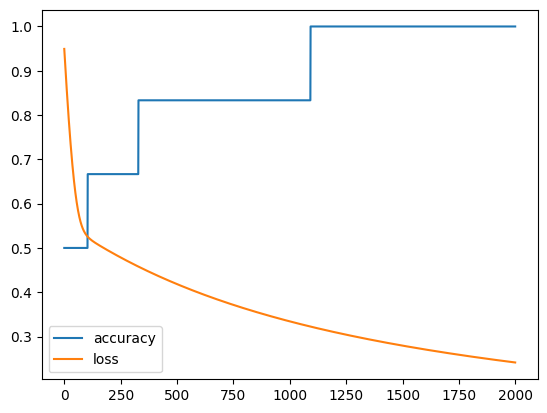

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step


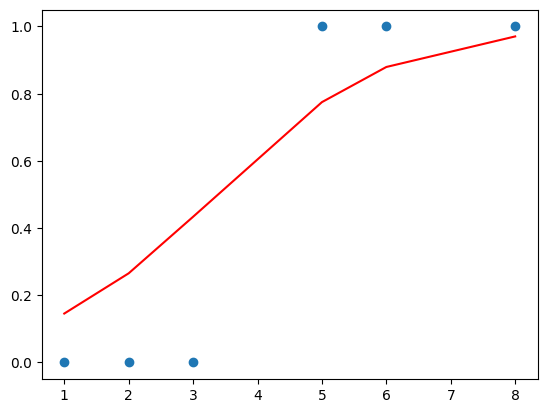

In [ ]:
#@title 일변수 로지스틱회귀 결과 보기
print('평가 : ', model.evaluate(x, y))
print('예측 : ', model.predict(np.array([3,5,7])))

pd.DataFrame(hist.history).plot()
plt.show()

plt.scatter(x, y)
plt.plot(x, model.predict(x), 'r')
plt.show()

In [ ]:
#@title 계수 a 알아오기
print(model.get_weights())

[array([[0.40897825]], dtype=float32), array([-2.3199172], dtype=float32)]


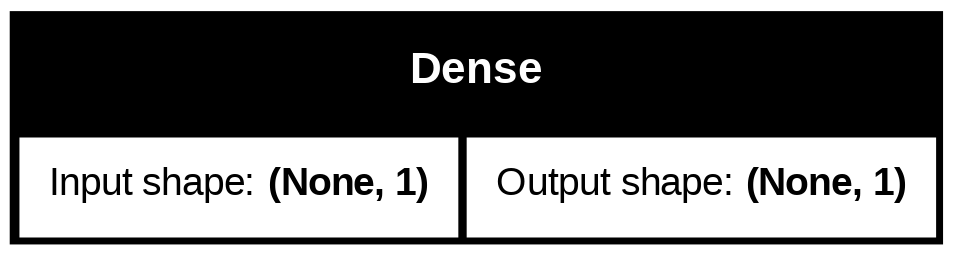

In [ ]:
#@title 모델 그리기
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model.png', show_shapes=True)

#### 이변수

In [ ]:
#@title 이변수 로지스틱 회귀
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import pandas as pd
import matplotlib.pyplot as plt

x = np.array([[0,0],[1,1],[2,3],[4,5],[6,8],[7,9]])
y = np.array([0,0,0,1,1,1])

model = Sequential()
model.add(Dense(1, input_dim=2, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='sgd', metrics=['accuracy'])

hist = model.fit(x, y, epochs=1000, verbose=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 810ms/step - accuracy: 0.8333 - loss: 0.2804
평가 :  [0.28039902448654175, 0.8333333134651184]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
예측 :  [[0.26210192]
 [0.6759629 ]
 [0.48605794]]


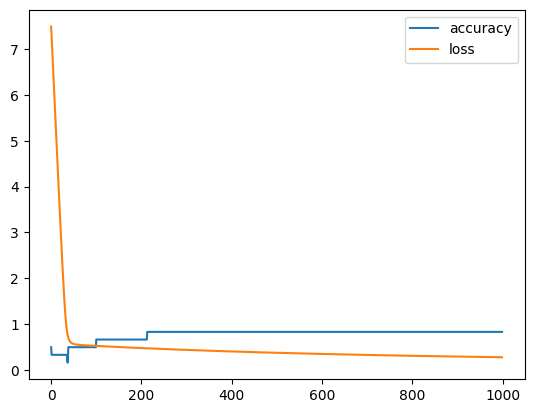

In [ ]:
#@title 이변수 로지스틱회귀 결과 보기
print('평가 : ', model.evaluate(x, y))
print('예측 : ', model.predict(np.array([[3,1], [2,4], [6,3]])))

pd.DataFrame(hist.history).plot()
plt.show()

1/1 [==============================] - 0s 54ms/step


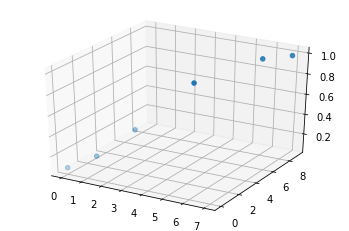

In [ ]:
# 3D 차트 사용 예
x1 = [0,1,2,4,6,7]
x2 = [0,1,3,5,8,9]
y1 = [0,0,0,1,1,1]
y2 = model.predict(x)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter3D(x1, x2, y2)
plt.show()

### 다른 코드 예제
[출처](https://medium.com/geekculture/machine-learning-logistic-regression-in-python-from-scratch-3d9e2875f27a)

[코드 다운로드](https://github.com/anarabiyev/Logistic-Regression-Python-implementation-from-scratch)

In [ ]:
#@title 로지스틱회귀 맨땅에 헤딩해 보기
# 1. importing and manipulating data

import pandas as pd
import numpy as np

df = pd.read_csv('Social_Network_Ads.csv')
print(df.head(10))

X = df[['Gender', 'Age', 'EstimatedSalary']]
y = df['Purchased']

#adding bias column
m = X.shape[0]
a = np.ones((m, 1))
X.insert(loc = 0, column = 'Ones', value = a)                      #add ones for theta_0

#change categorical data to continuous data
X.loc[X['Gender'] == 'Male', 'Gender_Male'] = 1                 #1 if male
X.loc[X['Gender'] == 'Female', 'Gender_Male'] = 0               #0 if female

del X['Gender']                                                 #delete intial gender column

#feature scaling
age_std = X['Age'].std()
age_ave = X['Age'].mean()

sala_std = X['EstimatedSalary'].std()
sala_ave = X['EstimatedSalary'].mean()

X['Age'] = (X['Age'].subtract(age_ave)).divide(age_std)
X['EstimatedSalary'] = (X['EstimatedSalary'].subtract(sala_ave)).divide(sala_std)

#create train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)     #75% train, 25% test
X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()  #convert df to np for matrix operations

#2. functions of the algorithm
#sigmoid to convert numbers between 0 and 1
def sigmoid(z):
	return (1/(1+np.exp(-z)))

#hypothesis
def h(theta, X):
	return sigmoid(np.matmul(X, theta))

#cost function
def cost_function(X, y, theta, m):
	y = y.reshape(y.shape[0], 1)
	H = h(theta, X)
	return (sum((y)*np.log(H) + (1-y)*np.log(1-H))) / (-m)

#grading descent
def gradient_descent(theta, X, y, alfa, m):
	H = h(theta, X)
	H = H.reshape((H.shape[0],))
	diff = np.subtract(H, y)
	a = np.matmul(np.transpose(X), diff).reshape((theta.shape[0],1))
	theta = theta - (alfa/m) * a
	return theta

#train function
def train(X, y, theta, alfa, m, num_iter):
	for i in range(num_iter):
		theta = gradient_descent(theta, X, y, alfa, m)
		if i % 500 == 0:
			print("Cost: ", cost_function(X, y, theta, m))
	return theta

#returns 1 or 0 with given threshold
def predict(X, theta, threshold = 0.5):
	a = h(theta, X)
	a [a >= threshold] = 1
	a [a < threshold]  = 0
	return a

#returns the accuracy
def score(y1, y2):
	#y1 is answer
	#y2 is calculated
	y1 = y1.reshape(y1.shape[0], 1)
	y2 = y2.reshape(y2.shape[0], 1)
	y1_not = (1 - y1).reshape(y1.shape[0], 1)
	y2_not = (1 - y2).reshape(y1.shape[0], 1)
	a = np.multiply(y1_not, y2_not) + np.multiply(y1, y2)   #1 means correct prediction, 0 means wrong predictions
	ones_ = np.count_nonzero(a == 1)  #count ones to get the percentage
	return (ones_ / y1.shape[0]) * 100

#3. initialization and function calls
m = X_train.shape[0]  #number of rows
n = X_train.shape[1]  #number of columns
theta = np.zeros((n, 1))
num_iter = 2000
alfa = 0.3

opt_theta = train(X_train, y_train, theta, alfa, m, num_iter)
y_ = predict(X_test, opt_theta)
print("Accuracy: ", score(y_test, y_))

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
5  15728773    Male   27            58000          0
6  15598044  Female   27            84000          0
7  15694829  Female   32           150000          1
8  15600575    Male   25            33000          0
9  15727311  Female   35            65000          0
Cost:  [0.65483195]
Cost:  [0.37434673]
Cost:  [0.3743219]
Cost:  [0.37432184]
Accuracy:  88.0


## 2장. 폐암 수술환자 생존 예측 (31쪽)

In [ ]:
#@title 데이터 다운로드
# 설치 폴더 : ./deeplearning/data/
!git clone https://github.com/taehojo/deeplearning.git

Cloning into 'deeplearning'...
remote: Enumerating objects: 903, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 903 (delta 88), reused 63 (delta 61), pack-reused 805 (from 2)
Receiving objects: 100% (903/903), 50.62 MiB | 23.92 MiB/s, done.
Resolving deltas: 100% (380/380), done.


In [ ]:
#@title 폐암 수술환자 데이터 로딩
import numpy as np
data_set = np.loadtxt("./deeplearning/data/ThoraricSurgery3.csv", delimiter=",")
data_set.shape

(470, 17)

In [ ]:
#@title 학습/결과 데이터 추출
X = data_set[:, 0:16] # 여러개 속성 : 대문자
y = data_set[:, 16]   # 단일 속성 : 소문자
X

array([[ 1.  ,  2.88,  2.16, ...,  1.  ,  0.  , 60.  ],
       [ 2.  ,  3.4 ,  1.88, ...,  1.  ,  0.  , 51.  ],
       [ 2.  ,  2.76,  2.08, ...,  1.  ,  0.  , 59.  ],
       ...,
       [ 2.  ,  3.04,  2.08, ...,  0.  ,  0.  , 52.  ],
       [ 2.  ,  1.96,  1.68, ...,  1.  ,  0.  , 79.  ],
       [ 2.  ,  4.72,  3.56, ...,  1.  ,  0.  , 51.  ]])

In [ ]:
#@title 모델 생성 및 컴파일
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(30, input_dim=16, activation='relu')) # 은닉층은 relu로...
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#@title 훈련
hist = model.fit(X, y, epochs=5, batch_size=16)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8491 - loss: 2.1818
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8449 - loss: 1.4848
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8386 - loss: 0.7508
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8699 - loss: 0.3892
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8648 - loss: 0.3927


In [ ]:
#@title 검증
model.evaluate(X, y)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8313 - loss: 0.4557


[0.42410629987716675, 0.8510638475418091]

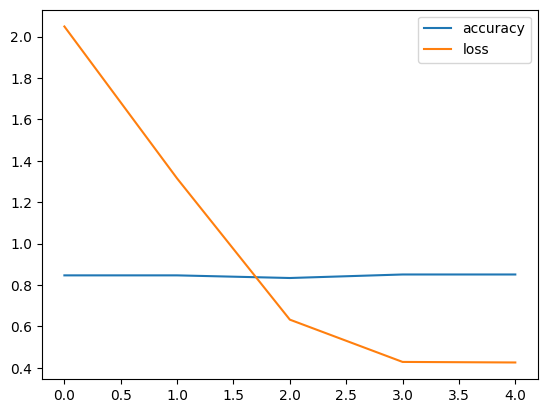

In [ ]:
#@title 차트 출력
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(hist.history).plot()
plt.show()

## 11장. 데이터 다루기 - 당뇨병 예측 (141쪽)
1. 사용할 데이터 로드 - read_csv()
1. 데이터 분석 - histogram
1. 사용할 요소(데이터) 판별 - pd.corr(), sns.heatmap()
1. 모델 생성 - 컴파일 - 훈련
1. 검증 및 결과 시각화

### 데이터 준비

In [ ]:
#@title 데이터 로딩
#import numpy as np
#!git clone https://github.com/taehojo/data.git
import pandas as pd

df = pd.read_csv('./deeplearning/data/pima-indians-diabetes3.csv')
df.head(5)

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
#@title 데이터 조사 분석
print('자료의 수 : ', df['diabetes'].value_counts())
# 당뇨병 기준 평균
df.groupby('diabetes').mean()

자료의 수 :  diabetes
0    500
1    268
Name: count, dtype: int64


,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age
diabetes,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [ ]:
#@title 데이터 분포
df.describe()

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
#@title 상관계수 살펴보기 (corr)
df.corr()

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age,diabetes
pregnant,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
plasma,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
pressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
thickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
bmi,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
pedigree,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
diabetes,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


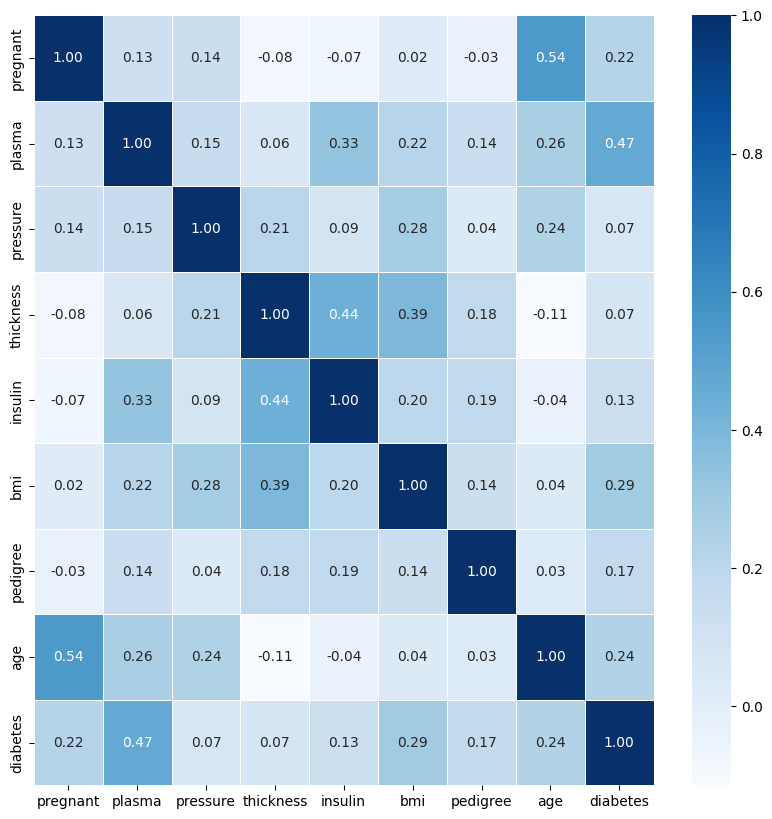

In [ ]:
#@title 상관계수 히트맵 출력
import matplotlib.pyplot as plt
import seaborn as sns

# 차트 크기 지정
plt.figure(figsize=(10,10))
# 히트맵 출력, annot : 값 출력 여부 지정
sns.heatmap(df.corr(), annot=True, fmt='.2f', linewidths=0.5, cmap='Blues')
plt.show()

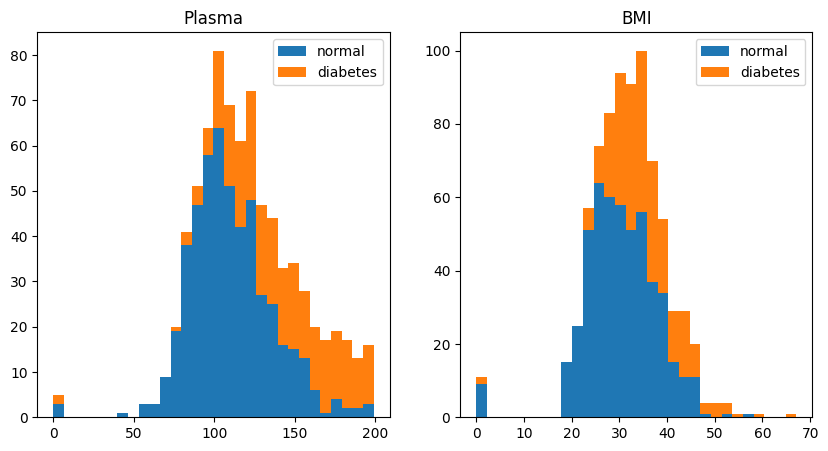

In [ ]:
#@title 사용할 데이터 히스토그램 - plasma, bmi
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Plasma')
plt.hist(x=[df.plasma[df.diabetes==0], df.plasma[df.diabetes==1]], bins=30, histtype='barstacked', label=['normal','diabetes'])
plt.legend()

plt.subplot(1,2,2)
plt.title('BMI')
plt.hist(x=[df.bmi[df.diabetes==0], df.bmi[df.diabetes==1]], bins=30, histtype='barstacked', label=['normal','diabetes'])
plt.legend()
plt.show()

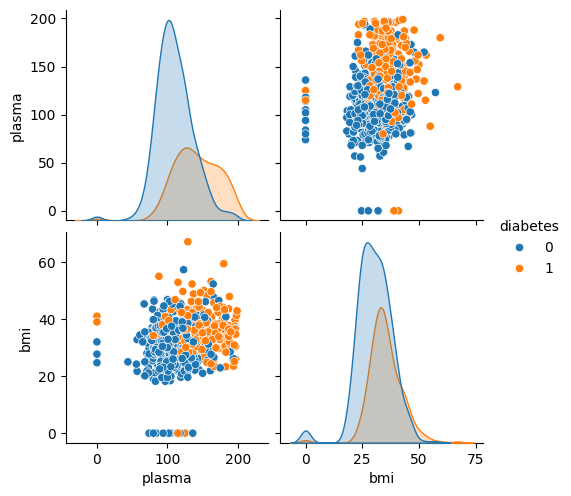

In [ ]:
#@title Seaborn 사용
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df[['plasma','bmi','diabetes']], hue='diabetes')
plt.show()

In [ ]:
#@title 데이터 추출
X = df.iloc[:, :8]
y = df.iloc[:, -1]
X

,pregnant,plasma,pressure,thickness,insulin,bmi,pedigree,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


### 모델 생성 및 훈련

In [ ]:
#@title 모델 생성, 2개의 은닉층
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(12, input_dim=8, activation='relu', name='Hidden1'))
model.add(Dense(8, activation='relu', name='Hidden2'))
model.add(Dense(1, activation='sigmoid', name='Output'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()
# 파라미터 수 : 8*12+12, 12*8+8, 8+1

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden1 (Dense)                 │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden2 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#@title 훈련
hist = model.fit(X, y, epochs=100, verbose=0)

In [ ]:
#@title 검증
model.evaluate(X, y)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6633 - loss: 0.5880  


[0.5839166045188904, 0.6744791865348816]

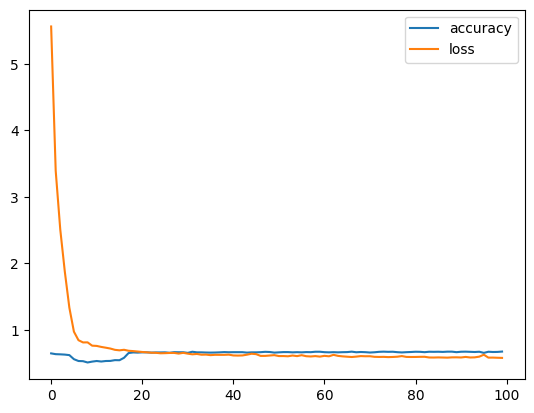

In [ ]:
import pandas as pd
pd.DataFrame(hist.history).plot()
plt.show()

### To Do
1. plasma, bmi 데이터만으로 예측해 보자.
1. titanic 데이터 셋으로 생존을 예측해 보자.
  - sns.load_dataset('titanic')
  

### Titanic 데이터 셋 연습 - 로지스틱회귀

In [ ]:
#@title titanic 데이터셋
import seaborn as sns

tt = sns.load_dataset('titanic')
tt

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
#@title 남녀별 생존 수
import pandas as pd
pd.crosstab(tt.survived, tt.sex, normalize=True)

sex,female,male
survived,,
0,0.090909,0.525253
1,0.261504,0.122334


In [ ]:
#@title 숫자로 변환
tt.replace('male', 0, inplace=True)
tt.replace('female', 1, inplace=True)
tt.replace({True:1,False:0}, inplace=True)
tt

/tmp/ipython-input-703729521.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tt.replace('female', 1, inplace=True)
/tmp/ipython-input-703729521.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tt.replace({True:1,False:0}, inplace=True)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,0,22.0,1,0,7.2500,S,Third,man,1,NaN,Southampton,no,0
1,1,1,1,38.0,1,0,71.2833,C,First,woman,0,C,Cherbourg,yes,0
2,1,3,1,26.0,0,0,7.9250,S,Third,woman,0,NaN,Southampton,yes,1
3,1,1,1,35.0,1,0,53.1000,S,First,woman,0,C,Southampton,yes,0
4,0,3,0,35.0,0,0,8.0500,S,Third,man,1,NaN,Southampton,no,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,S,Second,man,1,NaN,Southampton,no,1
887,1,1,1,19.0,0,0,30.0000,S,First,woman,0,B,Southampton,yes,1
888,0,3,1,NaN,1,2,23.4500,S,Third,woman,0,NaN,Southampton,no,0
889,1,1,0,26.0,0,0,30.0000,C,First,man,1,C,Cherbourg,yes,1


In [ ]:
#@title 데이터 살펴보기
tt.describe()

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.699118,0.523008,0.381594,32.204208,0.602694,0.602694
std,0.486592,0.836071,0.477990,14.526497,1.102743,0.806057,49.693429,0.489615,0.489615
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,20.125000,0.000000,0.000000,7.910400,0.000000,0.000000
50%,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,1.000000,1.000000
75%,1.000000,3.000000,1.000000,38.000000,1.000000,0.000000,31.000000,1.000000,1.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000


In [ ]:
tt.groupby('survived').mean(numeric_only=True)

,pclass,sex,age,sibsp,parch,fare,adult_male,alone
survived,,,,,,,,
0,2.531876,0.147541,30.626179,0.553734,0.329690,22.117887,0.817851,0.681239
1,1.950292,0.681287,28.343690,0.473684,0.464912,48.395408,0.257310,0.476608


<Axes: >

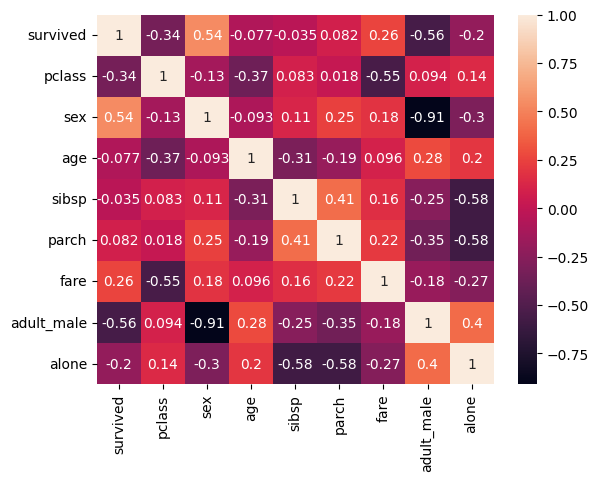

In [ ]:
sns.heatmap(tt.corr(numeric_only=True), annot=True)

In [ ]:
y = tt.survived
X = tt[['sex', 'pclass', 'adult_male']]
X

,sex,pclass,adult_male
0,0,3,1
1,1,1,0
2,1,3,0
3,1,1,0
4,0,3,1
...,...,...,...
886,0,2,1
887,1,1,0
888,1,3,0
889,0,1,1


In [ ]:
#@title 모델 생성, 2개의 은닉층
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(12, input_dim=3, activation='relu', name='Hidden1'))
model.add(Dense(8, activation='relu', name='Hidden2'))
model.add(Dense(1, activation='sigmoid', name='Output'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()
# 파라미터 수 : 12*8+12, 12*8+8, 8+1

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden1 (Dense)                 │ (None, 12)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden2 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#@title 학습하기
hist = model.fit(X, y, epochs=1000, verbose=0)

In [ ]:
model.evaluate(X, y)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7823 - loss: 0.4436


[0.42193442583084106, 0.8002244830131531]

In [ ]:
#@title 예측해 보기
model.predict(X[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step


array([[0.1181004 ],
       [0.9700897 ],
       [0.49651212],
       [0.9700897 ],
       [0.1181004 ]], dtype=float32)

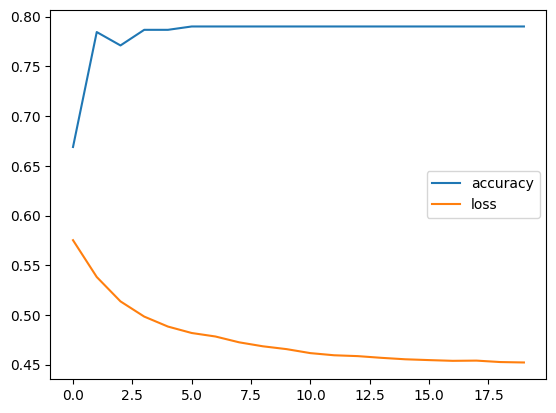

In [ ]:
import matplotlib.pyplot as plt
pd.DataFrame(hist.history)[:20].plot()
plt.show()

# 03 소프트맥스 - IRIS : 155쪽
- iris 데이터셋을 이용한 품종 예측
- sklearn의 데이터셋을 불러와서 활용한다.
- one-hot encoding : pd.get_dummies() 함수 이용

### 파라미터 설정
- Dense : 히든 레이어 - activation='relu', 출력 레이어 - activation='softmax'
- compile : loss='categorical_crossentropy', optimizer='adam'

In [ ]:
# iris 데이터셋 불러오기 - 생략
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data.columns = ['sepal_length','sepal_width','petal_length','petal_width']
data['species'] = iris.target
data['species'] = data['species'].map({0:"setosa", 1:"versicolor", 2:"virginica"})
data.to_csv('iris.csv') # 데이터를 csv 파일로 저장한다. 생략 가능
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### seaborn 데이터 로딩 & pairplot

In [ ]:
# @title seaborn iris 데이터 로딩
import seaborn as sns
#sns.get_dataset_names()
iris=sns.load_dataset('iris')
print(type(iris))
iris.head()

<class 'pandas.core.frame.DataFrame'>


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
#@title 품종별 속성 평균 구해보기
iris.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [ ]:
#@title iris 데이터 통계값 살펴보기
iris.groupby('species').describe().T

species                setosa  versicolor  virginica
sepal_length count  50.000000   50.000000  50.000000
             mean    5.006000    5.936000   6.588000
             std     0.352490    0.516171   0.635880
             min     4.300000    4.900000   4.900000
             25%     4.800000    5.600000   6.225000
             50%     5.000000    5.900000   6.500000
             75%     5.200000    6.300000   6.900000
             max     5.800000    7.000000   7.900000
sepal_width  count  50.000000   50.000000  50.000000
             mean    3.428000    2.770000   2.974000
             std     0.379064    0.313798   0.322497
             min     2.300000    2.000000   2.200000
             25%     3.200000    2.525000   2.800000
             50%     3.400000    2.800000   3.000000
             75%     3.675000    3.000000   3.175000
             max     4.400000    3.400000   3.800000
petal_length count  50.000000   50.000000  50.000000
             mean    1.462000    4.260000   5.552000
             std     0.173664    0.469911   0.551895
             min     1.000000    3.000000   4.500000
             25%     1.400000    4.000000   5.100000
             50%     1.500000    4.350000   5.550000
             75%     1.575000    4.600000   5.875000
             max     1.900000    5.100000   6.900000
petal_width  count  50.000000   50.000000  50.000000
             mean    0.246000    1.326000   2.026000
             std     0.105386    0.197753   0.274650
             min     0.100000    1.000000   1.400000
             25%     0.200000    1.200000   1.800000
             50%     0.200000    1.300000   2.000000
             75%     0.300000    1.500000   2.300000
             max     0.600000    1.800000   2.500000

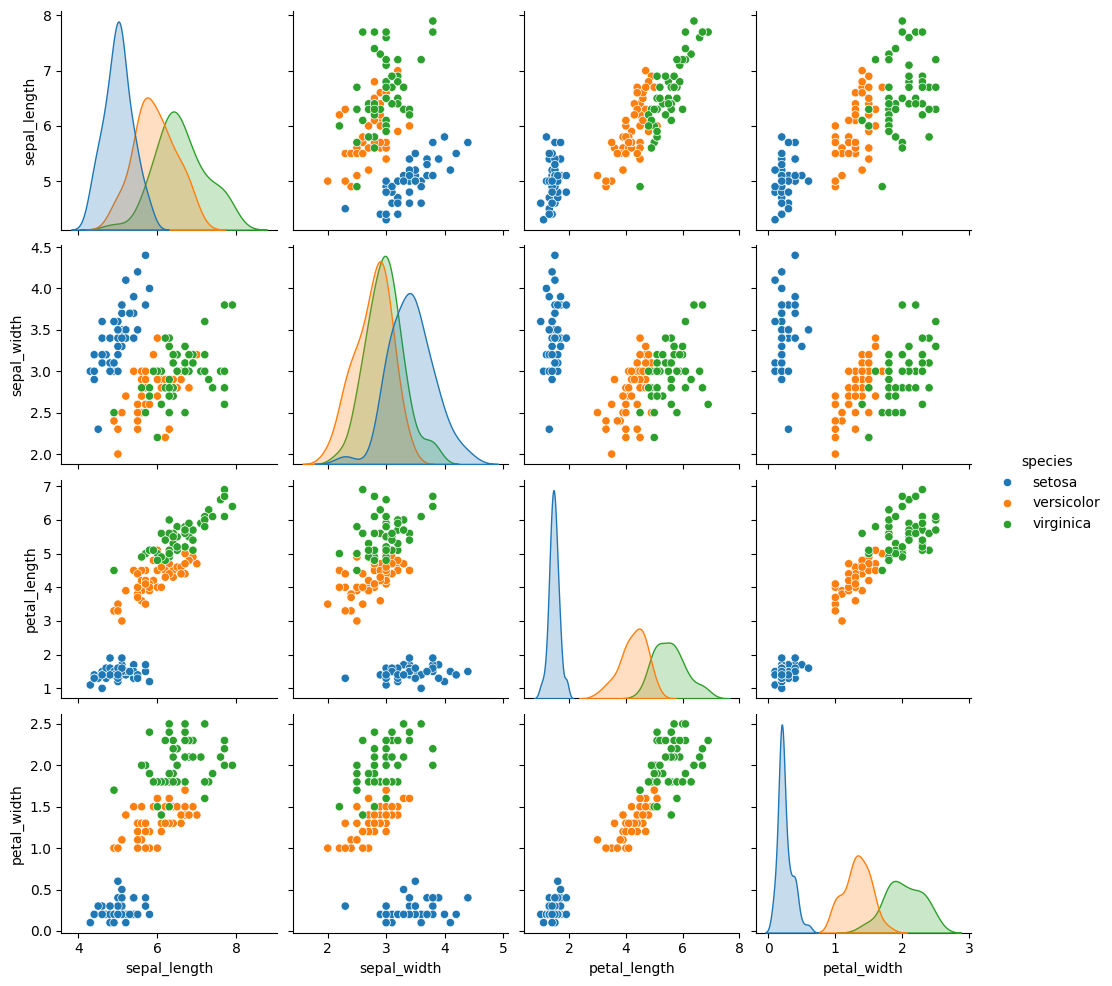

In [ ]:
# @title seaborn 상관도 그려보기
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(iris, hue='species')
plt.show()

In [ ]:
# @title 데이터 준비
import pandas as pd
# 다중분류를 위한 softmax 사용시
# 반드시 원-핫 인코딩을 해야 한다.
y = pd.get_dummies(iris.species)
x = iris.iloc[:,:4]

### 모델생성

In [ ]:
#@title 모델 생성 4 - 16 - 8 - 3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(16,input_dim=4, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

### 훈련 및 평가

In [ ]:
#@title IRIS 데이터 학습하기
hist = model.fit(x, y, epochs=1000, verbose=0)

In [ ]:
#@title acc 및 loss 보기
model.evaluate(x, y)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - acc: 0.9873 - loss: 0.0310


[0.049588583409786224, 0.9800000190734863]

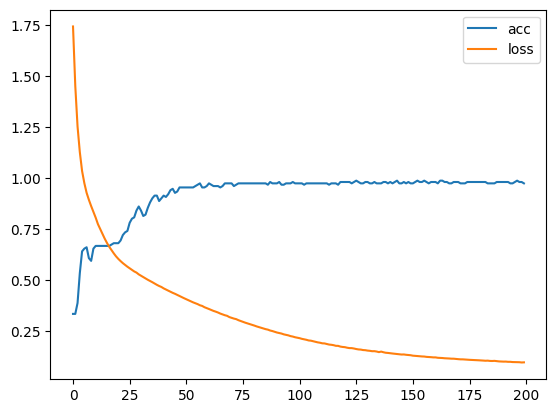

In [ ]:
#@title 학습 그래프
import matplotlib.pyplot as plt
pd.DataFrame(hist.history).iloc[:200,:].plot()
plt.show()

In [ ]:
#@title 몇 개를 예측해 본다.
# ※ np.round() : 올림하여 출력해 볼 수 있다.
pred = model.predict(x.iloc[[1,51,101],:])
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


array([[9.9971122e-01, 2.8878977e-04, 7.6510970e-10],
       [1.9820136e-06, 9.9944788e-01, 5.5012945e-04],
       [9.2651373e-12, 1.1800453e-03, 9.9881989e-01]], dtype=float32)

# 03 소프트맥스 - 펭귄

### seaborn 데이터 로딩 & pairplot

In [ ]:
# @title seaborn iris 데이터 로딩
import seaborn as sns
#sns.get_dataset_names()
pg = sns.load_dataset('penguins')
print(type(pg))
pg.head()

<class 'pandas.core.frame.DataFrame'>


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


<Axes: >

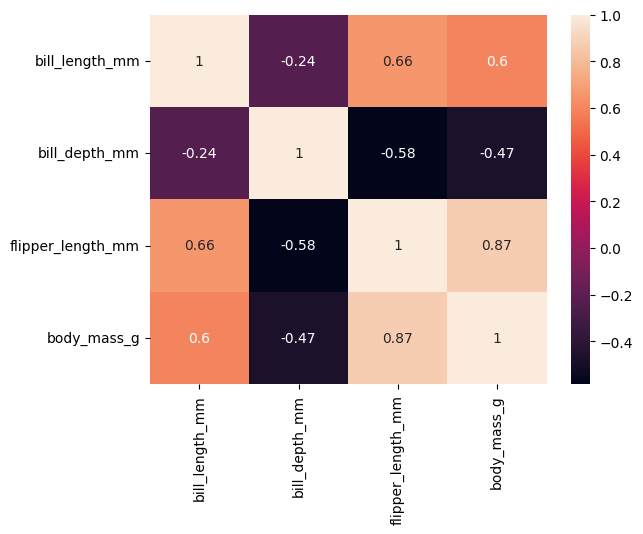

In [ ]:
sns.heatmap(pg.corr(numeric_only=True), annot=True)

In [ ]:
pg.groupby('species').mean(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.791391,18.346358,189.953642,3700.662252
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.504878,14.982114,217.186992,5076.016260


In [ ]:
#@title NULL 값 제거
p = pg[~pg['sex'].isna()]
p.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


In [ ]:
#@title 품종별 속성 평균 구해보기
p.groupby('species').mean(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.823973,18.347260,190.102740,3706.164384
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.568067,14.996639,217.235294,5092.436975


In [ ]:
#@title iris 데이터 통계값 살펴보기
p.groupby('species').describe().T

species                       Adelie    Chinstrap       Gentoo
bill_length_mm    count   146.000000    68.000000   119.000000
                  mean     38.823973    48.833824    47.568067
                  std       2.662597     3.339256     3.106116
                  min      32.100000    40.900000    40.900000
                  25%      36.725000    46.350000    45.350000
                  50%      38.850000    49.550000    47.400000
                  75%      40.775000    51.075000    49.600000
                  max      46.000000    58.000000    59.600000
bill_depth_mm     count   146.000000    68.000000   119.000000
                  mean     18.347260    18.420588    14.996639
                  std       1.219338     1.135395     0.985998
                  min      15.500000    16.400000    13.100000
                  25%      17.500000    17.500000    14.200000
                  50%      18.400000    18.450000    15.000000
                  75%      19.000000    19.400000    15.750000
                  max      21.500000    20.800000    17.300000
flipper_length_mm count   146.000000    68.000000   119.000000
                  mean    190.102740   195.823529   217.235294
                  std       6.521825     7.131894     6.585431
                  min     172.000000   178.000000   203.000000
                  25%     186.000000   191.000000   212.000000
                  50%     190.000000   196.000000   216.000000
                  75%     195.000000   201.000000   221.500000
                  max     210.000000   212.000000   231.000000
body_mass_g       count   146.000000    68.000000   119.000000
                  mean   3706.164384  3733.088235  5092.436975
                  std     458.620135   384.335081   501.476154
                  min    2850.000000  2700.000000  3950.000000
                  25%    3362.500000  3487.500000  4700.000000
                  50%    3700.000000  3700.000000  5050.000000
                  75%    4000.000000  3950.000000  5500.000000
                  max    4775.000000  4800.000000  6300.000000

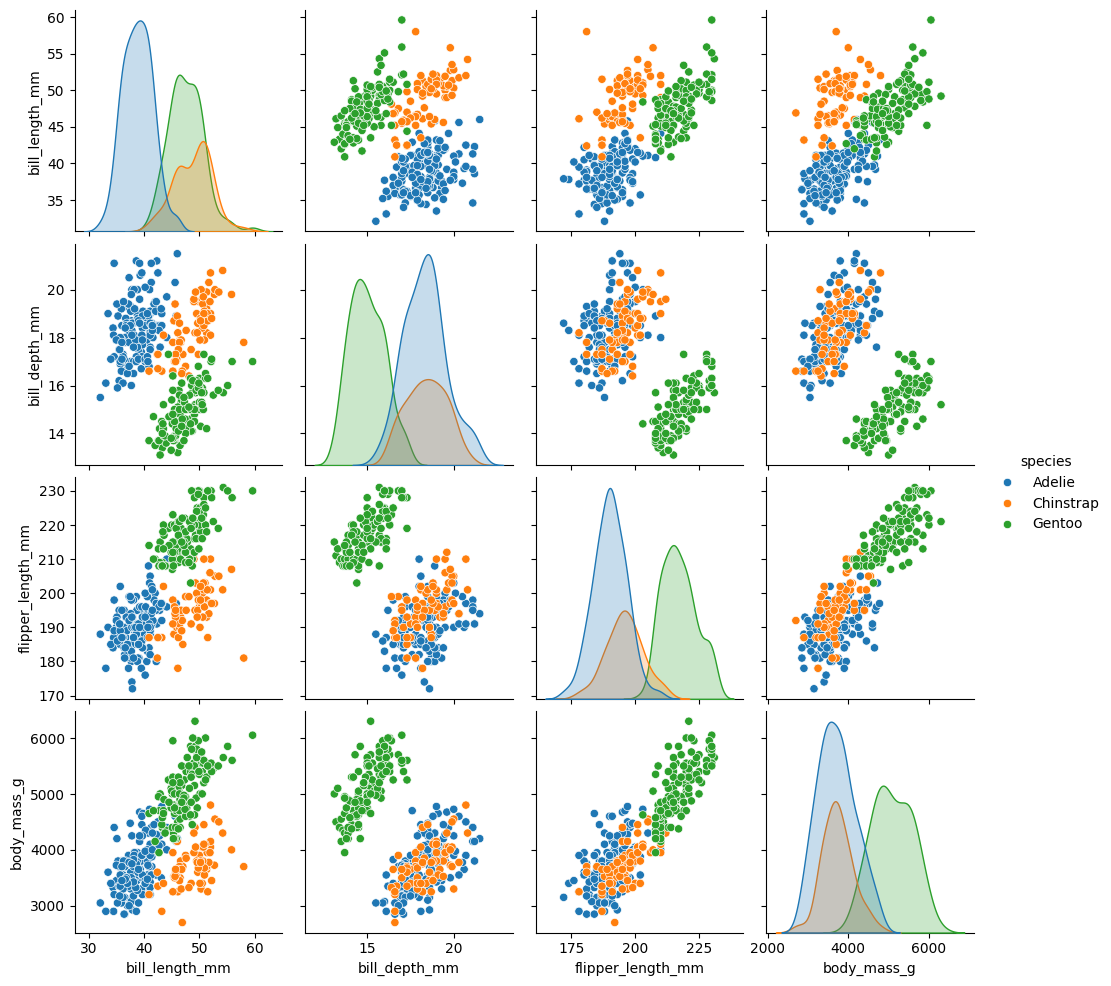

In [ ]:
# @title seaborn 상관도 그려보기
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(p, hue='species')
plt.show()

In [ ]:
# @title 데이터 준비
import pandas as pd
# 다중분류를 위한 softmax 사용시
# 반드시 원-핫 인코딩을 해야 한다.
y = pd.get_dummies(p.species)
x = p.iloc[:,2:5]

### 모델생성

In [ ]:
#@title 모델 생성 4 - 16 - 8 - 3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(16,input_dim=3, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227 (908.00 B)

 Trainable params: 227 (908.00 B)

 Non-trainable params: 0 (0.00 B)

### 훈련 및 평가

In [ ]:
#@title 펭귄 데이터 학습하기
hist = model.fit(x, y, epochs=1000, verbose=0)

In [ ]:
#@title acc 및 loss 보기
model.evaluate(x, y)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7279 - loss: 0.9630 


[1.0536437034606934, 0.43843844532966614]

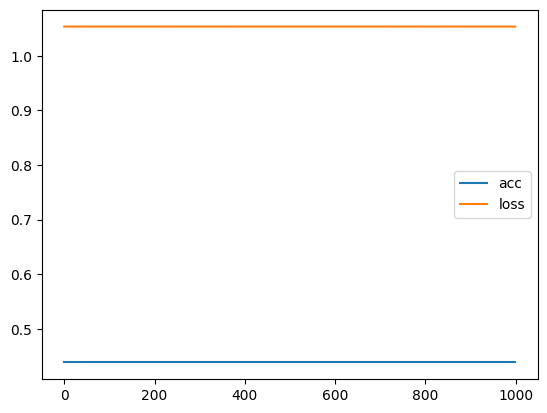

In [ ]:
#@title 학습 그래프
import matplotlib.pyplot as plt
pd.DataFrame(hist.history).plot()
plt.show()

In [ ]:
#@title 몇 개를 예측해 본다.
# ※ np.round() : 올림하여 출력해 볼 수 있다.
pred = model.predict(x.iloc[[10,100,200],:])
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


array([[0.43748972, 0.20482422, 0.3576861 ],
       [0.43748972, 0.20482422, 0.3576861 ],
       [0.43748972, 0.20482422, 0.3576861 ]], dtype=float32)

# 13장 모델 성능 검증하기 - 165쪽
- 광물 데이터 : 광석 vs. 일반 광물, 60개 데이터
- 키워드 : 과적합, 학습셋, 테스트셋, 모델 저장 및 불러오기, k겹 교차검증
- 학습셋과 테스트셋 나누기 : sklearn.model_selection.train_test_split(x, y, test_size=0.x, shuffle=True)
- 모델 저장 : model.save(filename.hdf5)
- 모델 불러오기 : tensorflow.keras.models.load_model(filepath)
- k겹 교차검증 : sklearn.model_selection.KFold(N, shuffle=True), 반복 실행

## 학습 실행해 보기

In [ ]:
#@title 광물 데이터 준비
import pandas as pd
!git clone https://github.com/taehojo/data.git
df = pd.read_csv('./data/sonar3.csv', header=None)
df.head()
#df[60].value_counts()

Cloning into 'data'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 36 (delta 9), reused 26 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 483.12 KiB | 2.49 MiB/s, done.
Resolving deltas: 100% (9/9), done.


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,0
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,0
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,0
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,0
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,0


In [ ]:
df[60].value_counts()

,count
60,
1,111
0,97


In [ ]:
#@title 학습 데이터 준비
x = df.iloc[:, :60]
y = df.iloc[:, 60]

In [ ]:
#@title 조기중지, 중간점검, 콜백 함수 생성 (14장 내용)
from tensorflow.keras.callbacks import EarlyStopping # 중간에 학습 중지
from tensorflow.keras.callbacks import ModelCheckpoint # 모델 저장
from tensorflow.keras.callbacks import LambdaCallback

esc = EarlyStopping(monitor='val_loss', patience=10)
mcc = ModelCheckpoint(filepath='./data/ch13-model.keras', monitor='val_loss', verbose=0, save_best_only=True)

lc = LambdaCallback(on_train_begin=lambda l: print('training begins'),
                    on_epoch_end=lambda e, l: print(f'{e:>4d} : {l["acc"]:>.4f}', end='\n' if (e+1) % 6==0 else ' '),
                    on_train_end=lambda l:print('\ntraining ends', l))


In [ ]:
#@title 광물 구분을 위한 모델 생성 및 컴파일
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(24, input_dim=60, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 24)             │         1,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,725 (6.74 KB)

 Trainable params: 1,725 (6.74 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#@title 훈련
hist = model.fit(x, y, epochs=500, verbose=0, callbacks=[esc,mcc,lc])

training begins


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: acc,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


   0 : 0.4615    1 : 0.5962    2 : 0.6250    3 : 0.6635    4 : 0.6731    5 : 0.6635
   6 : 0.6779    7 : 0.6875    8 : 0.6779    9 : 0.6971   10 : 0.7067   11 : 0.7212
  12 : 0.7356   13 : 0.7356   14 : 0.7404   15 : 0.7500   16 : 0.7500   17 : 0.7692
  18 : 0.7644   19 : 0.7788   20 : 0.8029   21 : 0.7788   22 : 0.8029   23 : 0.8029
  24 : 0.8125   25 : 0.8221   26 : 0.8221   27 : 0.8317   28 : 0.8317   29 : 0.8317
  30 : 0.8413   31 : 0.8269   32 : 0.8365   33 : 0.8462   34 : 0.8510   35 : 0.8317
  36 : 0.8413   37 : 0.8510   38 : 0.8510   39 : 0.8462   40 : 0.8510   41 : 0.8606
  42 : 0.8510   43 : 0.8510   44 : 0.8558   45 : 0.8606   46 : 0.8606   47 : 0.8510
  48 : 0.8846   49 : 0.8558   50 : 0.8702   51 : 0.8798   52 : 0.8702   53 : 0.8846
  54 : 0.8798   55 : 0.8750   56 : 0.8750   57 : 0.8846   58 : 0.8942   59 : 0.8942
  60 : 0.8942   61 : 0.8990   62 : 0.8846   63 : 0.8942   64 : 0.8846   65 : 0.8990
  66 : 0.8942   67 : 0.9038   68 : 0.8846   69 : 0.9183   70 : 0.8990   71 :

In [ ]:
#@title 검증

model.evaluate(x, y)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - acc: 1.0000 - loss: 0.0037


[0.0031176721677184105, 1.0]

<Axes: >

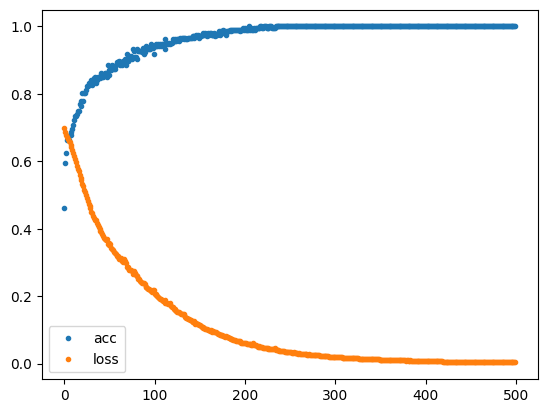

In [ ]:
import pandas as pd
pd.DataFrame(hist.history).plot(style='.')

## 데이터 쪼개기
- sklearn.modelselection.train_test_split()
- pandas sample(), drop()

### sklearn train_test_split

In [ ]:
#@title 사이킷런을 활용한 데이터셋 분리(학습/테스트)
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, shuffle=True)
x_train.index, x_test.index

(Index([186,  86,  91,   6,  61, 197, 100, 133,  89, 125,
        ...
        126, 149,  13, 123,  69, 207, 114, 129, 136, 182],
       dtype='int64', length=145),
 Index([195, 168,  71,  38,  30, 174, 118,  54, 193, 172, 185,   7,  67,  42,
          0,  97, 199, 103, 131,  33,  34,  96, 163,  37,  19,  22,  72,  84,
        151, 201,  45,  46, 166, 108, 191, 158,  85, 107, 162,  25, 202,  24,
        177, 113, 203,  18,  12,  17,  43,  21,  98, 150,  57, 206,  75, 152,
        102,  60,   2, 141, 179, 105, 153],
       dtype='int64'))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(24, input_dim=60, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
hist = model.fit(x_train, y_train, epochs=500, verbose=0, callbacks=[mcc, esc, lc])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


training begins


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: acc,loss
  current = self.get_monitor_value(logs)


   0 : 0.4966    1 : 0.5586    2 : 0.6207    3 : 0.5862    4 : 0.5931    5 : 0.5931
   6 : 0.6069    7 : 0.6207    8 : 0.6207    9 : 0.6759   10 : 0.6897   11 : 0.7034
  12 : 0.7034   13 : 0.7172   14 : 0.6897   15 : 0.7034   16 : 0.7103   17 : 0.7448
  18 : 0.7655   19 : 0.7448   20 : 0.7379   21 : 0.7379   22 : 0.7586   23 : 0.8000
  24 : 0.8138   25 : 0.8000   26 : 0.8138   27 : 0.8069   28 : 0.8207   29 : 0.8345
  30 : 0.8414   31 : 0.8207   32 : 0.8414   33 : 0.8621   34 : 0.8552   35 : 0.8621
  36 : 0.8621   37 : 0.8690   38 : 0.8690   39 : 0.8759   40 : 0.8207   41 : 0.8621
  42 : 0.8828   43 : 0.8690   44 : 0.8828   45 : 0.8345   46 : 0.8552   47 : 0.9034
  48 : 0.8828   49 : 0.8690   50 : 0.8690   51 : 0.8966   52 : 0.8828   53 : 0.8828
  54 : 0.8483   55 : 0.9103   56 : 0.8828   57 : 0.8759   58 : 0.8690   59 : 0.9034
  60 : 0.9034   61 : 0.9172   62 : 0.9241   63 : 0.9241   64 : 0.9241   65 : 0.9241
  66 : 0.9172   67 : 0.9310   68 : 0.9241   69 : 0.9172   70 : 0.9241   71 :

In [ ]:
model.evaluate(x_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 446ms/step - acc: 0.8003 - loss: 0.9341


[0.8143534064292908, 0.8253968358039856]

### pandas sample(), drop()

In [ ]:
#@title pandas를 이용해 데이터 쪼개기
import pandas as pd
train_set = df.sample(frac=.7) # 학습 데이터 추출
test_set = df.drop(train_set.index) # 테스트 데이터만들기

x_train = train_set.iloc[:, :60]
y_train = train_set.iloc[:, 60]

x_test = test_set.iloc[:, :60]
y_test = test_set.iloc[:, 60]

x_train.index, x_test.index

(Index([158, 189, 195,  46, 128, 206,  50, 185, 159,  66,
        ...
         86,  58,  82, 139, 150, 164,  43, 118,  92,  12],
       dtype='int64', length=146),
 Index([  0,   6,   9,  11,  13,  22,  23,  24,  31,  34,  38,  44,  45,  49,
         51,  52,  53,  64,  67,  69,  70,  71,  72,  74,  79,  80,  85,  88,
         89,  90,  96, 103, 107, 108, 117, 133, 136, 140, 142, 143, 145, 148,
        149, 154, 155, 156, 165, 166, 167, 169, 172, 175, 176, 178, 182, 184,
        186, 190, 191, 192, 193, 194],
       dtype='int64'))

In [ ]:
model.evaluate(test_set.iloc[:, :60], test_set.iloc[:, 60])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - acc: 0.9365 - loss: 0.1680


[0.15215793251991272, 0.9516128897666931]

## 모델의 저장과 재사용

In [ ]:
#@title 모델 저장
model.save('./data/model/my_model.keras')

In [ ]:
#@title 모델 불러오기
from tensorflow.keras.models import load_model
new_model = load_model('./data/model/my_model.keras')

In [ ]:
new_model.evaluate(test_set.iloc[:,:60], test_set.iloc[:,60])

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 305ms/step - acc: 0.9577 - loss: 0.0485


[0.04053398221731186, 0.9677419066429138]

## k겹 교차 검증
- sklearn KFold


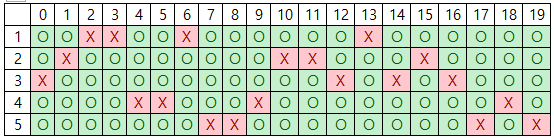

In [ ]:
def printit(tr) :
  for i in range(20) :
      if i in tr : print('O ', end='')
      else : print('X ', end='')

In [ ]:
#@title k겹 교차검증
from sklearn.model_selection import KFold
kf = KFold(5, shuffle=True)

X = list(range(20))
for tr, ts in kf.split(X) :
    print('\ntrain set : ', tr, len(tr), 'test set : ', ts, len(ts))
    printit(tr)


train set :  [ 0  2  3  4  5  6  7  8  9 10 11 14 15 16 17 18] 16 test set :  [ 1 12 13 19] 4
O X O O O O O O O O O O X X O O O O O X 
train set :  [ 1  2  3  4  5  6  7  8  9 10 11 12 13 15 16 19] 16 test set :  [ 0 14 17 18] 4
X O O O O O O O O O O O O O X O O X X O 
train set :  [ 0  1  3  6  7  9 10 11 12 13 14 15 16 17 18 19] 16 test set :  [2 4 5 8] 4
O O X O X X O O X O O O O O O O O O O O 
train set :  [ 0  1  2  4  5  6  7  8 11 12 13 14 15 17 18 19] 16 test set :  [ 3  9 10 16] 4
O O O X O O O O O X X O O O O O X O O O 
train set :  [ 0  1  2  3  4  5  8  9 10 12 13 14 16 17 18 19] 16 test set :  [ 6  7 11 15] 4
O O O O O O X X O O O X O O O X O O O O 

## 학습 실행해 보기

In [ ]:
# 데이터 준비
import pandas as pd
!git clone https://github.com/taehojo/data.git
df = pd.read_csv('./data/sonar3.csv', header=None)
df.head()
#df[60].value_counts()

fatal: destination path 'data' already exists and is not an empty directory.


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,0
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,0
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,0
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,0
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,0


In [ ]:
df[60].value_counts()

,count
60,
1,111
0,97


In [ ]:
# 데이터 준비
x = df.iloc[:, :60]
y = df.iloc[:, 60]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(24, input_dim=60, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
hist = model.fit(x, y, epochs=200, validation_split=0.2, verbose=0)

model.evaluate(x, y)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.9201 - loss: 0.2216


[0.40348517894744873, 0.870192289352417]

<Axes: >

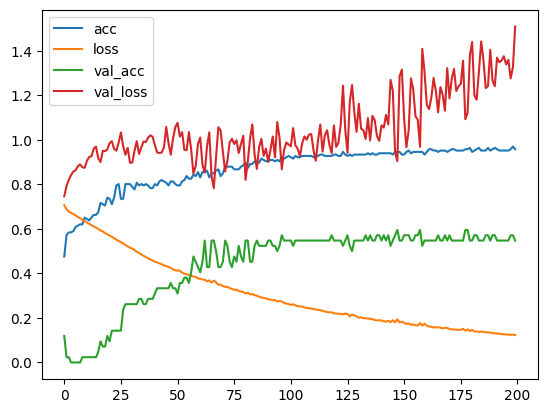

In [ ]:
import pandas as pd
pd.DataFrame(hist.history).plot()

## 모델의 저장과 재사용

In [ ]:
# 모델 저장
model.save('./data/model/my_model.keras')

In [ ]:
test_set.to_csv('test_set.csv')

In [ ]:
# 모델 불러오기
from tensorflow.keras.models import load_model
new_model = load_model('./data/model/my_model.keras')

In [ ]:
new_model.evaluate(test_set.iloc[:,:60], test_set.iloc[:,60])

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - acc: 0.9036 - loss: 0.2825


[0.3805890381336212, 0.8709677457809448]

# 14장 모델 성능 향상시키기 - 183쪽
- wine 데이터셋
- 검증셋 지정 : model.fit(..., validation_split=0.x)

[케라스 콜백 종류](https://keras.io/ko/callbacks/)
- 저장 : tensorflow.keras.callbacks.ModelCheckpoont(filepath, monitor='val_loss', verbose, save_best_only=True)
- 자동중단 : tensorflow.keras.callbacks.EarlyStopping(monitor='val_loss', patience=N)
- 사용자정의 콜백 : tensorflow.keras.callbacks.LambdaCallback(on_epoch_begin|end, on_batch_begin|end, on_train_begin|end)
  - parameter : epoch, batch : epoch, logs, train : logs


## 데이터 준비

In [ ]:
#@title 데이터 로딩
import pandas as pd
!git clone https://github.com/taehojo/data.git
df = pd.read_csv('./data/wine.csv', header=None)

df.info()

fatal: destination path 'data' already exists and is not an empty directory.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       6497 non-null   float64
 1   1       6497 non-null   float64
 2   2       6497 non-null   float64
 3   3       6497 non-null   float64
 4   4       6497 non-null   float64
 5   5       6497 non-null   float64
 6   6       6497 non-null   float64
 7   7       6497 non-null   float64
 8   8       6497 non-null   float64
 9   9       6497 non-null   float64
 10  10      6497 non-null   float64
 11  11      6497 non-null   int64  
 12  12      6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [ ]:
#@title 데이터 준비
x = df.iloc[:, :12]
y = df.iloc[:, 12] # 0 : 화이트와인, 1 : 레드와인

# 학습셋과 테스트셋 분리
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True)
x_train, y_train

(        0     1     2     3      4     5      6        7     8     9     10  \
 5034   6.5  0.24  0.28   1.1  0.034  26.0   83.0  0.98928  3.25  0.33  12.3   
 4974   7.8  0.22  0.26   9.0  0.047  38.0  132.0  0.99700  3.25  0.53  10.2   
 5999   7.4  0.27  0.26  11.8  0.053  55.0  173.0  0.99699  3.11  0.60   9.8   
 2723   9.6  0.23  0.40   1.5  0.044  19.0  135.0  0.99370  2.96  0.49  10.9   
 696    7.0  0.65  0.02   2.1  0.066   8.0   25.0  0.99720  3.47  0.67   9.5   
 ...    ...   ...   ...   ...    ...   ...    ...      ...   ...   ...   ...   
 4411   6.7  0.16  0.34   1.6  0.026  27.0  109.0  0.99340  3.34  0.58  10.1   
 817   10.8  0.29  0.42   1.6  0.084  19.0   27.0  0.99545  3.28  0.73  11.9   
 5846   6.6  0.36  0.47   1.4  0.145  26.0  124.0  0.99274  3.09  0.56  10.1   
 4797   6.4  0.22  0.38   9.1  0.044  35.0  127.0  0.99326  2.97  0.30  11.0   
 5189   6.6  0.19  0.35   1.5  0.037  37.0  107.0  0.99006  3.18  0.68  12.0   
 
       11  
 5034   6  
 4974   6  
 5

## 모델 생성 및 훈련
- fit 함수에 validation_split=0.2 파라미터 추가

In [ ]:
#@title 로지스틱회귀 모델 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(30, input_dim=12, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 30)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 12)             │           372 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 875 (3.42 KB)

 Trainable params: 875 (3.42 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#@title 콜백 작성 및 모델 훈련
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 조기종료(EarlyStopping) 콜백
esc = EarlyStopping(monitor='val_loss', patience=10)
# 모델 저장 콜백
mc = ModelCheckpoint(filepath='./data/wine_bestmodel.keras', monitor='val_loss', verbose=0, save_best_only=True)

hist = model.fit(x_train, y_train, epochs=500, validation_split=0.2, verbose=1, callbacks=[esc, mc])

Epoch 1/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - acc: 0.9206 - loss: 0.2489 - val_acc: 0.9385 - val_loss: 0.1826
Epoch 2/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9292 - loss: 0.2069 - val_acc: 0.9442 - val_loss: 0.1753
Epoch 3/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9251 - loss: 0.2133 - val_acc: 0.9385 - val_loss: 0.1650
Epoch 4/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9394 - loss: 0.1681 - val_acc: 0.9413 - val_loss: 0.1548
Epoch 5/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9341 - loss: 0.1880 - val_acc: 0.9519 - val_loss: 0.1256
Epoch 6/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9454 - loss: 0.1568 - val_acc: 0.9587 - val_loss: 0.1111
Epoch 7/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9507 - loss: 0.1303 - val_acc: 0.9596 - val_loss: 0.1061
Epoch 8/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.9570 - loss: 0.1218 - val_acc: 0.9625 - val_loss: 0.0988
Epoch 9/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms

In [ ]:
#@title 테스트 셋으로 학습 결과 평가
model.evaluate(x_test, y_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9763 - loss: 0.0571


[0.08746976405382156, 0.9746153950691223]

<Axes: >

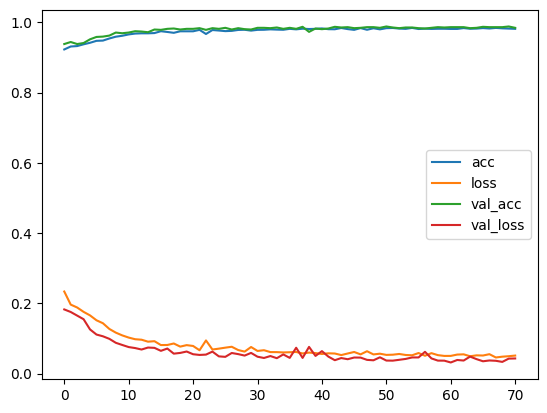

In [ ]:
#@title 학습결과 차트 확인
import pandas as pd
pd.DataFrame(hist.history).plot()

<Axes: >

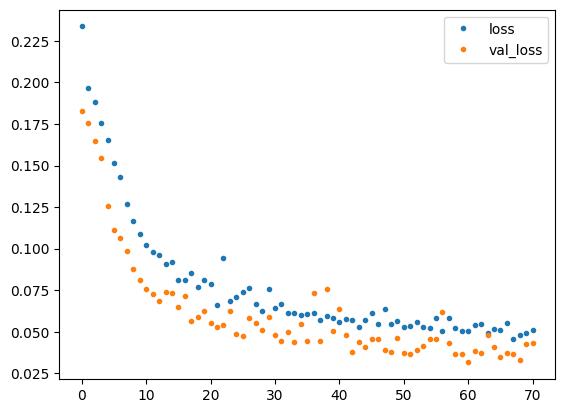

In [ ]:
import pandas as pd
pd.DataFrame(hist.history)[['loss','val_loss']].plot(style='.')

In [ ]:
#@title 예측
model.predict(x_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


array([[0.00762054],
       [0.03930645],
       [0.0055981 ],
       ...,
       [0.00585555],
       [0.03454918],
       [0.00352637]], dtype=float32)

# 15장 실제 데이터로 만들어 보는 모델
- 집값 예측
- 데이터 전처리
  - 카테고리 변수 수치화 : get_dummies()
  - 결측치 처리 : fillna(df.mean())
  - 상관계수 정렬 : corr(), sort_values()
  - 상관관계 시각화 : seaborn.pairplot()
  - 학습변수 선정
- 선형회귀 모델 생성 및 학습

## 데이터셋 준비


In [ ]:
#@title 데이터 준비
import pandas as pd
!git clone https://github.com/taehojo/data.git
df = pd.read_csv('./data/house_train.csv')

df.head()
# 모든 데이터를 볼 수 없으므로 csv 파일을 내려받아 엑셀로 살펴 본다.

Cloning into 'data'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 36 (delta 9), reused 26 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 483.12 KiB | 2.38 MiB/s, done.
Resolving deltas: 100% (9/9), done.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
#@title 데이터 살펴보기
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
#@title 결측치 확인
# 함수를 단계별로 하나씩 추가하여 실행해 본다.
# ※ isnull() == True 라면 합계를 구할 때 1로 계산된다.
df.isnull().sum().sort_values(ascending=False).head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [ ]:
#@title 원-핫 인코딩, 결측치 처리
data = pd.get_dummies(df)
# 누락된 데이터는 평균값으로 채운다.
data = data.fillna(data.mean()) # dropna()
data.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,True,False,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,True,False,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,True,False,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,True,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,True,False,False,False,False,True,False


In [ ]:
#@title 상관계수 높은 순으로 상위 10개를 출력해 본다.
# 요인분석을 사용하여 관련성이 높은 속성을 추출할 수 있다.
data_corr = data.corr()
data_corr_sort = data_corr.sort_values('SalePrice', ascending=False)
data_corr_sort['SalePrice'].head(10)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
BsmtQual_Ex,0.553105
TotRmsAbvGrd,0.533723


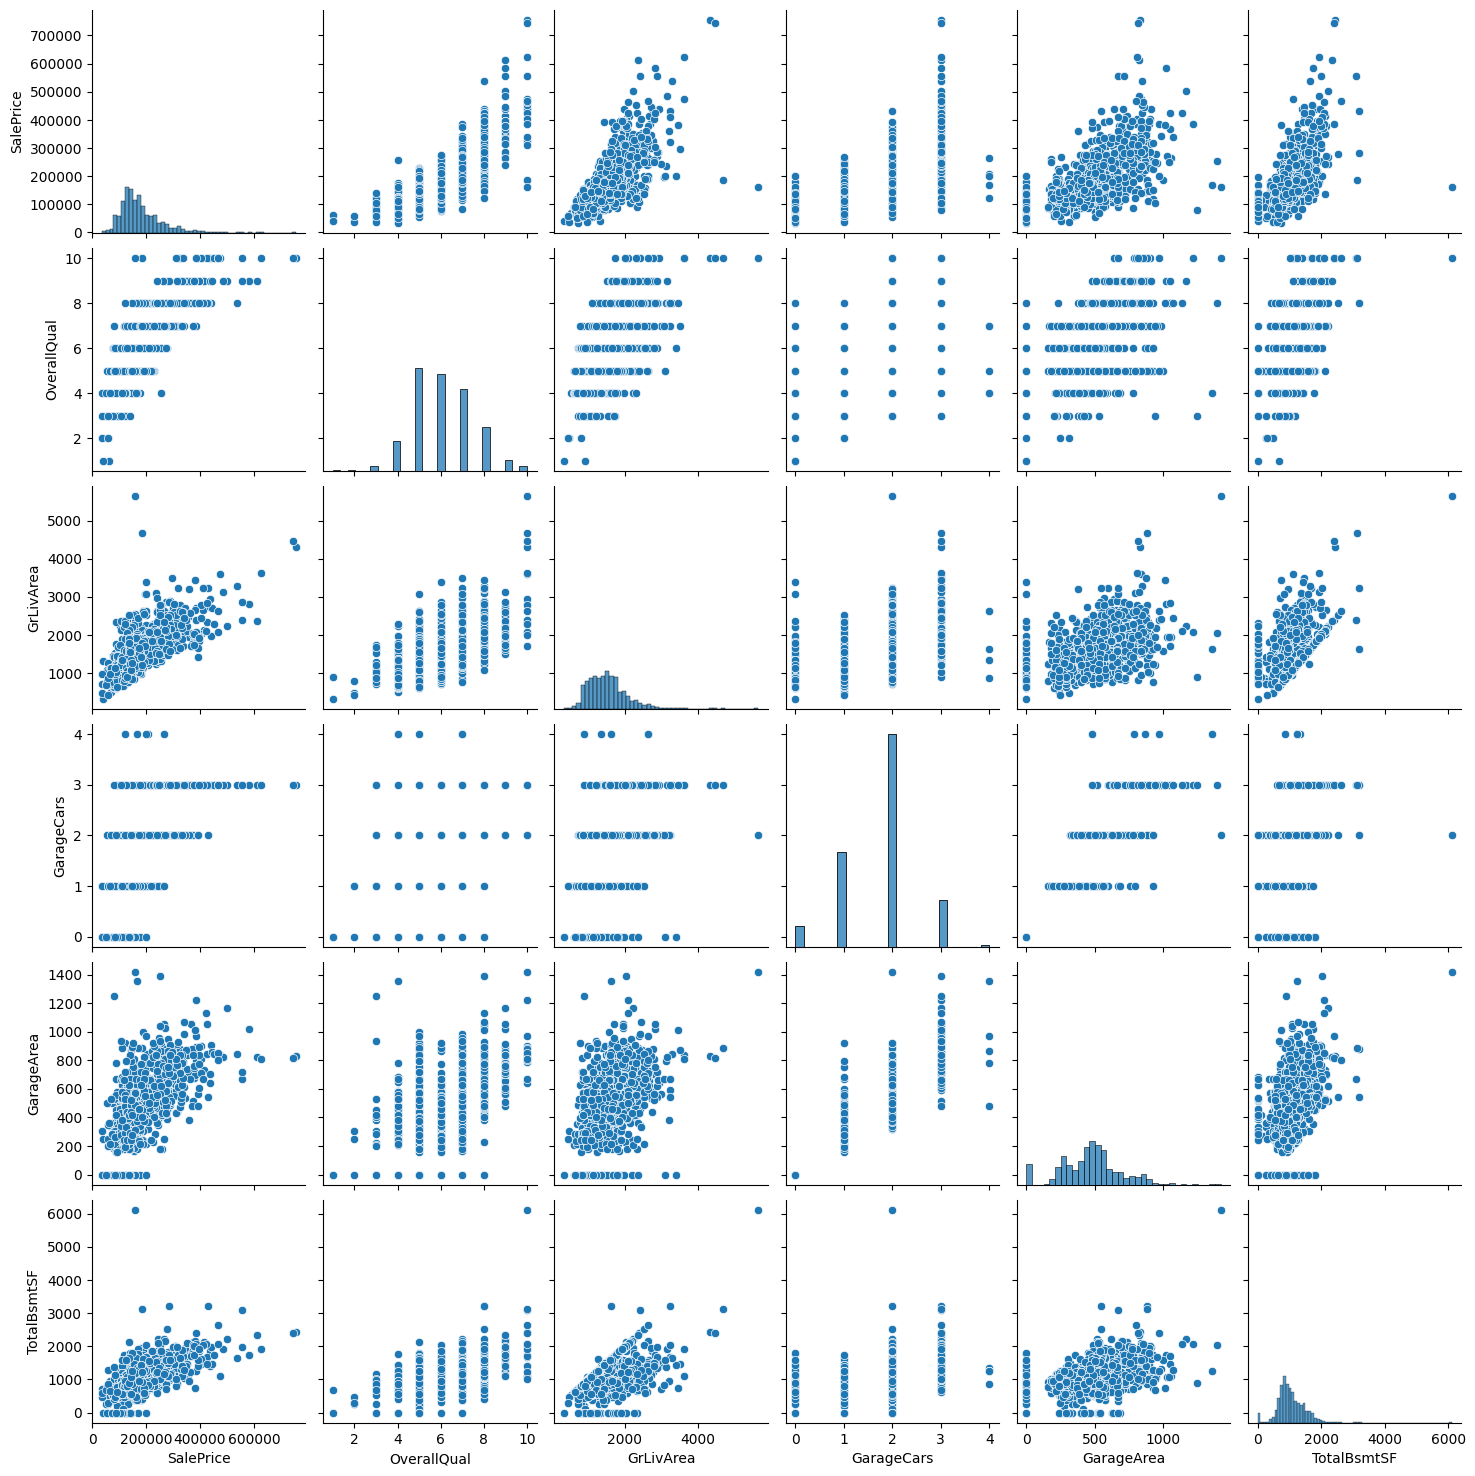

In [ ]:
#@title 상관도 차트 출력
import seaborn as sns
sns.pairplot(data[['SalePrice','OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF']])

In [ ]:
x_test /= 10000
y_test /= 10000

In [ ]:
#@title 훈련 데이터 준비
# 스크래치 셀에서 데이터를 살펴 본다.
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(
    data[['OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF']],
    data['SalePrice'].values, test_size=0.2)

## 모델 생성 및 훈련

In [ ]:
#@title 모델 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(10, input_dim=x_train.shape[1], activation='relu')) # 입력 5개
model.add(Dense(30, activation='relu'))
model.add(Dense(40, activation='relu'))
model.add(Dense(1, activation='linear')) # 선형회귀
model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 40)             │         1,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,671 (6.53 KB)

 Trainable params: 1,671 (6.53 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#@title 콜백 작성 및 모델 훈련
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, LambdaCallback

# 조기종료(EarlyStopping) 콜백
esc = EarlyStopping(monitor='val_loss', patience=10)
# 모델 저장 콜백
mc = ModelCheckpoint(filepath='./data/model/ch15-house.keras', monitor='val_loss', verbose=0, save_best_only=True)

hist = model.fit(x_train, y_train, epochs=500, validation_split=0.2, verbose=1, callbacks=[esc, mc])

Epoch 1/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 38313705472.0000 - val_loss: 40004620288.0000
Epoch 2/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 40609738752.0000 - val_loss: 39256952832.0000
Epoch 3/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 35686117376.0000 - val_loss: 36982218752.0000
Epoch 4/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 33558222848.0000 - val_loss: 31430191104.0000
Epoch 5/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 28931889152.0000 - val_loss: 21369640960.0000
Epoch 6/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 16932294656.0000 - val_loss: 8972486656.0000
Epoch 7/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6179617792.0000 - val_loss: 2622811648.0000
Epoch 8/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2555290368.0000 - val_loss: 2178649856.0000
Epoch 9/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2967468032.0000 - val_loss: 2182376704.0000
Epoch 10/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2

<Axes: >

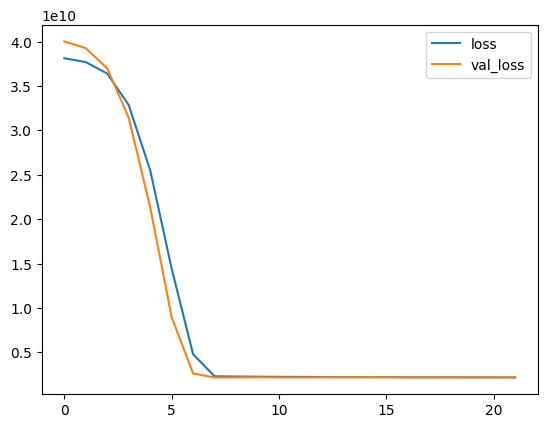

In [ ]:
import pandas as pd
pd.DataFrame(hist.history).plot()

In [ ]:
#@title 예측 실행, 책 210쪽 단순화한 코드임
pred = pd.DataFrame({'pred':model.predict(x_test).flatten().astype('int'), 'real':y_test})

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


<Axes: >

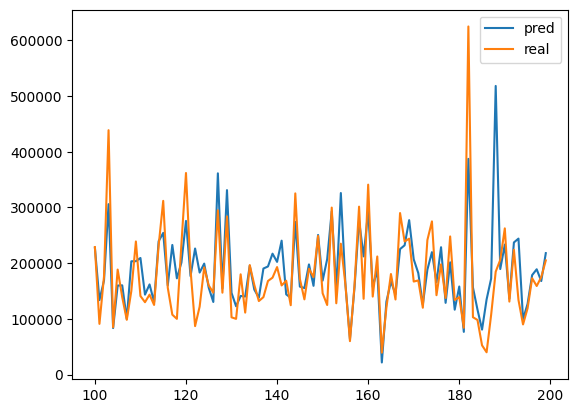

In [ ]:
#@title 실제값 및 예측값 차트 출력
pred.sort_index().iloc[100:200,:].plot()

# 16장 Part1. 이미지 인식 컨볼루션 신경망(CNN) - MNIST 손글씨 분류, 214~228쪽

## 코랩 제공 데이터 활용
- 코랩의 기본 제공 데이터인 sample_data 폴더의 mnist_train_small.csv, mnist_test.csv 파일 활용
- 20,000개의 훈련 데이터와 10,000개의 테스트 데이터로 구성되어 있다.
- 먼저 CSV 파일의 구성을 살펴보자.

In [ ]:
#@title MNIST 필요한 모듈 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [ ]:
#@title 데이터 읽어오기, 1열 : 숫자, 2열 ~ : 이미지 데이터
data = pd.read_csv('sample_data/mnist_train_small.csv', header=None)
data.dtypes

,0
0,int64
1,int64
2,int64
3,int64
4,int64
...,...
780,int64
781,int64
782,int64
783,int64


In [ ]:
#@title 손글씨 배열 이미지로 보이기
# pd.Series를 넘겨 준다.
# 여러 행과 열로 출력하려면 https://www.geeksforgeeks.org/plot-multiple-plots-in-matplotlib/ 참조
def show_image(s) :
  data = np.array(s)
  plt.figure(figsize=(2,2))
  plt.imshow(data.reshape([28,28]), cmap='Greys')
  plt.show()

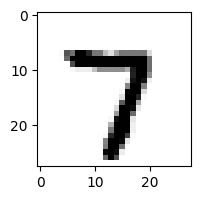

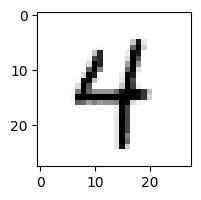

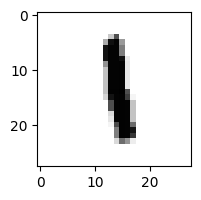

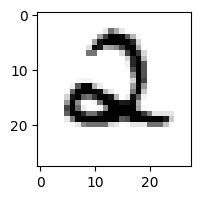

In [ ]:
#@title 임의로 4개 이미지를 출력해 본다.
for i in range(4) :
  show_image(data.iloc[random.randint(0,len(data)-1),1:]/255)

### 데이터 준비
- 직접 샘플 파일을 읽어 온다.


In [ ]:
#@title 기본으로 제공하는 손글씨 데이터 불러오기
train_set = pd.read_csv('sample_data/mnist_train_small.csv', header=None)
test_set = pd.read_csv('sample_data/mnist_test.csv', header=None)
print(train_set.shape, test_set.shape)

(20000, 785) (10000, 785)


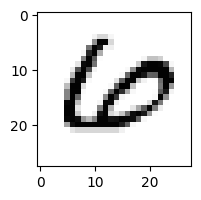

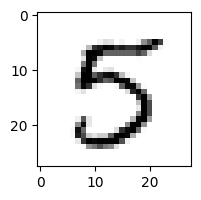

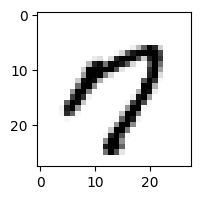

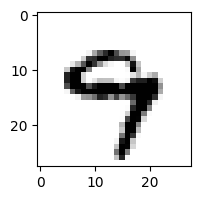

In [ ]:
#@title 입력 및 출력 데이터로 나누어 정규화한다.
train_x = train_set.iloc[:,1:]
train_x /= 255.0 # 정규화
train_y = pd.get_dummies(train_set.iloc[:,0]) # one-hot 인코딩

test_x = test_set.iloc[:,1:]
test_x /= 255.0
test_y = pd.get_dummies(test_set.iloc[:,0]) # one-hot 인코딩
### 여기까지만 ...
for i in range(4) :
  show_image(train_x.iloc[i,:])

### keras 모델 생성

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(32, input_dim=784, activation='relu', name='hidden-1'))
model.add(Dense(16, activation='relu', name='hidden-2'))
model.add(Dense(10, activation='softmax', name='output'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden-1 (Dense)                │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden-2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,818 (100.85 KB)

 Trainable params: 25,818 (100.85 KB)

 Non-trainable params: 0 (0.00 B)

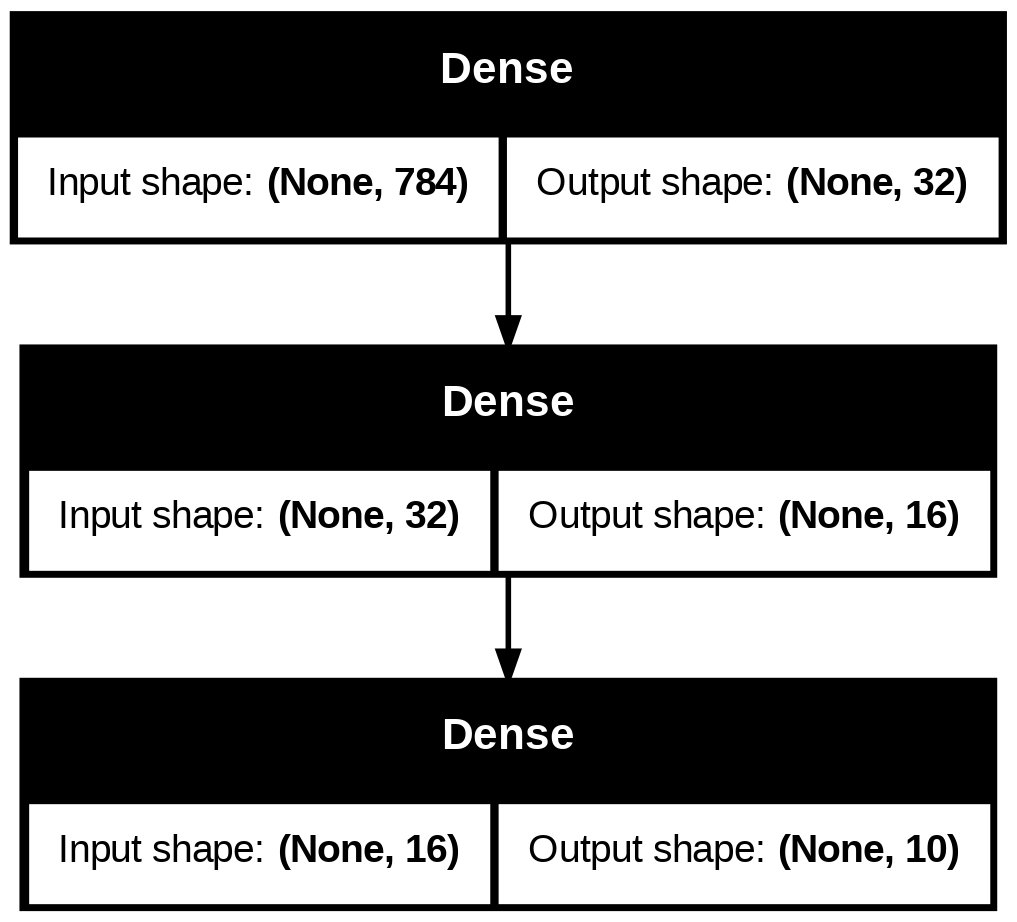

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True)

### 훈련 및 결과

In [ ]:
#@title Keras MNIST 학습
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, LambdaCallback

# 조기종료(EarlyStopping) 콜백
esc = EarlyStopping(monitor='val_loss', patience=10)
# 모델 저장 콜백
mc = ModelCheckpoint(filepath='./data/model/mnist-colab.keras', monitor='val_loss', verbose=0, save_best_only=True)

hist = model.fit(train_x, train_y, shuffle=True, validation_split=0.25, epochs=200, verbose=1, callbacks=[esc, mc])

Epoch 1/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.6152 - loss: 1.2118 - val_acc: 0.9084 - val_loss: 0.3360
Epoch 2/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9089 - loss: 0.3060 - val_acc: 0.9282 - val_loss: 0.2536
Epoch 3/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9348 - loss: 0.2227 - val_acc: 0.9342 - val_loss: 0.2300
Epoch 4/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9449 - loss: 0.1834 - val_acc: 0.9380 - val_loss: 0.2132
Epoch 5/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9550 - loss: 0.1517 - val_acc: 0.9360 - val_loss: 0.2142
Epoch 6/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9613 - loss: 0.1412 - val_acc: 0.9438 - val_loss: 0.1971
Epoch 7/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9609 - loss: 0.1254 - val_acc: 0.9436 - val_loss: 0.1943
Epoch 8/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9703 - loss: 0.1086 - val_acc: 0.9434 - val_loss: 0.1902
Epoch 9/200
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

### 훈련 결과

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.9405 - loss: 0.2361
정확도 : 94.89%, 오류 : 0.2071


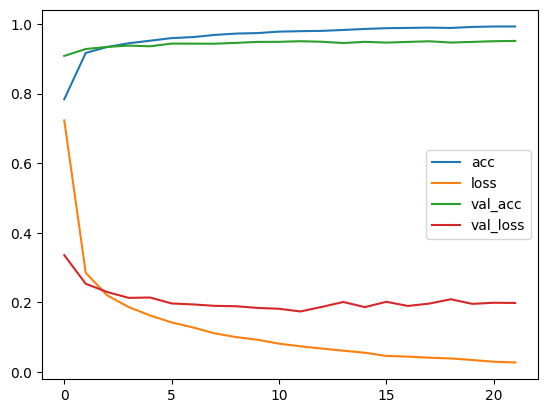

In [ ]:
#@title MNIST 학습 결과
(loss, acc) = model.evaluate(test_x, test_y)
print(f'정확도 : {acc*100:.2f}%, 오류 : {loss:.4f}')
pd.DataFrame(hist.history).plot()
plt.show()

### 테스트셋의 평가

In [ ]:
#@title 평가
(loss, acc) = model.evaluate(test_x, test_y)
print(f'정확도 : {acc*100:.2f}%, 오류 : {loss:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9405 - loss: 0.2361
정확도 : 94.89%, 오류 : 0.2071


In [ ]:
#@title 실제 출력값과 예측값 비교하기
# 예측하기
pred = model.predict(test_x)
# 데이터프레임으로 변환
# 실제값과 예측값을 데이터프레임으로 변환
res = pd.DataFrame({'real':pd.DataFrame(test_y).idxmax(1),
                    'pred':pd.DataFrame(pred).idxmax(1)})
res['result']=res['real']==res['pred']
res

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,real,pred,result
0,7,7,True
1,2,2,True
2,1,1,True
3,0,0,True
4,4,4,True
...,...,...,...
9995,2,2,True
9996,3,3,True
9997,4,4,True
9998,5,5,True


In [ ]:
#@title 틀린 숫자 살펴보기
fault = res[res['result']==False]
fault

,real,pred,result
8,5,6,False
18,3,8,False
61,8,2,False
63,3,8,False
149,2,9,False
...,...,...,...
9888,6,0,False
9892,8,6,False
9925,3,8,False
9975,3,8,False


행번호:숫자:예측숫자


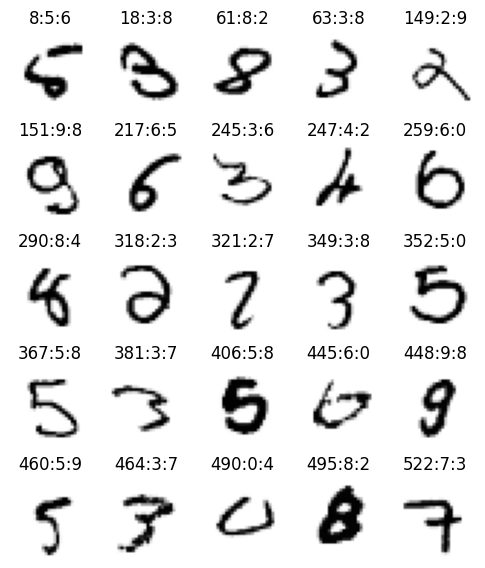

In [ ]:
#@title 틀린 이미지 출력
import matplotlib.pyplot as plt
import numpy as np
import random

print('행번호:숫자:예측숫자')
howmany = 25
plt.figure(figsize=(6,7))
cnt = 0
for i in fault.index:
  ax = plt.subplot(5, 5, cnt+1) # 하위 차트에 출력하기
  ax.imshow(np.array(test_x.iloc[i,:]).reshape(28,28), cmap='Greys') # 이미지 출력
  ax.set_title(f'{i}:{res.iloc[i,0]}:{res.iloc[i,1]}')   # 제목 출력
  ax.axis(False)  # 축 출력 생략
  cnt += 1
  if cnt >= howmany : break

## keras 내장 데이터셋 사용해 보기
- 입력이 28 * 28 2차원 배열이므로 784개의 1차원 배열로 변환(reshape)해야 한다 - Flatten() 함수 이용.

## Using Flatten
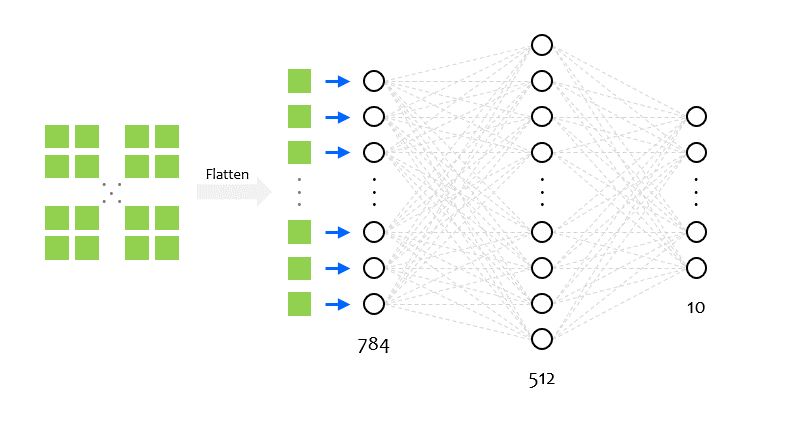

In [ ]:
#@title keras 내장 MNIST 데이터 로딩
from tensorflow import keras
mnist = keras.datasets.mnist

(train_x, train_y),(test_x, test_y) = mnist.load_data()
train_y = pd.get_dummies(train_labels)
test_y = pd.get_dummies(test_labels)
print(train_x.shape, test_x.shape)

(60000, 28, 28) (10000, 28, 28)


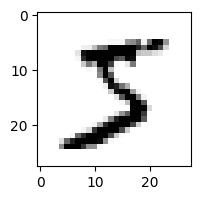

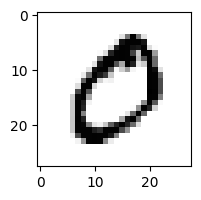

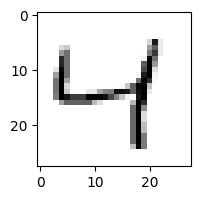

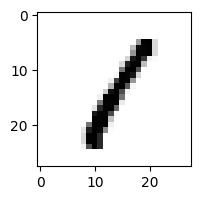

In [ ]:
train_x = train_x / 255
test_x = test_x / 255

for i in range(4) :
  plt.figure(figsize=(2,2))
  plt.imshow(train_x[i], cmap='Greys')
  plt.show()

In [ ]:
#@title 모델 생성 및 컴파일
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,818 (100.85 KB)

 Trainable params: 25,818 (100.85 KB)

 Non-trainable params: 0 (0.00 B)

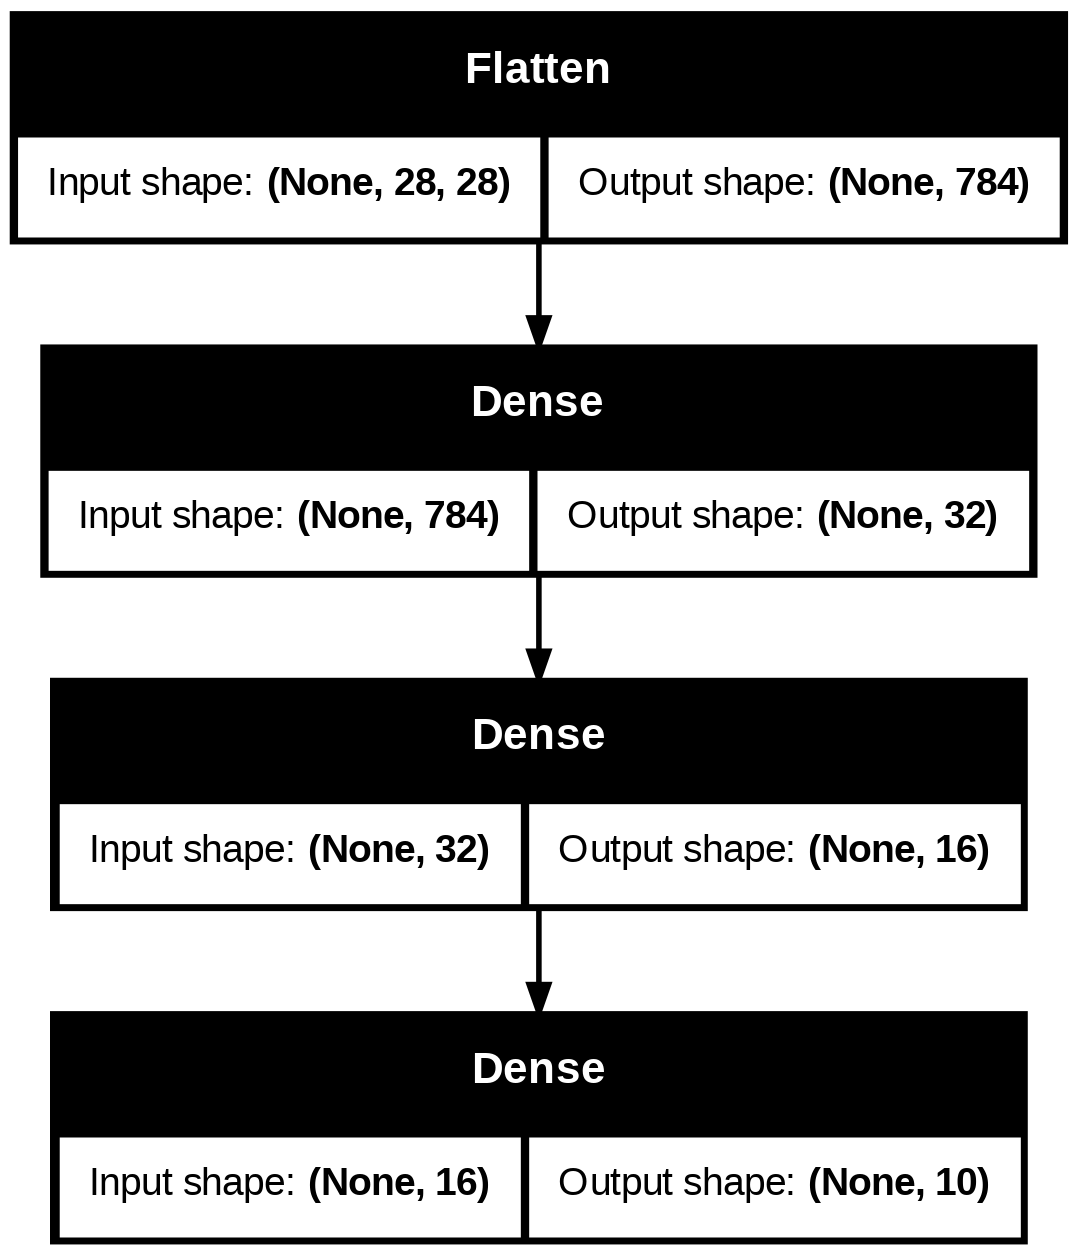

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True)

In [ ]:
#@title Keras MNIST 학습
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, LambdaCallback

# 조기종료(EarlyStopping) 콜백
esc = EarlyStopping(monitor='val_loss', patience=10)
# 모델 저장 콜백
mc = ModelCheckpoint(filepath='./data/model/mnist-keras.keras', monitor='val_loss', verbose=0, save_best_only=True)
# 과정 출력 콜백
lc = LambdaCallback(on_train_begin=lambda l: print('training begins'),
                    on_epoch_end=lambda e, l: print(f'{e:>4d} : {l["acc"]:>.4f}', end='\n' if (e+1) % 6==0 else ' '),
                    on_train_end=lambda l:print('\ntraining ends', l))

hist = model.fit(train_x, train_y, shuffle=True, validation_split=0.25,
                 epochs=200, verbose=0, callbacks=[esc, mc, lc])

training begins
   0 : 0.8745    1 : 0.9415    2 : 0.9540    3 : 0.9622    4 : 0.9656    5 : 0.9705
   6 : 0.9730    7 : 0.9747    8 : 0.9770    9 : 0.9786   10 : 0.9802   11 : 0.9809
  12 : 0.9826   13 : 0.9845   14 : 0.9842   15 : 0.9852   16 : 0.9869   17 : 0.9871
  18 : 0.9881 
training ends {'acc': 0.988111138343811, 'loss': 0.03788711130619049, 'val_acc': 0.9595333337783813, 'val_loss': 0.1692970246076584}


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.9603 - loss: 0.1563
정확도 : 96.28%, 오류 : 0.1489


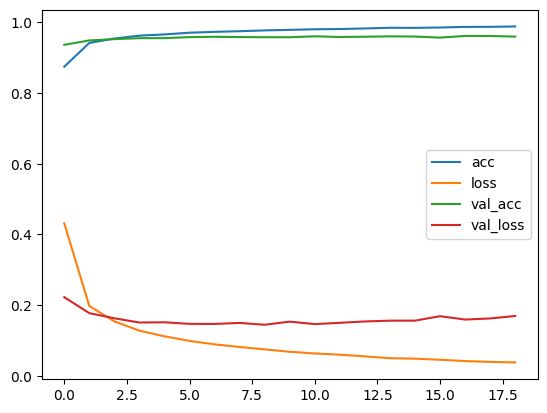

In [ ]:
(loss, acc) = model.evaluate(test_x, test_y)
print(f'정확도 : {acc*100:.2f}%, 오류 : {loss:.4f}')
pd.DataFrame(hist.history).plot()
plt.show()

# 16장 Part2. CNN(합성곱신경망)을 사용한 MNIST 인식 228쪽~
- Conv2D(), MaxPooling2D() 레이어 추가
- Dropout() 레이어 추가, Flatten() 추가

### import modules

In [ ]:
#@title CNN에 필요한 모듈 임포트
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### import datasets

In [ ]:
(train_x, train_y), (test_x, test_y) = mnist.load_data()
train_x = train_x.reshape(train_x.shape[0], 28, 28, 1).astype('float32') / 255.0
test_x = test_x.reshape(test_x.shape[0], 28, 28, 1).astype('float32') / 255.0

train_y = to_categorical(train_y)
test_y = to_categorical(test_y)

### 모델 생성

In [ ]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3), input_shape=(28,28,1), activation='relu'))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

### 모델 최적화

In [ ]:
modelpath = './MNIST_CNN.keras'
mc = ModelCheckpoint(filepath=modelpath, monitor='val_loss', verbose=1, save_best_only=True)
esc = EarlyStopping(monitor='val_loss', patience=10)

### 모델 실행 (학습)

In [ ]:
hist = model.fit(train_x, train_y, validation_split=0.25, epochs=500, callbacks=[esc, mc])

Epoch 1/500
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.8671 - loss: 0.4244
Epoch 1: val_loss improved from inf to 0.06511, saving model to ./MNIST_CNN.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - acc: 0.8672 - loss: 0.4242 - val_acc: 0.9801 - val_loss: 0.0651
Epoch 2/500
1395/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9714 - loss: 0.0936
Epoch 2: val_loss improved from 0.06511 to 0.05002, saving model to ./MNIST_CNN.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - acc: 0.9714 - loss: 0.0936 - val_acc: 0.9855 - val_loss: 0.0500
Epoch 3/500
1397/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9795 - loss: 0.0689
Epoch 3: val_loss improved from 0.05002 to 0.04858, saving model to ./MNIST_CNN.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.9795 - loss: 0.0689 - val_acc: 0.9859 - val_loss: 0.0486
Epoch 4/500
1398/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9835 - loss: 0.0535
Epoch 4: val_loss improved from 0.04858 to 0.04632, saving model to ./MNIST_CNN.k

### 평가 및 결과 차트

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9896 - loss: 0.0446

 Test Accuracy : 0.9913


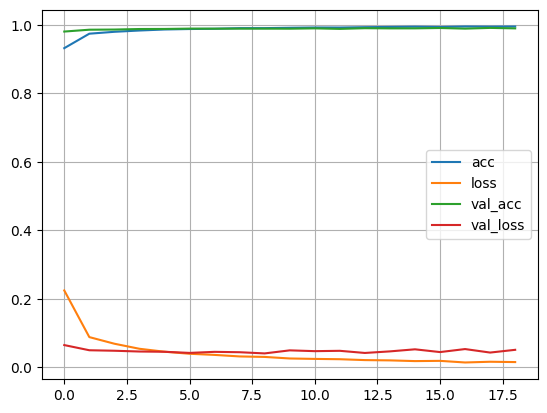

In [ ]:
print(f'\n Test Accuracy : {model.evaluate(test_x, test_y)[1]:.4f}')
pd.DataFrame(hist.history).plot(grid=True)
plt.show()

### 텐서보드 사용

In [ ]:
%load_ext tensorboard
import datetime
import tensorflow as tf

!rm -rf ./logs/
log_dir = 'logs/fit/' + datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

In [ ]:
#hist = model.fit(train_x, train_y, validation_split=0.25, epochs=20, batch_size=200,
#                verbose=0, callbacks=[early_stopping_callback, checkpointer, tensorboard_callback])
model.save('mnist_cnn.keras')

In [ ]:
# @title view errors
import tensorflow as tf
new_model = tf.keras.models.load_model('mnist_cnn.keras')

In [ ]:
new_model.evaluate(test_x, test_y)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9895 - loss: 0.0463


[0.039887938648462296, 0.9912999868392944]

In [ ]:
import pandas as pd
import numpy as np
pred = np.round(new_model.predict(test_x))
print(pred.argmax(axis=1))
df = pd.DataFrame({'real':test_y.argmax(axis=1), 'pred':pred.argmax(axis=1)})
idx = df[df.real!=df.pred].index
idx.shape, idx

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[7 2 1 ... 4 5 6]


((89,),
 Index([ 321,  445,  684,  740,  882,  947, 1014, 1033, 1039, 1112, 1182, 1226,
        1232, 1247, 1364, 1393, 1414, 1500, 1530, 1553, 1554, 1709, 1754, 1790,
        1878, 1901, 2018, 2043, 2053, 2118, 2129, 2130, 2135, 2293, 2414, 2462,
        2488, 2597, 2654, 2771, 2896, 2921, 2927, 2939, 3030, 3060, 3073, 3422,
        3503, 3520, 3534, 3558, 3780, 3808, 3906, 3941, 4015, 4078, 4176, 4265,
        4500, 4507, 4536, 4601, 4740, 4761, 4807, 4860, 4886, 5888, 5955, 5997,
        6555, 6576, 6597, 6625, 8095, 8246, 9009, 9015, 9019, 9620, 9638, 9642,
        9664, 9679, 9692, 9729, 9839],
       dtype='int64'))

      real  pred
321      2     7
445      6     0
684      7     0
740      4     9
882      9     7
...    ...   ...
9664     2     7
9679     6     3
9692     9     7
9729     5     6
9839     2     7

[89 rows x 2 columns]


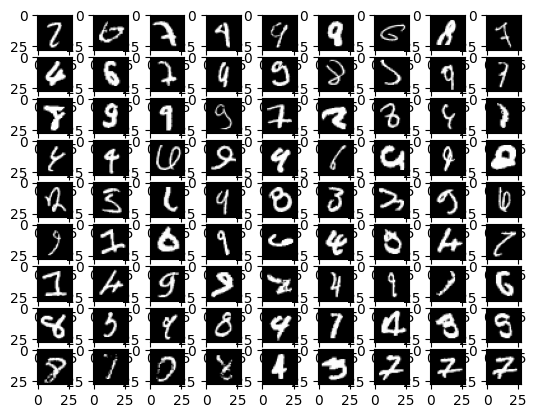

In [ ]:
import matplotlib.pyplot as plt
print(df.iloc[idx])
for i, n in enumerate(idx) :
   if i > 80 : break
   plt.subplot(9,9,i+1)
   plt.imshow(test_x[n], cmap='gray')
plt.show()

In [ ]:
%tensorboard --logdir logs/fit

UsageError: Line magic function `%tensorboard` not found.


# 16장 추가 1. CNN을 사용한 CIFAR10 인식
- airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

## CIFAR-10 단순 softmax

In [ ]:
#@title 필요한 모듈 임포트
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
#@title CIFAR-10 이미지 데이터 로딩
from tensorflow import keras
(x,y),(tx,ty) = keras.datasets.cifar10.load_data()
x.shape, y.shape, tx.shape, ty.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

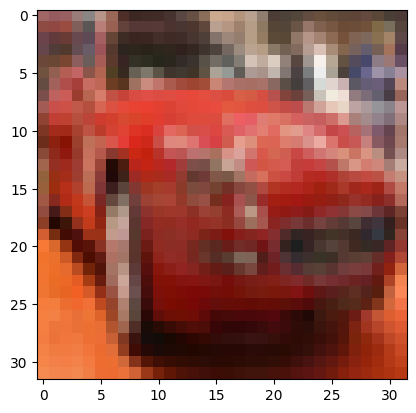

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x[5])
plt.show()

In [ ]:
#@title 원-핫 인코딩
train_labels = pd.get_dummies(y.flatten())
test_labels = pd.get_dummies(ty.flatten())

In [ ]:
#@title 분류 모델 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential()
model.add(Flatten(input_shape=(32,32,3)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │       196,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,450 (779.10 KB)

 Trainable params: 199,450 (779.10 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
hist = model.fit(x, train_labels, epochs=25, verbose=1)

Epoch 1/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.1117 - loss: 16.6437
Epoch 2/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.0990 - loss: 2.3040
Epoch 3/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - acc: 0.1002 - loss: 2.3067
Epoch 4/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.0992 - loss: 2.3027
Epoch 5/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - acc: 0.0972 - loss: 2.3028
Epoch 6/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.0978 - loss: 2.3027
Epoch 7/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.0975 - loss: 2.3027
Epoch 8/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.1013 - loss: 2.3027
Epoch 9/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.0985 - loss: 2.3028
Epoch 10/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.0996 - loss: 2.3027
Epoch 11/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.0993 - loss: 2.3028
Epoch 12/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.1006 - loss: 2.3027

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - acc: 0.0997 - loss: 2.3027
정확도 : 10.00%, 오류 : 2.3026


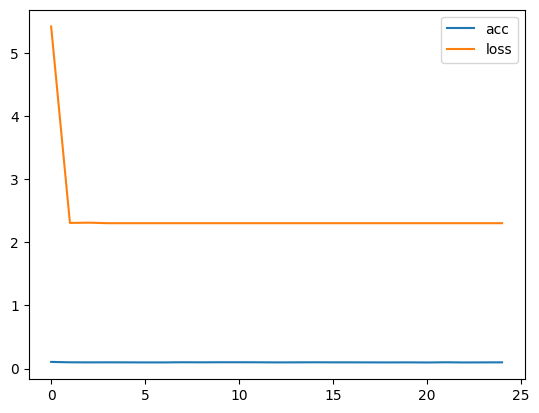

In [ ]:
(loss, acc) = model.evaluate(x, train_labels)
print(f'정확도 : {acc*100:.2f}%, 오류 : {loss:.4f}')
pd.DataFrame(hist.history).plot()
plt.show()

## CIFAR10 - CNN 모델 사용

### import modules

In [ ]:
#@title CNN을 위한 모듈 임포트
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import CIFAR10 datasets

In [ ]:
#@title CIFAR-10 데이터 로딩
from tensorflow import keras
(x,y),(tx,ty) = keras.datasets.cifar10.load_data()
x = x / 255.0
tx = tx / 255.0
y = pd.get_dummies(y.flatten())
ty = pd.get_dummies(ty.flatten())

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


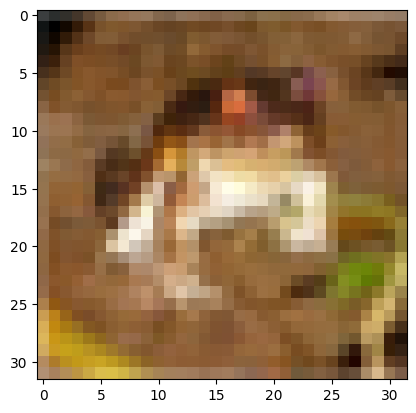

In [ ]:
#@title 첫 번째 이미지 출력
import matplotlib.pyplot as plt
plt.imshow(x[0])
plt.show()

### Create CNN model for CIFAR10

In [ ]:
#@title CNN 모델 생성
model = Sequential()
model.add(Conv2D(32, kernel_size=(4,4), input_shape=(32,32,3), activation='relu'))
model.add(Conv2D(64, (4,4), activation='relu'))
model.add(MaxPooling2D(pool_size=(4,4)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Run !

In [ ]:
#@title 콜백 작성 및 모델 훈련
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, LambdaCallback

# 조기종료(EarlyStopping) 콜백
esc = EarlyStopping(monitor='val_loss', patience=10)
# 모델 저장 콜백
mc = ModelCheckpoint(filepath='./data/model/ch16-CNN-CIFAR10.keras', monitor='val_loss', verbose=0, save_best_only=True)

hist = model.fit(x, y, epochs=500, validation_split=0.2, callbacks=[esc, mc])

Epoch 1/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.3429 - loss: 1.7765 - val_acc: 0.5511 - val_loss: 1.2596
Epoch 2/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.5497 - loss: 1.2626 - val_acc: 0.5896 - val_loss: 1.1493
Epoch 3/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.6070 - loss: 1.1108 - val_acc: 0.6289 - val_loss: 1.0636
Epoch 4/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - acc: 0.6343 - loss: 1.0324 - val_acc: 0.6558 - val_loss: 0.9807
Epoch 5/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.6619 - loss: 0.9647 - val_acc: 0.6741 - val_loss: 0.9303
Epoch 6/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - acc: 0.6782 - loss: 0.9117 - val_acc: 0.6792 - val_loss: 0.9250
Epoch 7/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.6926 - loss: 0.8711 - val_acc: 0.6897 - val_loss: 0.8897
Epoch 8/500
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.7085 - loss: 0.8311 - val_acc: 0.6987 - val_loss: 0.8724
Epoch 9/500
1250/1250 ━━━━━━━━━

### Evaluate and plot chart

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.9092 - loss: 0.3246
[0.4302498400211334, 0.8713200092315674]


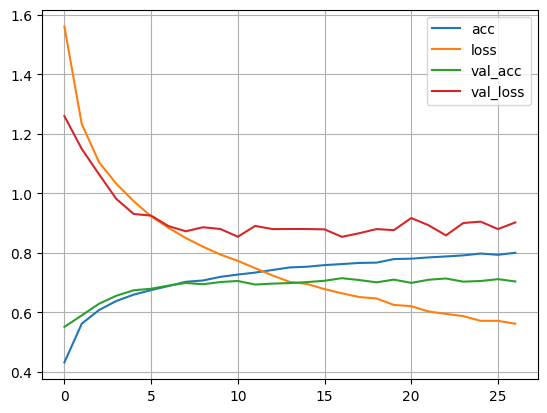

In [ ]:
#@title 차트로 결과 확인
print(model.evaluate(x,y))
pd.DataFrame(hist.history).plot(grid=True)
plt.show()

### Predict

In [ ]:
model.evaluate(tx, ty)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.7212 - loss: 0.8275


[0.843932032585144, 0.715399980545044]

In [ ]:
pred = model.predict(tx)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [ ]:
#@title 이미지 번호 선택 { run: "auto", form-width: "300px" }
i = 51 #@param {type:"slider", min:0, max:100, step:1}
df_ty = pd.DataFrame(ty)
df_py = pd.DataFrame(pred)
obj_name = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print(f'정답 : {obj_name[df_ty.iloc[i].idxmax()]}, 예측 : {obj_name[df_py.iloc[i].idxmax()]}')
# 이미지와 확률 출력
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(tx[i])
plt.subplot(1,2,2)
plt.grid(True)
plt.bar(list(range(10)), pred[i])
plt.xticks(list(range(10)), labels=obj_name, rotation=90)
plt.show()

NameError: name 'pred' is not defined

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
정답 : truck, 예측 : automobile, 예측값 : 81.40%


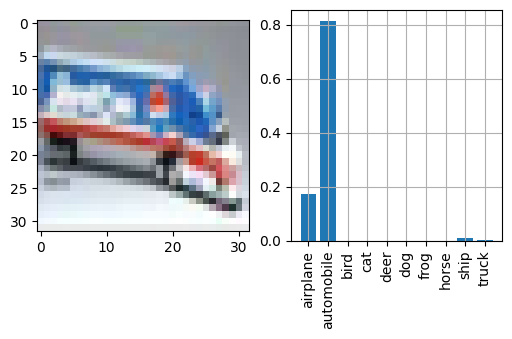

정답 : ship, 예측 : ship, 예측값 : 99.86%


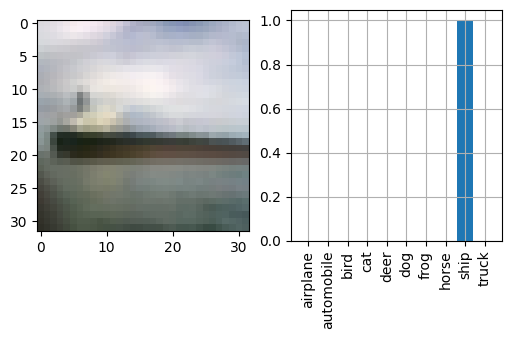

정답 : horse, 예측 : horse, 예측값 : 99.60%


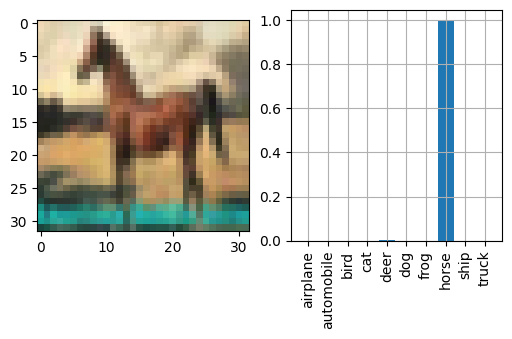

정답 : cat, 예측 : cat, 예측값 : 62.69%


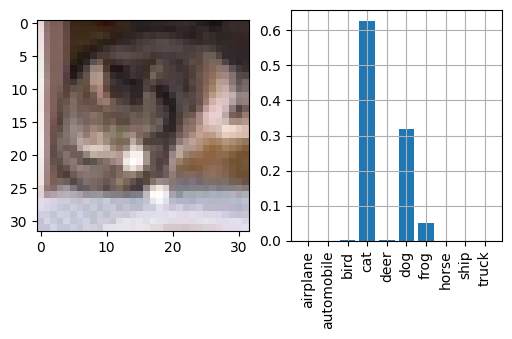

정답 : bird, 예측 : deer, 예측값 : 56.64%


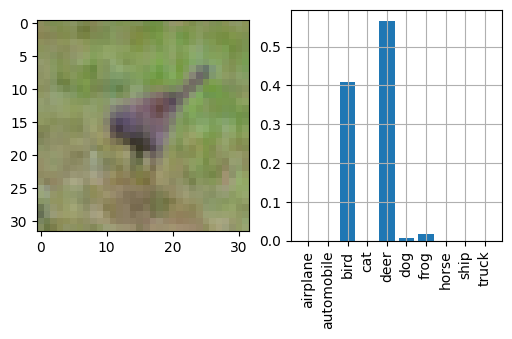

정답 : ship, 예측 : ship, 예측값 : 97.37%


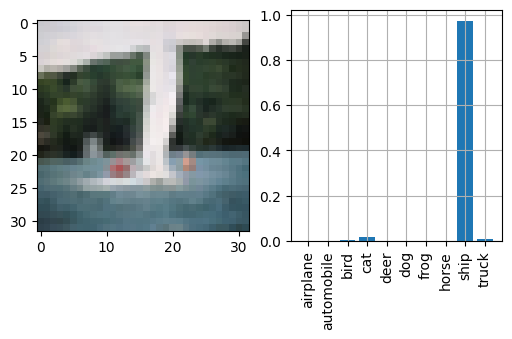

정답 : cat, 예측 : horse, 예측값 : 62.37%


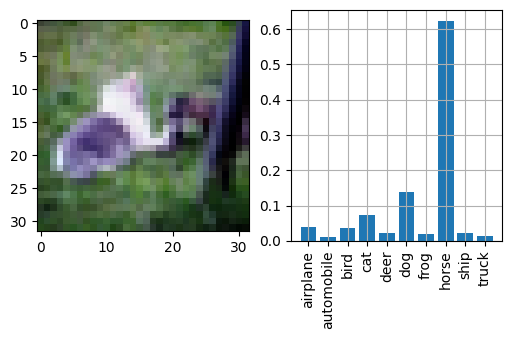

정답 : automobile, 예측 : automobile, 예측값 : 87.62%


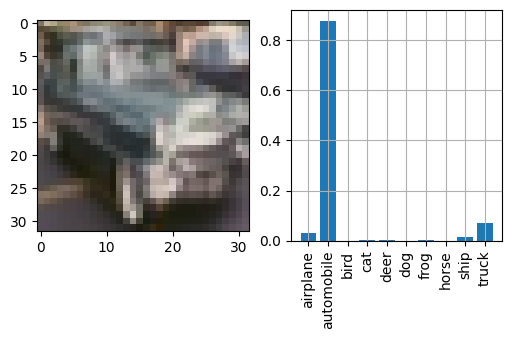

정답 : airplane, 예측 : airplane, 예측값 : 99.09%


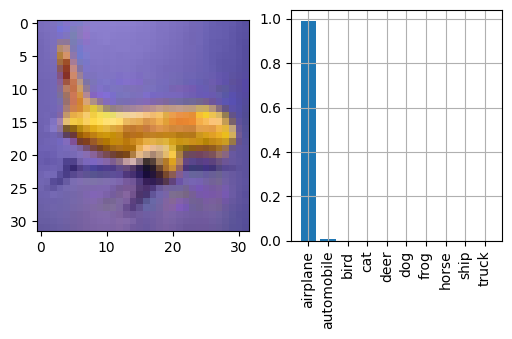

정답 : deer, 예측 : deer, 예측값 : 93.18%


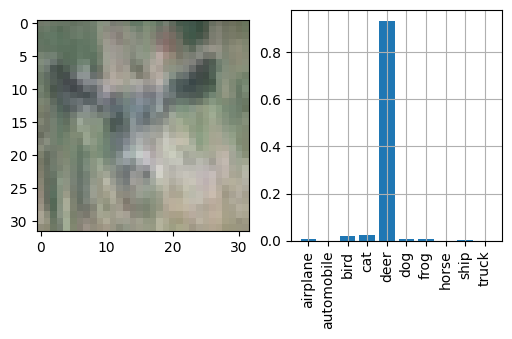

In [ ]:
#@title 1만개 테스트 이미지 중 임의의 10개를 출력해 본다.
import random
df_ty = pd.DataFrame(ty)
pred = model.predict(tx)
df_py = pd.DataFrame(pred)
rnd = random.sample(list(range(len(df_py))), 10)

obj_name = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

for i in rnd :
  print(f'정답 : {obj_name[df_ty.iloc[i].idxmax()]}, 예측 : {obj_name[df_py.iloc[i].idxmax()]}, 예측값 : {max(df_py.iloc[i])*100:.2f}%')

  plt.figure(figsize=(6,3))
  plt.subplot(1,2,1)
  plt.imshow(tx[i])
  plt.subplot(1,2,2)
  plt.grid(True)
  plt.bar(list(range(10)), pred[i])
  plt.xticks(list(range(10)), labels=obj_name, rotation=90)
  plt.show()

### Save and load model

In [ ]:
import datetime
today = datetime.date.today()
filepath = today.strftime('cifar10-%Y%m%d.keras')
#filepath
model.save(filepath)

In [ ]:
import tensorflow as tf
new_model = tf.keras.models.load_model(filepath)
new_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 992,192 (3.78 MB)

 Trainable params: 330,730 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 661,462 (2.52 MB)

In [ ]:
eval = new_model.evaluate(tx, ty)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - acc: 0.7212 - loss: 0.8275


In [ ]:
eval

[0.843932032585144, 0.715399980545044]

In [ ]:
pred = new_model.predict(tx)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


# 16장 추가 - 기존 이미지로 데이터셋 만들기 : Cat & Dog
- 참고 사이트 : https://www.tensorflow.org/tutorials/load_data/images?hl=ko

- catdog160.zip 파일을 미리 구글드라이브-내 드라이브-data 폴더에 업로드해 둔다(출처: kaggle)
- image_dataset_from_directory() 함수를 활용하여 폴더 내의 이미지를 데이터셋으로 만드는 방법을 익힌다.


In [ ]:
#@title 압축 풀기
!unzip /content/drive/MyDrive/data/catdog160.zip -d /content/

Archive:  /content/drive/MyDrive/data/catdog160.zip
replace /content/catdog/test_set/cats/cat.4349.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
#@title 필요한 함수 작성
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# 주어진 폴더의 이미지를 데이터셋으로 만든다.
def load_images_dir(dir, x=64, y=64) : # 기본이미지 크기 : 64x64
    ds = tf.keras.utils.image_dataset_from_directory(dir, image_size=(x, y))
    class_names = ds.class_names
    return ds, class_names

# 10개의 이미지를 출력해 본다.
def draw_images(dataset, class_names) :
    plt.figure(figsize=(4,4))
    for images, labels in dataset.take(1) :
        for i in range(9) :
            plt.subplot(3,3,i+1)
            plt.imshow(images[i].numpy().astype('uint8'))
            plt.title(class_names[labels[i]])
            plt.axis('off')
    plt.show()

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


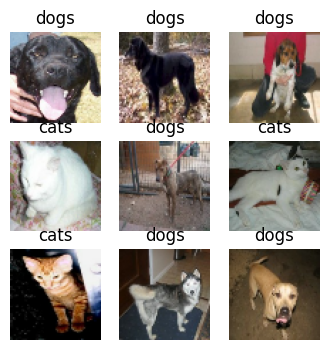

In [ ]:
#@title 데이터셋 만들기
train_dir = '/content/catdog/training_set'
test_dir = '/content/catdog/test_set'
train_ds, class_names = load_images_dir(train_dir)
test_ds, class_names = load_images_dir(test_dir)
draw_images(train_ds, class_names)

In [ ]:
#@title CNN을 위한 모듈 임포트
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
#@title 기본 CNN 모델 생성
model = Sequential()
model.add(tf.keras.layers.Rescaling(1./255)) # 추가
model.add(Conv2D(32, kernel_size=(4,4), input_shape=(64,64,3), activation='relu')) # 수정 : 32 -> 64
model.add(Conv2D(64, (4,4), activation='relu'))
model.add(MaxPooling2D(pool_size=(4,4)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2)) # 다름

# loss 함수와 from_logits에 주의!
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer='adam', metrics=['acc'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#@title 콜백 작성 및 모델 훈련
# 조기종료(EarlyStopping) 콜백
esc = EarlyStopping(monitor='val_loss', patience=10)
# 모델 저장 콜백 - 내 구글 드라이브 data 폴더에 저장
mc = ModelCheckpoint(filepath='/content/drive/MyDrive/data/ch16-CNN-catdog.keras', monitor='val_loss', verbose=0, save_best_only=True)
# dataset(train_ds)에 x, y 모두 포함되어 있음.
hist = model.fit(train_ds, validation_data=test_ds, epochs=500, callbacks=[esc, mc])

Epoch 1/500
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - acc: 0.5378 - loss: 0.6960 - val_acc: 0.6525 - val_loss: 0.6174
Epoch 2/500
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - acc: 0.6764 - loss: 0.6114 - val_acc: 0.7355 - val_loss: 0.5505
Epoch 3/500
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - acc: 0.7196 - loss: 0.5492 - val_acc: 0.7548 - val_loss: 0.5248
Epoch 4/500
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - acc: 0.7676 - loss: 0.4963 - val_acc: 0.7716 - val_loss: 0.5016
Epoch 5/500
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - acc: 0.7922 - loss: 0.4525 - val_acc: 0.7716 - val_loss: 0.4969
Epoch 6/500
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - acc: 0.8167 - loss: 0.4076 - val_acc: 0.7731 - val_loss: 0.5057
Epoch 7/500
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - acc: 0.8363 - loss: 0.3690 - val_acc: 0.7855 - val_loss: 0.5036
Epoch 8/500
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - acc: 0.8605 - loss: 0.3125 - val_acc: 0.7800 - val_loss: 0.5275
Epoch 9/500
251/251 ━━━━━━━━━━━━━━━━━━━

64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - acc: 0.5173 - loss: 0.7117
[0.7198514342308044, 0.5002471804618835]


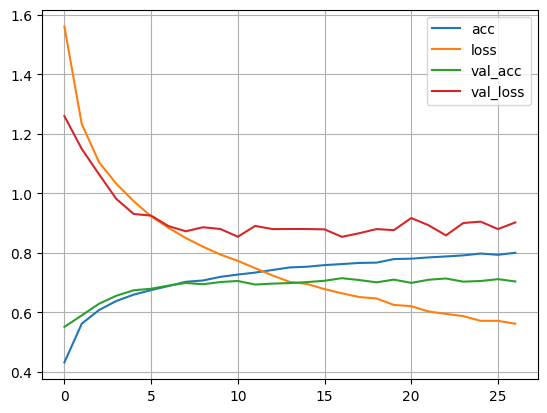

In [ ]:
#@title 차트로 결과 확인
print(model.evaluate(test_ds))
pd.DataFrame(hist.history).plot(grid=True)
plt.show()

In [ ]:
#@title 모델 개선 1
model = Sequential()
model.add(tf.keras.layers.Rescaling(1./255))
model.add(Conv2D(32, kernel_size=(4,4), input_shape=(64,64,3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (4,4), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(4,4)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.25))
model.add(Dense(2))

# loss 함수에 주의!
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer='adam', metrics=['acc'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#@title 모델 개선 2
model = Sequential()
model.add(tf.keras.layers.Rescaling(1./255))
model.add(Conv2D(32, kernel_size=(3,3), input_shape=(64,64,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(2))

# loss 함수에 주의!
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer='adam', metrics=['acc'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#@title 콜백 작성 및 모델 훈련
# 조기종료(EarlyStopping) 콜백
esc = EarlyStopping(monitor='val_loss', patience=10)
# 모델 저장 콜백
mc = ModelCheckpoint(filepath='/content/drive/MyDrive/data/ch16-CNN-catdog.keras', monitor='val_loss', verbose=0, save_best_only=True)

hist = model.fit(train_ds, validation_data=test_ds, epochs=500, callbacks=[esc, mc])

Epoch 1/500
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step - acc: 0.6213 - loss: 1.0281 - val_acc: 0.5057 - val_loss: 1.3486
Epoch 2/500
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - acc: 0.6974 - loss: 0.5826 - val_acc: 0.5783 - val_loss: 0.9365
Epoch 3/500
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - acc: 0.7503 - loss: 0.5217 - val_acc: 0.7118 - val_loss: 0.5907
Epoch 4/500
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - acc: 0.7798 - loss: 0.4736 - val_acc: 0.6915 - val_loss: 0.6206
Epoch 5/500
251/251 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - acc: 0.7999 - loss: 0.4378 - val_acc: 0.6965 - val_loss: 0.6437
Epoch 6/500
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - acc: 0.8181 - loss: 0.4093 - val_acc: 0.5561 - val_loss: 1.4327
Epoch 7/500
251/251 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - acc: 0.8242 - loss: 0.3926 - val_acc: 0.7360 - val_loss: 0.5847
Epoch 8/500
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - acc: 0.8622 - loss: 0.3318 - val_acc: 0.7400 - val_loss: 0.6307
Epoch 9/500
251/251 ━━━━━━━━━━━━━━━━━━━

In [ ]:
#@title 모델 저장
model.save('/content/drive/MyDrive/data/ch16-CNN-catdog.keras')

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.7688 - loss: 0.7467
[0.796391487121582, 0.756302535533905]


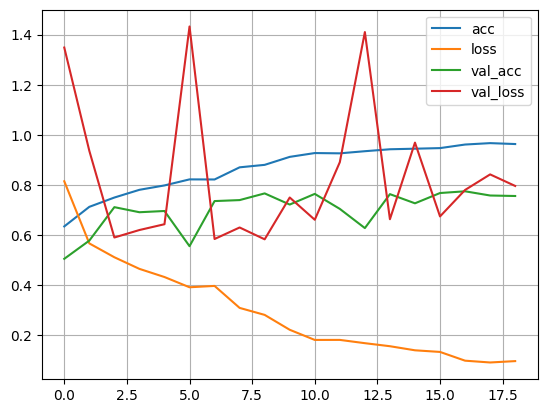

In [ ]:
#@title 차트로 결과 확인
print(model.evaluate(test_ds))
pd.DataFrame(hist.history).plot(grid=True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
정확도 : 53.125%


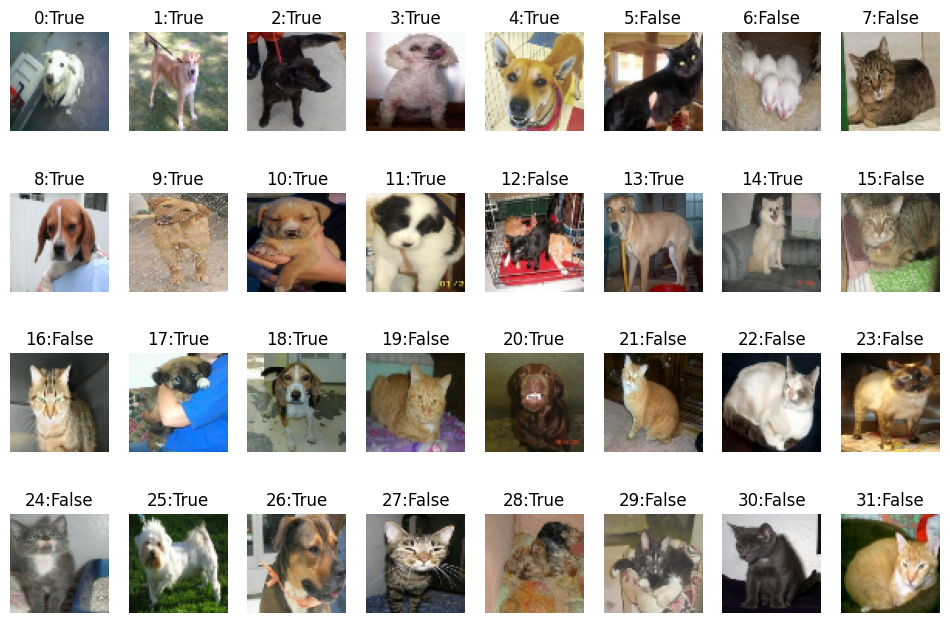

In [ ]:
#@title 예측 결과 사진 보기
import matplotlib.pyplot as plt
# 배치(32개 데이터)를 차례대로 가져 온다.
for images, labels in test_ds.take(1) : #next(test_ds)
    r = model.predict(images)
    break

import pandas as pd
df = pd.DataFrame(r)
df['pred'] = (df[0] < df[1]).astype(int)

df['real'] = labels.numpy()

acc = (df.real == df.pred).sum()/df.count() * 100
print(f'정확도 : {acc.mean()}%')

plt.figure(figsize=(12,8))
for i, img in enumerate(images) :
  ax = plt.subplot(4,8,i+1)
  ax.imshow(img/255.0)
  ax.set_title(f'{i}:{df.iloc[i,2]==df.iloc[i,3]}')
  ax.axis(False)  # 축 출력 생략

In [ ]:
#@title 모델 불러오기
import tensorflow as tf
new_model = tf.keras.models.load_model('/content/drive/MyDrive/data/ch16-CNN-catdog.keras')
new_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 61, 61, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 58, 58, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,921,256 (18.77 MB)

 Trainable params: 1,640,418 (6.26 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,280,838 (12.52 MB)

In [ ]:
#@title 이미지 파일 목록
import os
dir = '/content/pi/'
files = os.listdir(dir)
files.sort()
files

FileNotFoundError: [Errno 2] No such file or directory: '/content/pi/'

In [ ]:
#@title 이미지 불러와서 데이터셋 만들기
import cv2
import numpy as np

# 처음 이미지를 로딩한다.
img = cv2.imread(dir+str(files[0]))
img = cv2.resize(img, (64,64))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# 차원을 1개 늘인다.
imgs = np.expand_dims(img, axis=0)

# 이후 이미지를 읽어 resize 후 차례대로 쌓아준다.
for file in files[1:] :
  img = cv2.imread(dir+file)
  img = cv2.resize(img, (64,64))
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  # 차원을 맞춰 준다.
  img = np.expand_dims(img, axis=0)
  imgs = np.concatenate([imgs, img], axis=0)

imgs.shape

NameError: name 'files' is not defined

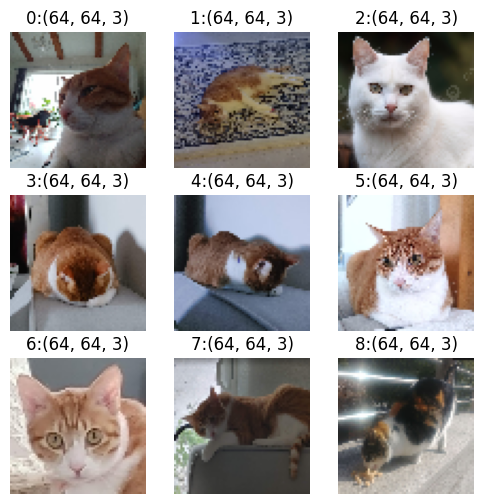

In [ ]:
#@title 이미지 출력해 보기
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
for i, img in enumerate(imgs) :
  if i>8:break
  ax = plt.subplot(3,3,i+1)
  ax.imshow(img)
  ax.set_title(f'{i}:{img.shape}')
  ax.axis(False)

In [ ]:
#@title 예측해 보기
import pandas as pd
pred = pd.DataFrame(new_model.predict(imgs), columns=['cat','dog'])
pred['pred'] = (pred.dog > pred.cat).astype(int)
print(pred.groupby('pred').count())
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
      cat  dog
pred          
0       7    7
1       3    3


,cat,dog,pred
0,0.937460,0.028840,0
1,-5.342506,-1.440789,1
2,1.541073,-5.677514,0
3,4.688350,2.655818,0
4,-0.054003,0.062509,1
5,4.211651,0.390267,0
6,3.720757,-0.055530,0
7,1.047995,-4.403250,0
8,-1.751884,-2.308143,0
9,-1.719550,2.266233,1


# 16장 추가 2. 도형 인식하기

# Tensorflow 내장 데이터세트

In [ ]:
import tensorflow_datasets as td
help(td)

Help on package tensorflow_datasets:

NAME
    tensorflow_datasets - `tensorflow_datasets` (`tfds`) defines a collection of datasets ready-to-use with TensorFlow.

DESCRIPTION
    Each dataset is defined as a `tfds.core.DatasetBuilder`, which encapsulates
    the logic to download the dataset and construct an input pipeline, as well as
    contains the dataset documentation (version, splits, number of examples, etc.).
    
    The main library entrypoints are:
    
    * `tfds.builder`: fetch a `tfds.core.DatasetBuilder` by name
    * `tfds.load`: convenience method to construct a builder, download the data, and
      create an input pipeline, returning a `tf.data.Dataset`.
    
    Documentation:
    
    * These API docs
    * [Available datasets](https://www.tensorflow.org/datasets/catalog/overview)
    * [Colab
    tutorial](https://colab.research.google.com/github/tensorflow/datasets/blob/master/docs/overview.ipynb)
    * [Add a dataset](https://www.tensorflow.org/datasets/add_dat

In [ ]:
import tensorflow_datasets as tfds
image, label = tfds.as_numpy(tfds.load('mnist', split='test', batch_size=-1, as_supervised=True))

print(type(image), image.shape)

<class 'numpy.ndarray'> (10000, 28, 28, 1)


2


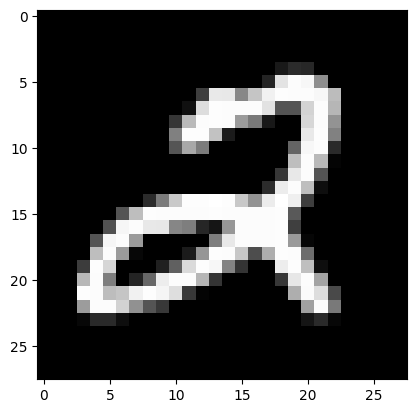

In [ ]:
import matplotlib.pyplot as plt
print(label[0])
plt.imshow(image[0], cmap='gray')

In [ ]:
import pandas as pd
df = pd.DataFrame(image.reshape(10000, 28*28))
df[:1].sum(axis=1)

,0
0,33963


# sklearn 데이터셋

In [ ]:
'''
scikit-learn(sklearn)에서 제공하는 데이터셋은 크게 세 가지로 분류할 수 있습니다:

- Toy Datasets (간단한 예제 데이터셋): 이 데이터셋들은 작고 미리 정의된 데이터로, 모델을 실험하고 빠르게 테스트할 수 있도록 설계되었습니다. 몇 가지 주요 toy 데이터셋은 다음과 같습니다:
load_iris(): 아이리스 꽃 데이터셋. 4개의 특성으로 3가지 종류의 꽃을 분류.
load_digits(): 0부터 9까지의 숫자를 포함하는 손글씨 이미지 데이터셋.
load_wine(): 와인의 화학적 특성을 사용하여 3가지 종류의 와인을 분류.
load_breast_cancer(): 유방암 진단 데이터셋으로 양성, 악성 여부를 예측.


- Real-world Datasets (실제 데이터셋): 이 데이터셋들은 sklearn의 fetch_로 시작하는 함수로 불러올 수 있으며, 실제 사용 사례에서 나오는 데이터를 포함합니다. 대부분 사이즈가 커서 온라인에서 다운로드받아 사용해야 합니다.
fetch_20newsgroups(): 20개의 서로 다른 뉴스 그룹의 텍스트 문서를 포함한 텍스트 데이터셋.
fetch_lfw_people(): 유명 인물들의 얼굴 사진 데이터셋.
fetch_olivetti_faces(): 40명의 사람 얼굴 이미지를 포함한 데이터셋.
fetch_covtype(): 숲의 토양 유형을 예측하는 데이터셋.

- Generated Datasets (인공 데이터셋): scikit-learn은 다양한 형태의 데이터를 직접 생성하는 도구도 제공합니다. 주로 모형을 검증하거나 학습할 때 임의의 데이터를 생성하는데 사용됩니다.
make_classification(): 분류 문제를 위한 랜덤 데이터를 생성.
make_regression(): 회귀 문제를 위한 랜덤 데이터를 생성.
make_blobs(): 클러스터링 연습을 위한 랜덤 데이터를 생성.
make_moons(), make_circles(): 비선형 분류 문제를 위한 데이터셋을 생성.
'''

In [ ]:
import sklearn.datasets as skd
df = skd.fetch_olivetti_faces()
df.keys()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


dict_keys(['data', 'images', 'target', 'DESCR'])

In [ ]:
print(df['DESCR'])

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

In [ ]:
df['target'].shape

(400,)

In [ ]:
x = pd.DataFrame(df)
x.head()

ValueError: Per-column arrays must each be 1-dimensional

[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


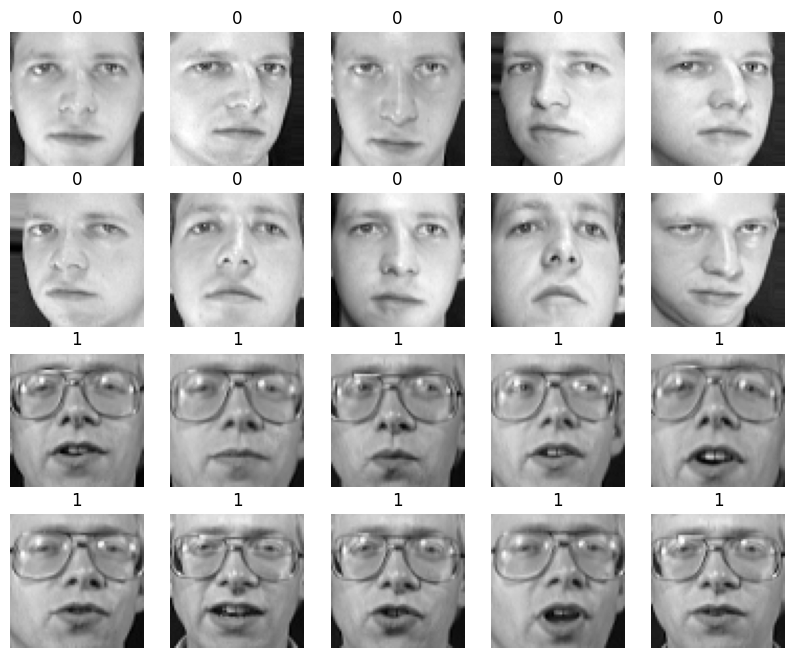

In [ ]:
print(df['target'][:20])
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
for i in range(20) :
  plt.subplot(4,5,i+1)
  plt.imshow(df['images'][i], cmap='gray')
  plt.title(df['target'][i])
  plt.axis('off')
plt.show()

In [ ]:
data = skd.make_classification()
print(data[0].shape, data[1].shape)
data

(100, 20) (100,)


(array([[ 1.78847775, -0.46514613, -1.06268727, ...,  1.04443835,
          0.69487869, -0.25357732],
        [ 0.69671534,  0.28868942, -0.91440592, ..., -0.9811299 ,
          0.32557447,  0.37548547],
        [-2.03531266, -1.06477442,  1.8746671 , ..., -1.57140958,
         -1.01446193,  0.23042658],
        ...,
        [ 1.56524495,  0.87721913,  0.54637991, ...,  0.92174873,
          0.83780406, -2.15580066],
        [ 1.97457913,  0.11048574,  0.34630512, ...,  0.23866852,
         -1.07439161, -0.41774265],
        [ 1.06728164, -2.10768717, -0.00251992, ...,  1.22591792,
          0.5913954 , -1.15774004]]),
 array([1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
        0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
        1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
        0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
        0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1]))

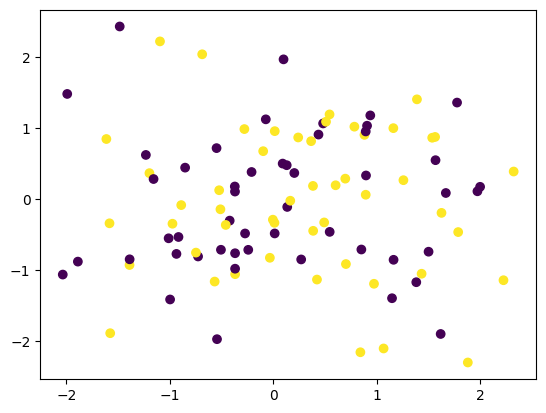

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(data[0][:, 0], data[0][:, 1], c=data[1])
plt.show()

In [ ]:
data[0][0], data[0][1]

(array([ 1.78847775, -0.46514613, -1.06268727,  1.97327425, -1.54353336,
         1.9265113 , -0.50242188, -0.98424897, -0.03917646,  0.93771707,
        -0.23953896, -0.19292872,  1.64807427, -0.93366166,  0.12457834,
         1.23280703, -0.58695565,  1.04443835,  0.69487869, -0.25357732]),
 array([ 0.69671534,  0.28868942, -0.91440592,  1.30408379, -1.72986614,
        -0.73505954, -1.54702689,  0.69899785, -0.047778  ,  1.59689165,
         0.45280431, -0.00259954, -0.40099091, -0.43765935, -0.3534956 ,
         1.37195652, -0.13261199, -0.9811299 ,  0.32557447,  0.37548547]))

In [ ]:
import pandas as pd
a = pd.DataFrame(data[0])
a

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1.788478,-0.465146,-1.062687,1.973274,-1.543533,1.926511,-0.502422,-0.984249,-0.039176,0.937717,-0.239539,-0.192929,1.648074,-0.933662,0.124578,1.232807,-0.586956,1.044438,0.694879,-0.253577
1,0.696715,0.288689,-0.914406,1.304084,-1.729866,-0.735060,-1.547027,0.698998,-0.047778,1.596892,0.452804,-0.002600,-0.400991,-0.437659,-0.353496,1.371957,-0.132612,-0.981130,0.325574,0.375485
2,-2.035313,-1.064774,1.874667,-1.775013,0.888104,-2.312022,-0.238322,0.145511,-0.208211,2.003544,3.129354,1.252390,0.522542,0.602019,0.143414,0.514558,0.859508,-1.571410,-1.014462,0.230427
3,-0.726919,-0.809508,-0.239780,-1.537045,-0.533427,1.031940,0.239267,0.125577,0.341207,-0.045672,0.923722,-0.244425,-0.549701,0.270932,1.170733,-0.569802,-0.788207,-1.407175,-0.634917,2.393444
4,-0.522868,0.125368,-0.437449,0.994247,0.493077,-1.081012,-0.584572,1.065253,-1.864636,0.915755,-1.914578,0.727287,-0.487695,-0.818454,-0.143382,0.873934,-0.917253,-1.405952,0.289490,-1.182850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-1.583306,-0.341477,-0.166391,1.011725,1.334021,-0.300025,1.215610,-1.887683,0.946866,0.031040,2.100962,0.421307,-0.832343,-0.327164,-1.015763,0.375617,-1.250075,0.246782,0.417786,2.045501
96,-0.916278,-0.534582,0.974538,-0.860215,-1.796060,0.275328,0.015662,-0.138050,0.613981,-1.488558,1.103090,0.790972,-0.875214,1.274392,-0.146086,-1.153153,-0.580741,0.265663,-0.155236,-0.179354
97,1.565245,0.877219,0.546380,2.195941,0.160870,0.069775,-1.598025,0.875558,-0.882499,0.571842,-1.867688,-0.611318,0.970033,-1.330396,-0.877592,1.102943,0.143511,0.921749,0.837804,-2.155801
98,1.974579,0.110486,0.346305,-2.476551,0.610166,0.850815,-0.637764,0.910734,0.524173,0.302113,1.609740,0.019339,1.839695,-1.465575,0.620721,-0.703849,-0.315428,0.238669,-1.074392,-0.417743


In [ ]:
b = pd.DataFrame(data[1])
b

,0
0,1
1,1
2,0
3,0
4,1
...,...
95,1
96,0
97,1
98,0


In [ ]:
!gzip /content/drive/MyDrive/data/cifar-10-python.tar.gz -d

gzip: /content/drive/MyDrive/data/cifar-10-python.tar.gz: No such file or directory
gzip: . is a directory -- ignored


In [ ]:
!tar -xvf /content/drive/MyDrive/data/cifar-10-python.tar

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


In [ ]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

unpickle('/content/cifar-10-batches-py/data_batch_1')

{b'batch_label': b'training batch 1 of 5',
 b'labels': [6,
  9,
  9,
  4,
  1,
  1,
  2,
  7,
  8,
  3,
  4,
  7,
  7,
  2,
  9,
  9,
  9,
  3,
  2,
  6,
  4,
  3,
  6,
  6,
  2,
  6,
  3,
  5,
  4,
  0,
  0,
  9,
  1,
  3,
  4,
  0,
  3,
  7,
  3,
  3,
  5,
  2,
  2,
  7,
  1,
  1,
  1,
  2,
  2,
  0,
  9,
  5,
  7,
  9,
  2,
  2,
  5,
  2,
  4,
  3,
  1,
  1,
  8,
  2,
  1,
  1,
  4,
  9,
  7,
  8,
  5,
  9,
  6,
  7,
  3,
  1,
  9,
  0,
  3,
  1,
  3,
  5,
  4,
  5,
  7,
  7,
  4,
  7,
  9,
  4,
  2,
  3,
  8,
  0,
  1,
  6,
  1,
  1,
  4,
  1,
  8,
  3,
  9,
  6,
  6,
  1,
  8,
  5,
  2,
  9,
  9,
  8,
  1,
  7,
  7,
  0,
  0,
  6,
  9,
  1,
  2,
  2,
  9,
  2,
  6,
  6,
  1,
  9,
  5,
  0,
  4,
  7,
  6,
  7,
  1,
  8,
  1,
  1,
  2,
  8,
  1,
  3,
  3,
  6,
  2,
  4,
  9,
  9,
  5,
  4,
  3,
  6,
  7,
  4,
  6,
  8,
  5,
  5,
  4,
  3,
  1,
  8,
  4,
  7,
  6,
  0,
  9,
  5,
  1,
  3,
  8,
  2,
  7,
  5,
  3,
  4,
  1,
  5,
  7,
  0,
  4,
  7,
  5,
  5,
  1,
  0,
  9,
  6,
  9,
 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import seaborn as sns
print(sns.get_dataset_names())